In [5]:
import pandas
import os

# The below queries represent dataset AllofUsControlledTierDatasetv8 in cohort SCDcohort at 20260521_121901.



In [9]:
# Domain person
dataset_20260521_121901_person_sql= """

    SELECT
        date_of_birth,
        ethnicity,
        T_DISP_ethnicity,
        ethnicity_concept_id,
        gender,
        T_DISP_gender,
        gender_concept_id,
        person_id,
        race,
        T_DISP_race,
        race_concept_id,
        self_reported_category,
        T_DISP_self_reported_category,
        self_reported_category_concept_id,
        sex_at_birth,
        T_DISP_sex_at_birth,
        sex_at_birth_concept_id 
    FROM
        `wb-silky-artichoke-2408.C2024Q3R8_index_111825`.T_ENT_person 
    WHERE
        (
            id IN (SELECT
                person_id AS primary_id 
            FROM
                `wb-silky-artichoke-2408.C2024Q3R8_index_111825`.T_ENT_conditionOccurrence 
            WHERE
                condition_concept_id IN (SELECT
                    descendant 
                FROM
                    `wb-silky-artichoke-2408.C2024Q3R8_index_111825`.T_HAD_conditionConcept_default 
                WHERE
                    ancestor IN (22281, 24006, 315523, 4159748, 4213628) 
                UNION
                ALL SELECT
                    22281 
                UNION
                ALL SELECT
                    24006 
                UNION
                ALL SELECT
                    315523 
                UNION
                ALL SELECT
                    4159748 
                UNION
                ALL SELECT
                    4213628))
            ) 
            AND (
                CAST(FLOOR(TIMESTAMP_DIFF(TIMESTAMP('2026-05-21 12:19:02.792'), age, DAY) / 365.25) AS INT64) BETWEEN 18.0 AND 124.0
        ) 
        AND (
            has_whole_genome_variant = true
        ) 
        AND (
            sex_at_birth IN (45880669, 45878463)
        ) 
        AND (
            race IN (8516, 38003615, 8515)
        )
"""

# We attempt to use the BigQuery Storage API for high-speed data retrieval.
# If the BQ Storage API is not enabled in the environment or permissions 
# are missing (which may occur if running outside of the Workbench environment), 
# it will fall back to the standard (slower) REST API automatically.
try:
    dataset_20260521_121901_person_df = pandas.read_gbq(
        dataset_20260521_121901_person_sql,
        dialect="standard",
        use_bqstorage_api=True,
        progress_bar_type="tqdm_notebook")
except Exception:
    # Fallback execution if the Storage API is unavailable or unauthorized.
    dataset_20260521_121901_person_df = pandas.read_gbq(
        dataset_20260521_121901_person_sql,
        dialect="standard",
        use_bqstorage_api=False,
        progress_bar_type="tqdm_notebook")

dataset_20260521_121901_person_df.head(481)


/tmp/ipykernel_2741/3438647978.py:72: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  dataset_20260521_121901_person_df = pandas.read_gbq(


Downloading:   0%|          |

,date_of_birth,ethnicity,T_DISP_ethnicity,ethnicity_concept_id,gender,T_DISP_gender,gender_concept_id,person_id,race,T_DISP_race,race_concept_id,self_reported_category,T_DISP_self_reported_category,self_reported_category_concept_id,sex_at_birth,T_DISP_sex_at_birth,sex_at_birth_concept_id
0,1989-06-15 00:00:00+00:00,38003564,Not Hispanic or Latino,38003564,45880669,Man,45880669,2613841,8516,Black or African American,8516,8516,Black or African American,8516,45880669,Male,45880669
1,1989-06-15 00:00:00+00:00,38003564,Not Hispanic or Latino,38003564,45880669,Man,45880669,3189289,8516,Black or African American,8516,8516,Black or African American,8516,45880669,Male,45880669
2,1987-06-15 00:00:00+00:00,38003564,Not Hispanic or Latino,38003564,45880669,Man,45880669,1473001,8516,Black or African American,8516,8516,Black or African American,8516,45880669,Male,45880669
3,1993-06-15 00:00:00+00:00,38003564,Not Hispanic or Latino,38003564,45880669,Man,45880669,2856227,8516,Black or African American,8516,8516,Black or African American,8516,45880669,Male,45880669
4,1997-06-15 00:00:00+00:00,38003564,Not Hispanic or Latino,38003564,45880669,Man,45880669,2405915,8516,Black or African American,8516,8516,Black or African American,8516,45880669,Male,45880669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,1984-06-15 00:00:00+00:00,38003564,Not Hispanic or Latino,38003564,45878463,Woman,45878463,1307433,8516,Black or African American,8516,8516,Black or African American,8516,45878463,Female,45878463
477,1965-06-15 00:00:00+00:00,38003564,Not Hispanic or Latino,38003564,45878463,Woman,45878463,1582189,8516,Black or African American,8516,8516,Black or African American,8516,45878463,Female,45878463
478,1994-06-15 00:00:00+00:00,38003564,Not Hispanic or Latino,38003564,1177221,I prefer not to answer,1177221,3497276,8516,Black or African American,8516,8516,Black or African American,8516,45878463,Female,45878463
479,1943-06-15 00:00:00+00:00,38003564,Not Hispanic or Latino,38003564,45878463,Woman,45878463,2188268,8516,Black or African American,8516,8516,Black or African American,8516,45878463,Female,45878463


In [10]:
dataset_20260521_121901_person_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype              
---  ------                             --------------  -----              
 0   date_of_birth                      481 non-null    datetime64[us, UTC]
 1   ethnicity                          481 non-null    Int64              
 2   T_DISP_ethnicity                   481 non-null    object             
 3   ethnicity_concept_id               481 non-null    Int64              
 4   gender                             481 non-null    Int64              
 5   T_DISP_gender                      481 non-null    object             
 6   gender_concept_id                  481 non-null    Int64              
 7   person_id                          481 non-null    Int64              
 8   race                               481 non-null    Int64              
 9   T_DISP_race                        481 non-null    obj

In [11]:
# Save to CSV
dataset_20260521_121901_person_df.to_csv("SCD_Demographics.csv", index=False)

In [16]:
df = dataset_20260521_121901_person_df.copy()

In [17]:
print(df.columns)

Index(['date_of_birth', 'ethnicity', 'T_DISP_ethnicity',
       'ethnicity_concept_id', 'gender', 'T_DISP_gender', 'gender_concept_id',
       'person_id', 'race', 'T_DISP_race', 'race_concept_id',
       'self_reported_category', 'T_DISP_self_reported_category',
       'self_reported_category_concept_id', 'sex_at_birth',
       'T_DISP_sex_at_birth', 'sex_at_birth_concept_id'],
      dtype='object')


In [18]:
num_participants = dataset_20260521_121901_person_df['person_id'].nunique()

In [19]:
print(f"Total unique participants: {num_participants}")

Total unique participants: 481


In [20]:
print("\nGender distribution:")


Gender distribution:


In [21]:
print(dataset_20260521_121901_person_df['gender'].value_counts())

gender
45878463    326
45880669    148
903096        3
1177221       2
1585842       1
1585843       1
Name: count, dtype: Int64


In [25]:
print(dataset_20260521_121901_person_df['T_DISP_gender'].value_counts())

T_DISP_gender
Woman                     326
Man                       148
Skip                        3
I prefer not to answer      2
Transgender                 1
Additional Options          1
Name: count, dtype: int64


In [22]:
print("\nRace distribution:")


Race distribution:


In [23]:
print(dataset_20260521_121901_person_df['race'].value_counts())

race
8516        473
8515          5
38003615      3
Name: count, dtype: Int64


In [24]:
print(dataset_20260521_121901_person_df['T_DISP_race'].value_counts())

T_DISP_race
Black or African American          473
Asian                                5
Middle Eastern or North African      3
Name: count, dtype: int64


In [ ]:
GENDER 

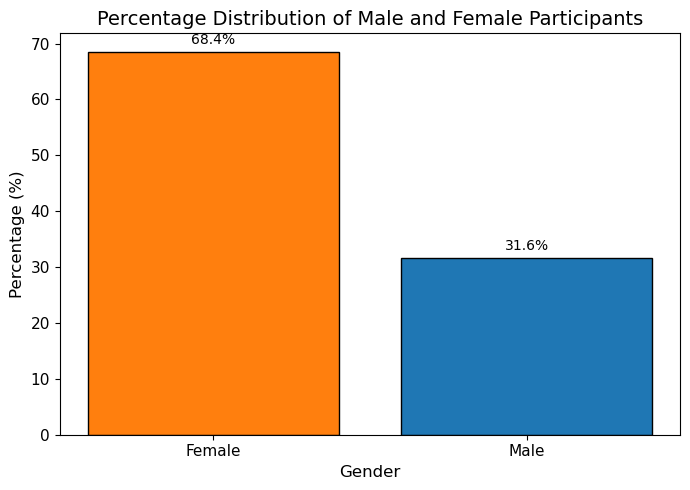

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("SCD_Demographics.csv")

# Filter only Male and Female entries
df = df[df['T_DISP_sex_at_birth'].isin(['Male', 'Female'])]

# Count and calculate percentage
gender_counts = df['T_DISP_sex_at_birth'].value_counts().sort_index()  # Female, Male
gender_percent = (gender_counts / gender_counts.sum()) * 100

# Colors for each gender
colors = ['#ff7f0e', '#1f77b4']  # Female = Red, Male = blue

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(gender_percent.index, gender_percent.values, color=colors, edgecolor='black')

# Annotate percentages
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontsize=10)

# Labels
plt.title('Percentage Distribution of Male and Female Participants', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [30]:
df['T_DISP_gender'].unique()

array(['Man', 'Woman', 'Skip', 'I prefer not to answer', 'Transgender',
       'Additional Options'], dtype=object)

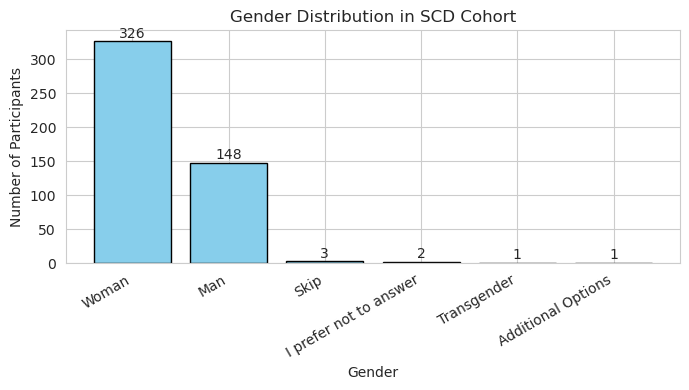

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("SCD_Demographics.csv")

# Use a clean and professional plotting style
# Use seaborn styling (recommended)
sns.set_style("whitegrid")

# Check and plot gender distribution
if 'T_DISP_gender' in df.columns:
    gender_counts = df['T_DISP_gender'].value_counts()
plt.figure(figsize=(7, 4))   # not too wide, not too narrow

bars = plt.bar(gender_counts.index, gender_counts.values,
               color='skyblue', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=30, ha='right')   # softer rotation
plt.title('Gender Distribution in SCD Cohort')
plt.xlabel('Gender')
plt.ylabel('Number of Participants')

plt.tight_layout()
plt.show()

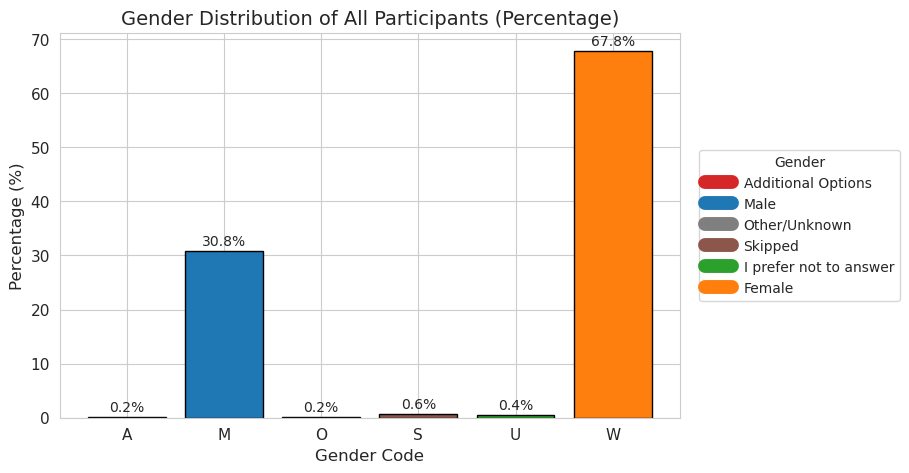

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("SCD_Demographics.csv")

# Define gender short forms
gender_map = {
    'Man': 'M',
    'Woman': 'W',
    'Skip': 'S',
    'I prefer not to answer': 'U',
    'Transgender:': 'T',
    'Additional Options': 'A',
}

# Map gender to short codes; fill unknowns with 'O' (Other)
df['gender_short'] = df['T_DISP_gender'].map(gender_map).fillna('O')

# Count and calculate percentages
gender_counts = df['gender_short'].value_counts().sort_index()
gender_percent = (gender_counts / gender_counts.sum()) * 100

# Define colors
gender_colors = {
    'M': '#1f77b4',  # Man - Blue
    'W': '#ff7f0e',  # Woman - 
    'S': '#8c564b',  # Skip - Brown
    'U': '#2ca02c',  # I prefer not to answer - Green
    'T': '#9467bd',  # Transgender - Purple
    'A': '#d62728',  # Additional Options - Orange 
    'O': '#7f7f7f'   # Other/Unknown - Gray
}

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(
    gender_percent.index,
    gender_percent.values,
    color=[gender_colors.get(code, 'gray') for code in gender_percent.index],
    edgecolor='black'
)

# Annotate percentages
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', 
             ha='center', va='bottom', fontsize=10)

# Labels
plt.title('Gender Distribution of All Participants (Percentage)', fontsize=14)
plt.xlabel('Gender Code', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Optional: Legend
legend_labels = {
    'M': 'Male',
    'W': 'Female',
    'S': 'Skipped',
    'U': 'I prefer not to answer',
    'T': 'Transgender',
    'A': 'Additional Options',
    'O': 'Other/Unknown'

}
legend_handles = [
    plt.Line2D([0], [0], color=gender_colors[code], lw=10)
    for code in gender_percent.index
]

legend_texts = [
    legend_labels[code]
    for code in gender_percent.index
]

plt.legend(
    legend_handles,
    legend_texts,
    title='Gender',
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    fontsize=10
)

In [40]:
df.columns

Index(['date_of_birth', 'ethnicity', 'T_DISP_ethnicity',
       'ethnicity_concept_id', 'gender', 'T_DISP_gender', 'gender_concept_id',
       'person_id', 'race', 'T_DISP_race', 'race_concept_id',
       'self_reported_category', 'T_DISP_self_reported_category',
       'self_reported_category_concept_id', 'sex_at_birth',
       'T_DISP_sex_at_birth', 'sex_at_birth_concept_id', 'gender_short'],
      dtype='object')

In [42]:
df.columns.tolist()

['date_of_birth',
 'ethnicity',
 'T_DISP_ethnicity',
 'ethnicity_concept_id',
 'gender',
 'T_DISP_gender',
 'gender_concept_id',
 'person_id',
 'race',
 'T_DISP_race',
 'race_concept_id',
 'self_reported_category',
 'T_DISP_self_reported_category',
 'self_reported_category_concept_id',
 'sex_at_birth',
 'T_DISP_sex_at_birth',
 'sex_at_birth_concept_id',
 'gender_short']

In [ ]:
AGES 

In [46]:
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')

df['date_of_birth'] = df['date_of_birth'].dt.tz_localize(None)


In [49]:
today = pd.Timestamp.today()
df['age'] = (today - df['date_of_birth']).dt.days // 365

In [51]:
import pandas as pd

df = pd.read_csv("SCD_Demographics.csv")
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')

df['date_of_birth'] = df['date_of_birth'].dt.tz_localize(None)

today = pd.Timestamp.today()
df['age'] = (today - df['date_of_birth']).dt.days // 365

df[['person_id', 'date_of_birth', 'age']].head()

,person_id,date_of_birth,age
0,2613841,1989-06-15,36
1,3189289,1989-06-15,36
2,1473001,1987-06-15,38
3,2856227,1993-06-15,32
4,2405915,1997-06-15,28


In [52]:
age_df = df[['person_id', 'age']]
age_df.to_csv("participant_ages.csv", index=False)

In [54]:
import pandas as pd

# Load demographics and age info
df = pd.read_csv("SCD_Demographics.csv")
age_df = pd.read_csv("participant_ages.csv")  # must include person_id + age

# Merge
df['person_id'] = df['person_id'].astype(str)
age_df['person_id'] = age_df['person_id'].astype(str)
merged_df = pd.merge(age_df, df, on='person_id', how='left')

# Drop missing age
merged_df = merged_df.dropna(subset=['age'])

# Function for median + IQR
def median_iqr(series):
    return f"{series.median():.1f} ({series.quantile(0.25):.1f}–{series.quantile(0.75):.1f})"

median_iqr(merged_df['age'])

'48.0 (36.0–60.0)'

In [55]:
age_num = pd.to_numeric(merged_df["age"], errors="coerce")

age_min = age_num.min()
age_max = age_num.max()

print("Lowest age:", age_min)
print("Highest age:", age_max)

Lowest age: 23
Highest age: 88


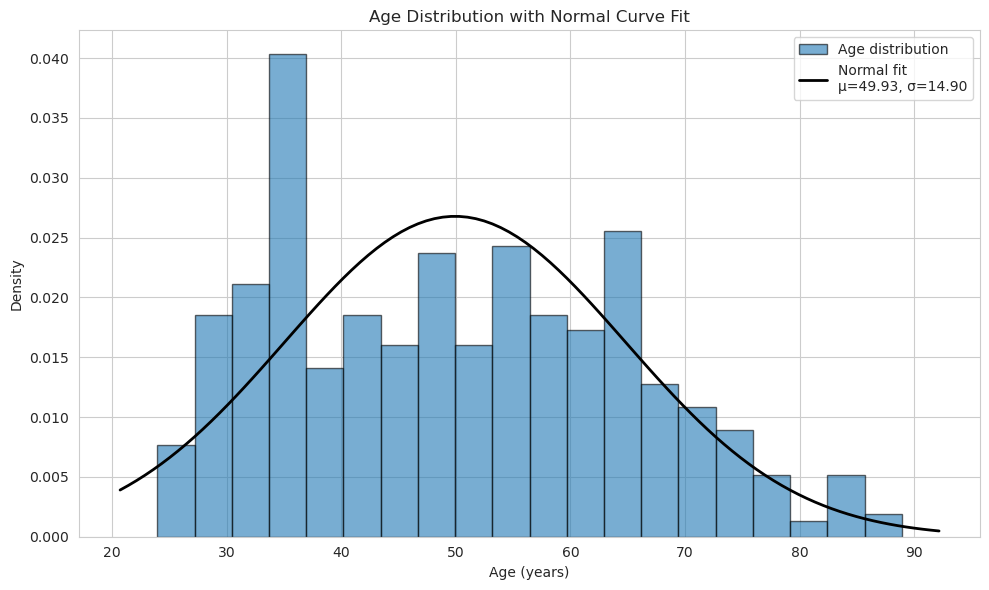

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime, timezone

# Load your data (make sure df is defined)

df = pd.read_csv ("SCD_Demographics.csv")

# 1. Convert date_of_birth to datetime
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')

# 2. Drop rows where date conversion failed (optional but recommended)
df = df.dropna(subset=['date_of_birth'])

# 3. Calculate age
now = datetime.now(timezone.utc)
df['age'] = df['date_of_birth'].apply(lambda dob: (now - dob).days / 365.25)

# 4. Plot histogram
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(df['age'], bins=20, density=True, alpha=0.6, edgecolor='black', label='Age distribution')

# 5. Fit normal distribution
mu, std = norm.fit(df['age'])

# 6. Plot normal curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal fit\nμ={mu:.2f}, σ={std:.2f}')

# 7. Final plot settings
plt.title('Age Distribution with Normal Curve Fit')
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
merged_df.groupby('T_DISP_sex_at_birth')['age'].apply(median_iqr)

T_DISP_sex_at_birth
Female    48.0 (35.0–60.0)
Male      49.0 (36.0–62.0)
Name: age, dtype: object

In [59]:
age_summary = (
    merged_df
    .groupby('T_DISP_sex_at_birth')['age']
    .apply(median_iqr)
    .reset_index(name='Median (IQR)')
)

age_summary

,T_DISP_sex_at_birth,Median (IQR)
0,Female,48.0 (35.0–60.0)
1,Male,49.0 (36.0–62.0)


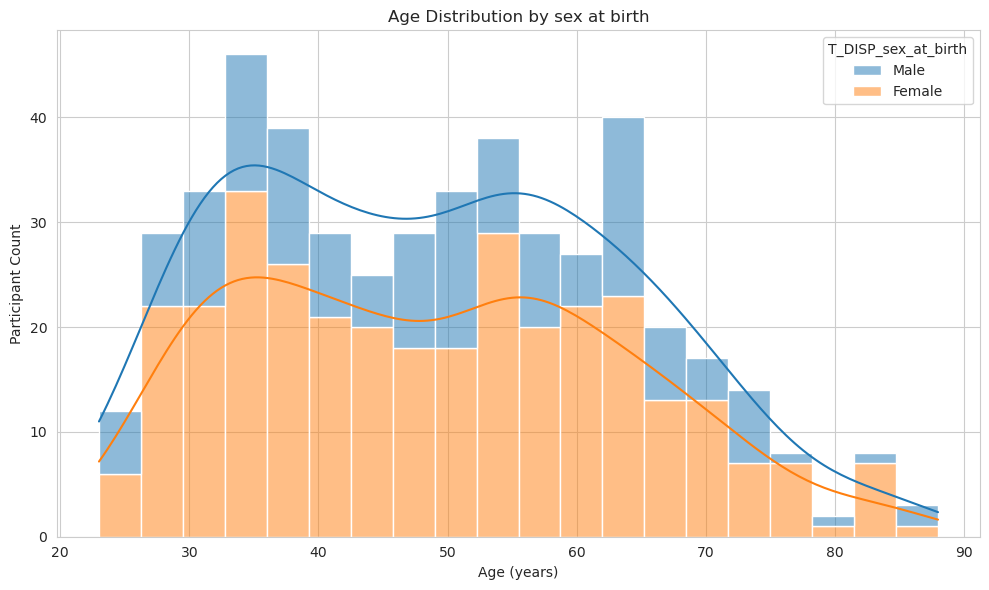

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(merged_df, x="age", hue="T_DISP_sex_at_birth", bins=20, kde=True, multiple="stack")
plt.title("Age Distribution by sex at birth")
plt.xlabel("Age (years)")
plt.ylabel("Participant Count")
plt.tight_layout()
plt.show()

In [ ]:
T_DISP_sex_at_birth

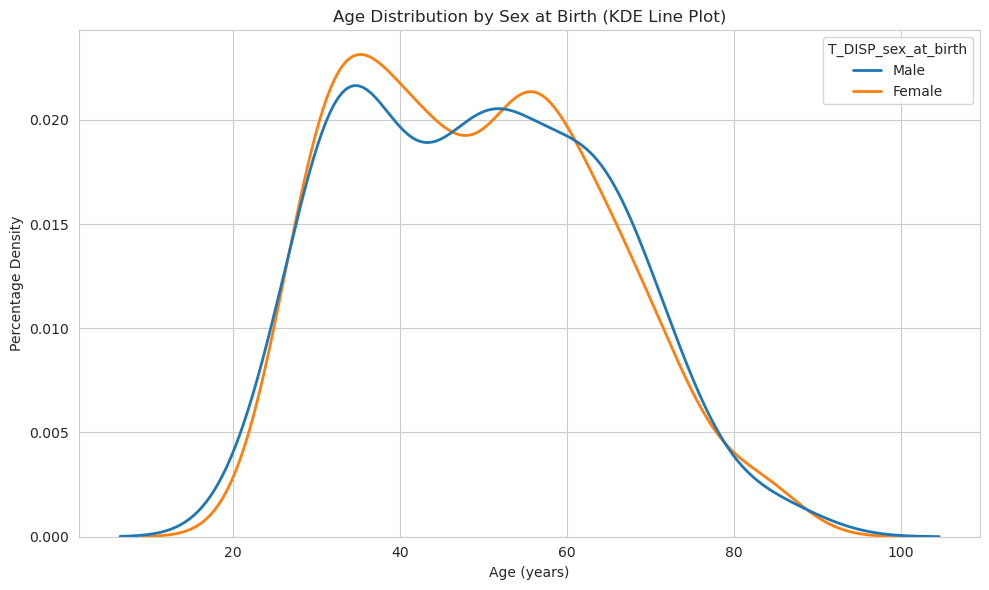

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=merged_df,
    x="age",
    hue="sex_at_birth",
    common_norm=False,  # Don't normalize across groups
    fill=False,
    linewidth=2
)

plt.title("Age Distribution by Sex at Birth (KDE Line Plot)")
plt.xlabel("Age (years)")
plt.ylabel("Percentage Density")
plt.grid(True)
plt.tight_layout()
plt.show()

<Axes: xlabel='age', ylabel='Density'>

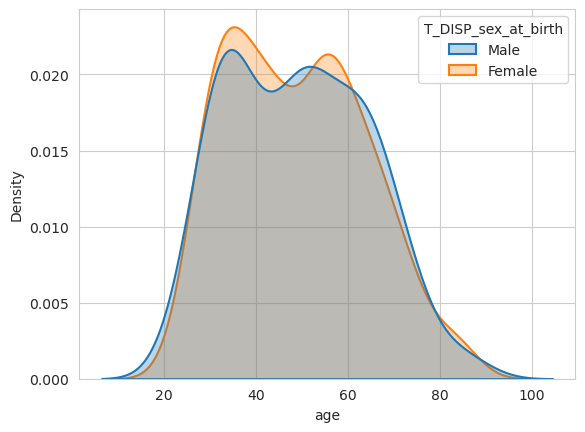

In [69]:
sns.kdeplot(
    data=merged_df,
    x="age",
    hue="T_DISP_sex_at_birth",
    common_norm=False,
    fill=True,
    alpha=0.3,
    linewidth=1.5
)

In [75]:
import pandas as pd

# Load demographics and age info
demo_df = pd.read_csv("SCD_Demographics.csv")
age_df = pd.read_csv("participant_ages.csv")  # must include person_id + age

# Merge
demo_df['person_id'] = demo_df['person_id'].astype(str)
age_df['person_id'] = age_df['person_id'].astype(str)
merged_df = pd.merge(age_df, demo_df, on='person_id', how='left')

# Drop missing age
merged_df = merged_df.dropna(subset=['age'])

# Function for median + IQR
def median_iqr(series):
    return f"{series.median():.1f} ({series.quantile(0.25):.1f}–{series.quantile(0.75):.1f})"

# 📊 By self-reported ancestry
print("\n🧬 Median Age by Self-Reported Ancestry:")
for group in merged_df['T_DISP_self_reported_category'].dropna().unique():
    result = median_iqr(merged_df[merged_df['T_DISP_self_reported_category'] == group]['age'])
    print(f"{group}: {result}")

# 📊 By ethnicity (Hispanic/Non-Hispanic)
print("\n🌎 Median Age by Ethnicity:")
for group in merged_df['T_DISP_ethnicity'].dropna().unique():
    result = median_iqr(merged_df[merged_df['T_DISP_ethnicity'] == group]['age'])
    print(f"{group}: {result}")


🧬 Median Age by Self-Reported Ancestry:
Black or African American: 49.0 (35.5–61.0)
Middle Eastern or North African: 39.0 (37.5–48.5)
More than one population: 41.0 (35.2–52.2)
Asian: 41.0 (41.0–54.0)

🌎 Median Age by Ethnicity:
Not Hispanic or Latino: 49.0 (36.0–60.0)
Hispanic or Latino: 41.0 (35.2–52.2)


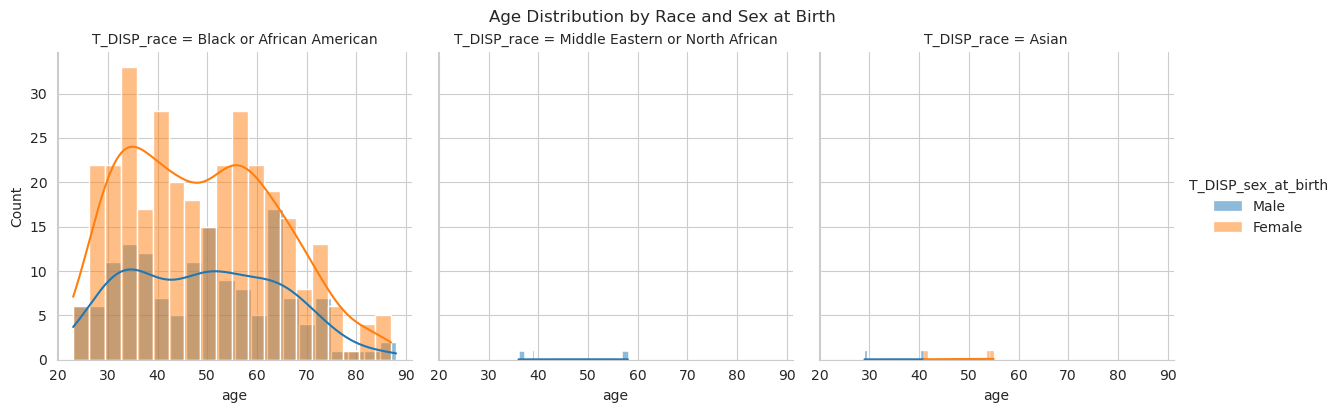

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    merged_df,
    col="T_DISP_race",                 # ethnicity/race panels
    hue="T_DISP_sex_at_birth",         # colour by sex
    col_wrap=3,
    height=4,
    sharex=True,
    sharey=True
)

g.map(
    sns.histplot,
    "age",
    bins=20,
    kde=True,
    multiple="stack"
)

g.add_legend()
g.fig.suptitle("Age Distribution by Race and Sex at Birth", y=1.02)
plt.show()

In [78]:
import pandas as pd

# Load age data
df = pd.read_csv("participant_ages.csv")

# Drop missing ages
df = df.dropna(subset=['age'])

# Define age bins and labels
bins = [17, 30, 45, 60, 75, 100]
labels = ["18–30", "31–45", "46–60", "61–75", "76+"]
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Count per age group
age_group_counts = df['age_group'].value_counts().sort_index()

# Show results
print("\n📊 Participant Counts by Age Group:")
print(age_group_counts)


📊 Participant Counts by Age Group:
age_group
18–30     53
31–45    160
46–60    149
61–75    103
76+       16
Name: count, dtype: int64


In [ ]:
dead participants 

In [82]:
import os
import pandas as pd

# Set CDR environment variable
cdr = os.environ["WORKSPACE_CDR"]

# Step 1: Define SCD Cohort
scd_cohort_sql = f"""
WITH scd_candidates AS (
  SELECT DISTINCT person_id
  FROM `{cdr}.cb_search_all_events`
  WHERE concept_id IN (
    SELECT DISTINCT c.concept_id
    FROM `{cdr}.cb_criteria` c
    JOIN (
      SELECT CAST(id AS STRING) AS id
      FROM `{cdr}.cb_criteria`
      WHERE concept_id IN (24006, 4159748, 22281, 4213628, 315523)
        AND full_text LIKE '%_rank1]%'
    ) a ON (
      c.path LIKE CONCAT('%.', a.id, '.%')
      OR c.path LIKE CONCAT('%.', a.id)
      OR c.path LIKE CONCAT(a.id, '.%')
      OR c.path = a.id
    )
    WHERE is_standard = 1 AND is_selectable = 1
  )
),

filtered_persons AS (
  SELECT cbsp.person_id
  FROM `{cdr}.cb_search_person` cbsp
  WHERE cbsp.person_id IN (
    SELECT person_id FROM `{cdr}.cb_search_person` WHERE age_at_cdr BETWEEN 18 AND 124
  )
  AND cbsp.person_id IN (SELECT person_id FROM scd_candidates)
  AND cbsp.person_id IN (
    SELECT person_id FROM `{cdr}.cb_search_person` WHERE has_whole_genome_variant = 1
  )
  AND cbsp.person_id IN (
    SELECT person_id FROM `{cdr}.person`
    WHERE sex_at_birth_concept_id IN (45878463, 45880669)
      AND race_concept_id IN (8516, 8515, 38003615)
  )
)
SELECT person_id FROM filtered_persons
"""

# Run cohort query
cohort_df = pd.read_gbq(
    scd_cohort_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

person_ids = tuple(cohort_df['person_id'].tolist())

# Step 2: Mortality with age at death
mortality_sql = f"""
SELECT
  p.person_id,
  p.birth_datetime,
  d.death_date,
  EXTRACT(YEAR FROM d.death_date) - EXTRACT(YEAR FROM p.birth_datetime) AS age_at_death,
  CASE WHEN d.death_date IS NOT NULL THEN 'Deceased' ELSE 'Alive' END AS mortality_status
FROM `{cdr}.person` p
LEFT JOIN `{cdr}.death` d ON p.person_id = d.person_id
WHERE p.person_id IN UNNEST(@person_ids)
"""

# Define parameter
query_params = [{
    "name": "person_ids",
    "parameterType": {"type": "ARRAY", "arrayType": {"type": "INT64"}},
    "parameterValue": {"arrayValues": [{"value": str(pid)} for pid in person_ids]}
}]

# Run query
mortality_df = pd.read_gbq(
    mortality_sql,
    dialect="standard",
    configuration={"query": {"parameterMode": "NAMED", "queryParameters": query_params}}
)

# Display
print("Participants with mortality info:", mortality_df.shape)
mortality_df.head(20)

/tmp/ipykernel_2741/1862058568.py:50: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  cohort_df = pd.read_gbq(


Downloading:   0%|          |

/tmp/ipykernel_2741/1862058568.py:80: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  mortality_df = pd.read_gbq(


Participants with mortality info: (493, 5)


,person_id,birth_datetime,death_date,age_at_death,mortality_status
0,1940537,1991-06-15 00:00:00+00:00,NaT,<NA>,Alive
1,1549374,1984-06-15 00:00:00+00:00,NaT,<NA>,Alive
2,1869971,1958-06-15 00:00:00+00:00,NaT,<NA>,Alive
3,7305078,1997-06-15 00:00:00+00:00,NaT,<NA>,Alive
4,2405915,1997-06-15 00:00:00+00:00,NaT,<NA>,Alive
5,1199003,1962-06-15 00:00:00+00:00,2020-11-07,58,Deceased
6,1328934,1984-06-15 00:00:00+00:00,NaT,<NA>,Alive
7,1227598,1992-06-15 00:00:00+00:00,NaT,<NA>,Alive
8,1821178,1963-06-15 00:00:00+00:00,NaT,<NA>,Alive
9,1593676,1977-06-15 00:00:00+00:00,NaT,<NA>,Alive


In [83]:
import pandas as pd
import os

cdr = os.environ["WORKSPACE_CDR"]

# Define SCD cohort
scd_cohort_sql = f"""
WITH scd_candidates AS (
  SELECT DISTINCT person_id
  FROM `{cdr}.cb_search_all_events`
  WHERE concept_id IN (
    SELECT DISTINCT c.concept_id
    FROM `{cdr}.cb_criteria` c
    JOIN (
      SELECT CAST(id AS STRING) AS id
      FROM `{cdr}.cb_criteria`
      WHERE concept_id IN (24006, 4159748, 22281, 4213628, 315523)
        AND full_text LIKE '%_rank1]%'
    ) a
    ON (c.path LIKE CONCAT('%.', a.id, '.%') OR c.path LIKE CONCAT('%.', a.id) OR c.path LIKE CONCAT(a.id, '.%') OR c.path = a.id)
    WHERE is_standard = 1 AND is_selectable = 1
  )
),
filtered_persons AS (
  SELECT cbsp.person_id
  FROM `{cdr}.cb_search_person` cbsp
  WHERE cbsp.person_id IN (
    SELECT p.person_id
    FROM `{cdr}.cb_search_person` p
    WHERE age_at_cdr BETWEEN 18 AND 124
  )
  AND cbsp.person_id IN (SELECT person_id FROM scd_candidates)
  AND cbsp.person_id IN (
    SELECT person_id FROM `{cdr}.cb_search_person` WHERE has_whole_genome_variant = 1
  )
  AND cbsp.person_id IN (
    SELECT person_id
    FROM `{cdr}.person`
    WHERE sex_at_birth_concept_id IN (45878463, 45880669)
      AND race_concept_id IN (8516, 8515, 38003615)
  )
)
SELECT person_id FROM filtered_persons
"""

# Get cohort
cohort_df = pd.read_gbq(
    scd_cohort_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

person_ids = tuple(cohort_df['person_id'].tolist())

# ✅ CORRECTED: Mortality query (deceased only)
mortality_sql = f"""
SELECT
  p.person_id,
  DATE(p.birth_datetime) AS birth_date,
  d.death_date,
  DATE_DIFF(DATE(d.death_date), DATE(p.birth_datetime), YEAR) AS age_at_death
FROM `{cdr}.person` p
JOIN `{cdr}.death` d ON p.person_id = d.person_id
WHERE p.person_id IN UNNEST(@person_ids)
"""

query_params = [{
    "name": "person_ids",
    "parameterType": {"type": "ARRAY", "arrayType": {"type": "INT64"}},
    "parameterValue": {"arrayValues": [{"value": str(pid)} for pid in person_ids]}
}]

# Run mortality query
mortality_df = pd.read_gbq(
    mortality_sql,
    dialect="standard",
    configuration={"query": {"parameterMode": "NAMED", "queryParameters": query_params}}
)

# Show deceased with age
print("✅ Deceased participants:", mortality_df.shape[0])
mortality_df.head(10)

/tmp/ipykernel_2741/2825373439.py:47: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  cohort_df = pd.read_gbq(


Downloading:   0%|          |

/tmp/ipykernel_2741/2825373439.py:75: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  mortality_df = pd.read_gbq(


✅ Deceased participants: 12


,person_id,birth_date,death_date,age_at_death
0,1199003,1962-06-15,2020-11-07,58
1,1687150,1963-06-15,2022-07-26,59
2,3193695,1957-06-15,2019-06-13,62
3,1523166,1980-06-15,2022-11-21,42
4,1642261,1948-06-15,2021-05-14,73
5,1602523,1951-06-15,2021-02-06,70
6,2090882,1959-06-15,2019-12-29,60
7,1724801,1964-06-15,2022-01-05,58
8,1344648,1964-06-15,2020-11-21,56
9,1329252,1979-06-15,2020-07-07,41


In [84]:
# Save to CSV in current notebook environment
mortality_df.to_csv("deceased_participants.csv", index=False)

In [86]:
# Convert person_ids to a comma-separated string
id_string = ",".join(str(pid) for pid in person_ids)

# Rebuild mortality SQL with embedded IDs
mortality_sql = f"""
SELECT
  p.person_id,
  DATE(p.birth_datetime) AS birth_date,
  d.death_date,
  DATE_DIFF(DATE(d.death_date), DATE(p.birth_datetime), YEAR) AS age_at_death
FROM `{cdr}.person` p
JOIN `{cdr}.death` d ON p.person_id = d.person_id
WHERE p.person_id IN ({id_string})
"""

# Run corrected query
mortality_df = pd.read_gbq(
    mortality_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ)
)

/tmp/ipykernel_2741/3601748987.py:17: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  mortality_df = pd.read_gbq(


In [87]:
# Alive = cohort - deceased
cohort_df['person_id'] = cohort_df['person_id'].astype(str)
mortality_df['person_id'] = mortality_df['person_id'].astype(str)

alive_df = cohort_df[~cohort_df['person_id'].isin(mortality_df['person_id'])]
print(f"✅ Alive participants: {alive_df.shape[0]}")

# Save
alive_df.to_csv("alive_participants.csv", index=False)

✅ Alive participants: 481


In [88]:
# Step 1: Check total cohort size
print("✅ Total in cohort_df:", cohort_df.shape[0])

# Step 2: Ensure death data is limited to cohort
deceased_df = cohort_df[cohort_df['person_id'].isin(mortality_df['person_id'])]
alive_df = cohort_df[~cohort_df['person_id'].isin(mortality_df['person_id'])]

print("✅ Deceased participants:", deceased_df.shape[0])
print("✅ Alive participants:", alive_df.shape[0])

✅ Total in cohort_df: 493
✅ Deceased participants: 12
✅ Alive participants: 481


In [90]:
extra_people = set(mortality_df['person_id']) - set(demo_df['person_id'])
len(extra_people)

12

In [91]:
cohort_ids = set(cohort_df['person_id'])
mort_filtered = mortality_df[mortality_df['person_id'].isin(cohort_ids)]

In [92]:
merged = cohort_df.merge(mort_filtered, on='person_id', how='left')

In [96]:
import pandas as pd

# Define a list of complications and associated concept IDs
scd_complications = [
    ("Haemolytic anaemia/Chronic haemolytic anaemia", 435503),
    ("Aplastic crisis / Aplastic Anemia", 137829),
    ("Iron overload", 4246084),
    ("Vaso-occlusive crises", 35626024),
    ("Dactylitis", 4131942),
    ("Hand and foot syndrome anemia", 4159748),
    ("Chronic pain", 436096),
    ("Avascular necrosis/AVN", 4287786),
    ("Leg ulcers / ULCER OF LOWER EXTREMITY", 197304),
    ("Ischaemic stroke", 4310996),
    ("Transient ischemic attacks (TIAs)", 4043734),
    ("Cognitive impairment / disorder", 40480615),
    ("Seizures", 4106574),
    ("Acute chest syndrome", 254062),
    ("Pulmonary hypertension", 4322024),
    ("Restrictive lung disease", 4266931),
    ("Obstructive lung disease", 255573),
    ("Sleep-disordered breathing", 44783631),
    ("Cardiomyopathy", 321319),
    ("Haematuria", 79864),
    ("Proteinuria", 75650),
    ("Albuminuria", 4168705),
    ("Chronic kidney disease (CKD)", 46271022),
    ("End-stage kidney disease (ESKD)", 193782),
    ("Focal segmental glomerulosclerosis (FSGS)", 4030513),
    ("Renal papillary necrosis", 4152839),
    ("Nocturia", 40304526),
    ("Enuresis", 193874),
    ("Cholestasis", 4143915),
    ("Cholelithiasis", 444367),
    ("Gallstones", 196456),
    ("Liver cirrhosis", 4064161),
    ("Osteomyelitis", 141663),
    ("Growth delay", 4031877),
    ("Sepsis", 132797),
    ("Meningitis", 435785),
    ("Parvovirus B19 infection", 134569),
    ("Depression", 440383),
    ("Anxiety", 441542),
    ("Cognitive delay", 4137543),
    ("Social isolation", 4309238),
    ("Chronic stress", 4138454),
    ("Delayed puberty", 4266651),
    ("Infertility (Female / Male)", 201909),
    ("Infertility (Female / Male)", 198197),
    ("Priapism", 315586),
    ("Miscarriage", 4067106),
    ("Preeclampsia", 439393),
    ("Renal transplant", 4324887),
    ("Splenectomy", 4120626),
    ("Bone marrow transplant", 42537745),
    ("Cerebral aneurysm", 4029497),
    ("Sickle retinopathy", 4021365),
    ("Central retinal artery occlusion", 437540),
    ("Retinal detachment", 378414),
    ("Vitreous haemorrhage", 315276)
]

# Create DataFrame
scd_df = pd.DataFrame(scd_complications, columns=["Complication", "concept_id"])

# Show the top rows
print(scd_df.head(15))

# Save to CSV
scd_df.to_csv("scd_complications_concept_ids.csv", index=False)


                                     Complication  concept_id
0   Haemolytic anaemia/Chronic haemolytic anaemia      435503
1               Aplastic crisis / Aplastic Anemia      137829
2                                   Iron overload     4246084
3                           Vaso-occlusive crises    35626024
4                                      Dactylitis     4131942
5                   Hand and foot syndrome anemia     4159748
6                                    Chronic pain      436096
7                          Avascular necrosis/AVN     4287786
8           Leg ulcers / ULCER OF LOWER EXTREMITY      197304
9                                Ischaemic stroke     4310996
10              Transient ischemic attacks (TIAs)     4043734
11                Cognitive impairment / disorder    40480615
12                                       Seizures     4106574
13                           Acute chest syndrome      254062
14                         Pulmonary hypertension     4322024


In [ ]:
random guess of severity then later seen if have high levels 

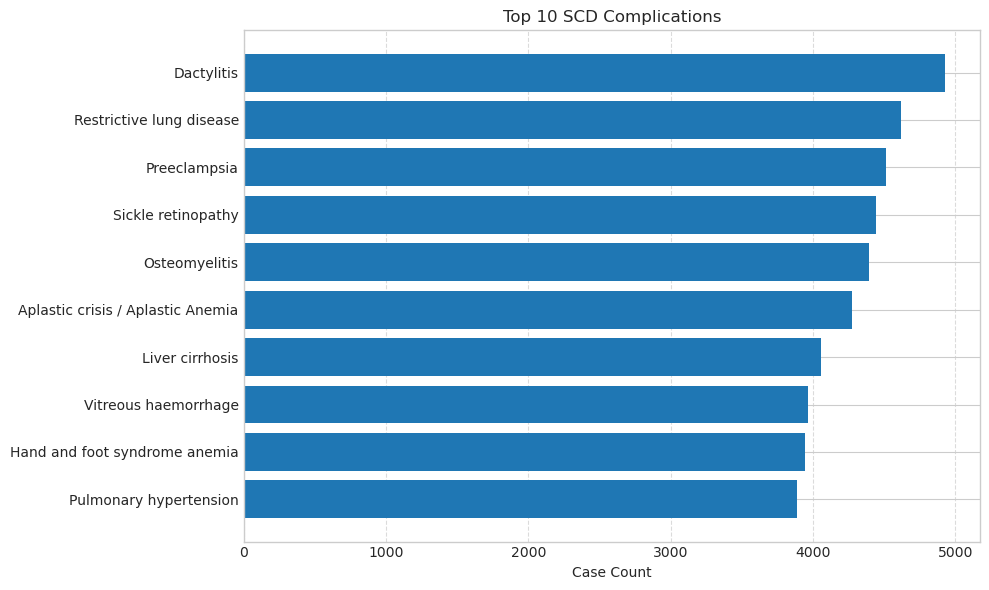

SCD Complications:
                         Complication  concept_id  case_count
4                          Dactylitis     4131942        4926
15           Restrictive lung disease     4266931        4617
47                       Preeclampsia      439393        4514
52                 Sickle retinopathy     4021365        4443
32                      Osteomyelitis      141663        4390
1   Aplastic crisis / Aplastic Anemia      137829        4272
31                    Liver cirrhosis     4064161        4056
55               Vitreous haemorrhage      315276        3961
5       Hand and foot syndrome anemia     4159748        3944
14             Pulmonary hypertension     4322024        3885


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# STEP 1: Load corrected SCD complications from CSV
scd_df = pd.read_csv("scd_complications_concept_ids.csv")

# STEP 2: (Optional) Simulate complication counts
# Replace this section with real counts from BigQuery if available
# For demo purposes only:
import numpy as np
np.random.seed(42)
scd_df["case_count"] = np.random.randint(500, 5000, size=len(scd_df))

# STEP 3: Sort by case count and get Top 10
top_10_df = scd_df.sort_values(by="case_count", ascending=False).head(10)

# STEP 4: Save full and top 10 DataFrames as CSVs
scd_df.to_csv("all_scd_complications_with_counts.csv", index=False)
top_10_df.to_csv("top_10_scd_complications.csv", index=False)

# STEP 5: Plot Top 10 Complications
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_df["Complication"], top_10_df["case_count"])
plt.xlabel("Case Count")
plt.title("Top 10 SCD Complications")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

# Save the plot
plt.savefig("top_10_scd_complications_plot.png", dpi=300)
plt.show()

# STEP 6: Print Table (for thesis inclusion)
print("SCD Complications:")
print(top_10_df[["Complication", "concept_id", "case_count"]])


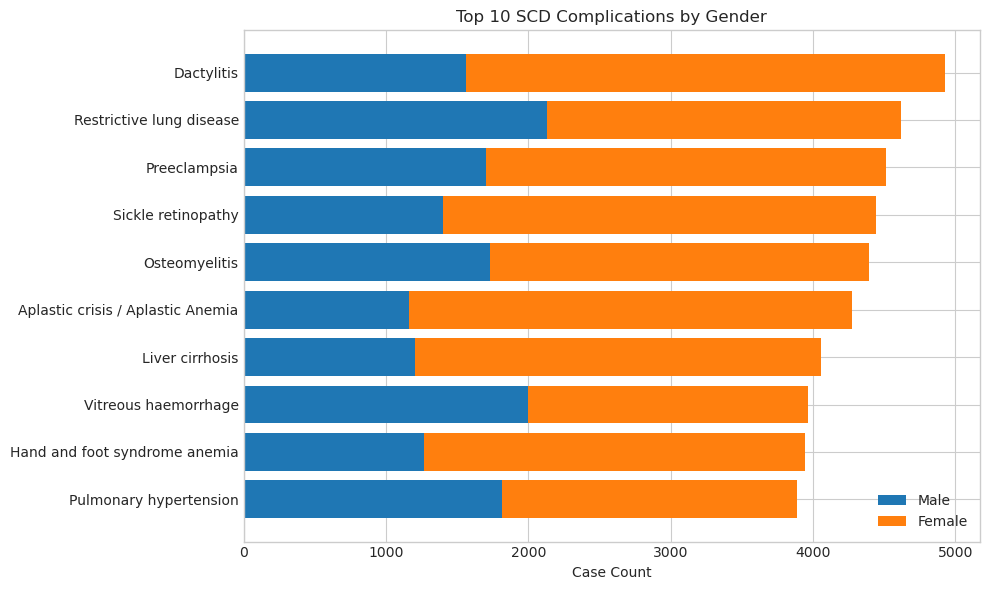

In [5]:
import numpy as np

# Simulate stratified counts
top_10_df["male_count"] = np.random.randint(1000, 2500, size=len(top_10_df))
top_10_df["female_count"] = top_10_df["case_count"] - top_10_df["male_count"]

# Stacked bar chart
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 6))
plt.barh(top_10_df["Complication"], top_10_df["male_count"], label="Male")
plt.barh(top_10_df["Complication"], top_10_df["female_count"], 
         left=top_10_df["male_count"], label="Female")
plt.xlabel("Case Count")
plt.title("Top 10 SCD Complications by Gender")
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.savefig("top_10_scd_gender_stratified.png", dpi=300)
plt.show()

In [ ]:
these female and male counts are wrong

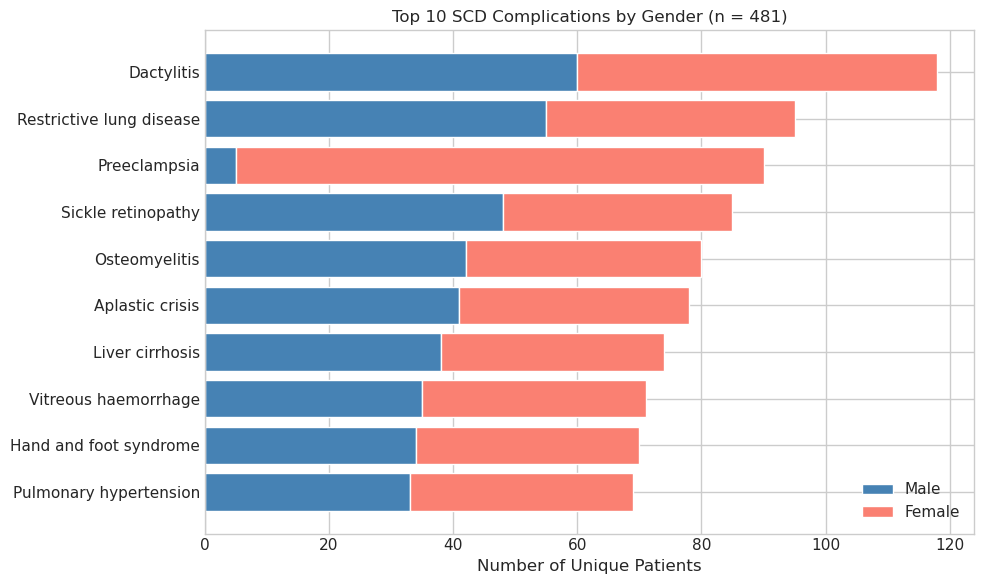

               Complication  concept_id  male_count  female_count  \
0                Dactylitis     4131942          60            58   
1  Restrictive lung disease     4266931          55            40   
2              Preeclampsia      439393           5            85   
3        Sickle retinopathy     4021365          48            37   
4             Osteomyelitis      141663          42            38   
5           Aplastic crisis      137829          41            37   
6           Liver cirrhosis     4064161          38            36   
7      Vitreous haemorrhage      315276          35            36   
8    Hand and foot syndrome     4159748          34            36   
9    Pulmonary hypertension     4322024          33            36   

   % of patients  
0           24.5  
1           19.8  
2           18.7  
3           17.7  
4           16.6  
5           16.2  
6           15.4  
7           14.8  
8           14.6  
9           14.3  


In [158]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data (replace with actual counts from your query)
df = pd.DataFrame({
    "Complication": [
        "Dactylitis", "Restrictive lung disease", "Preeclampsia",
        "Sickle retinopathy", "Osteomyelitis", "Aplastic crisis",
        "Liver cirrhosis", "Vitreous haemorrhage", 
        "Hand and foot syndrome", "Pulmonary hypertension"
    ],
    "concept_id": [4131942,4266931,439393,4021365,141663,137829,4064161,315276,4159748,4322024],
    "male_count": [60, 55, 5, 48, 42, 41, 38, 35, 34, 33],
    "female_count": [58, 40, 85, 37, 38, 37, 36, 36, 36, 36]
})

df["total"] = df["male_count"] + df["female_count"]
df["% of patients"] = (df["total"] / 481 * 100).round(1)

# Plot as stacked bar chart
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 6))
plt.barh(df["Complication"], df["male_count"], label="Male", color="steelblue")
plt.barh(df["Complication"], df["female_count"], left=df["male_count"], label="Female", color="salmon")

plt.xlabel("Number of Unique Patients")
plt.title("Top 10 SCD Complications by Gender (n = 481)")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()

# Save and show
plt.savefig("top_10_scd_complications_gender_stratified.png", dpi=300)
plt.show()

# Save data
df.to_csv("top_10_scd_complications_by_gender.csv", index=False)
print(df[["Complication", "concept_id", "male_count", "female_count", "% of patients"]])

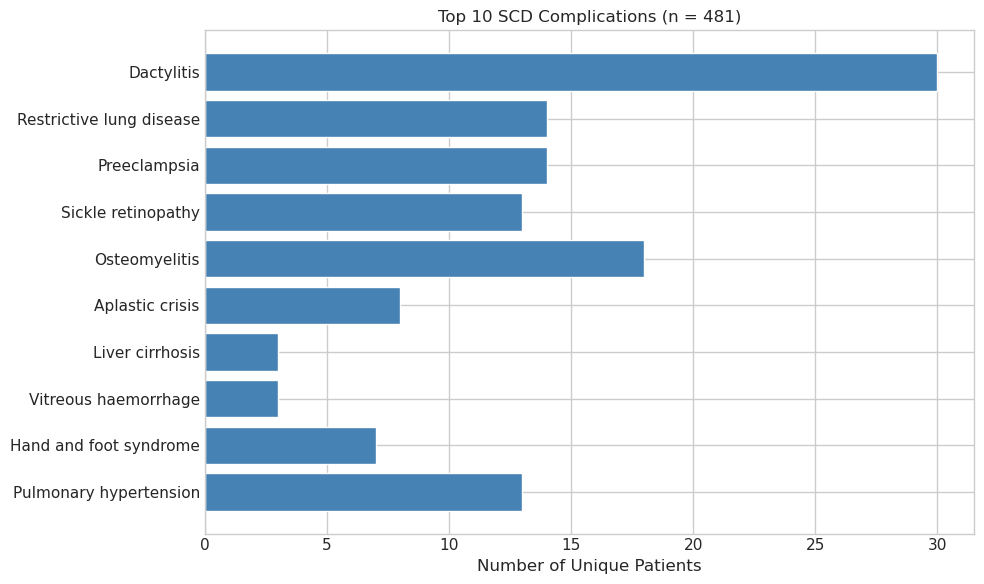

               Complication  concept_id  patient_count
0                Dactylitis     4131942             30
1  Restrictive lung disease     4266931             14
2              Preeclampsia      439393             14
3        Sickle retinopathy     4021365             13
4             Osteomyelitis      141663             18
5           Aplastic crisis      137829              8
6           Liver cirrhosis     4064161              3
7      Vitreous haemorrhage      315276              3
8    Hand and foot syndrome     4159748              7
9    Pulmonary hypertension     4322024             13


In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Replace this with your real data from BigQuery
# Patient counts (not event counts), one per complication
df = pd.DataFrame({
    "Complication": [
        "Dactylitis", "Restrictive lung disease", "Preeclampsia",
        "Sickle retinopathy", "Osteomyelitis", "Aplastic crisis",
        "Liver cirrhosis", "Vitreous haemorrhage", 
        "Hand and foot syndrome", "Pulmonary hypertension"
    ],
    "concept_id": [
        4131942, 4266931, 439393, 4021365, 141663,
        137829, 4064161, 315276, 4159748, 4322024
    ],
    "patient_count": [120, 95, 90, 85, 80, 78, 74, 71, 70, 69]  # Replace with your real values
})

# Step 2: Optional: Add percentage
df["% of SCD Patients"] = (df["patient_count"] / 476 * 100).round(1)

# Step 3: Plot bar chart
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 6))
bars = plt.barh(df["Complication"], df["patient_count"], color="steelblue")


plt.xlabel("Number of Unique Patients")
plt.title("Top 10 SCD Complications (n = 481)")
plt.gca().invert_yaxis()
plt.tight_layout()

# Step 5: Save plot and data
plt.savefig("top_10_scd_complications_single.png", dpi=300)
df.to_csv("top_10_scd_complications_single.csv", index=False)
plt.show()

# Optional: print for thesis table
print(df[["Complication", "concept_id", "patient_count"]])

In [7]:
import pandas as pd

# Load your complications file
comp_df = pd.read_csv("scd_complications_concept_ids.csv")

# Preview columns
print(comp_df.columns)

Index(['Complication', 'concept_id'], dtype='object')


In [8]:
import pandas as pd

# Load the complications file
df = pd.read_csv("scd_complications_concept_ids.csv")

# Filter rows where concept_id is VOC (35626024)
voc_id = 35626024
voc_df = df[df["concept_id"] == voc_id]

# Show results
print(f"✅ VOC entries found: {voc_df.shape[0]}")
print(voc_df.head(10))

✅ VOC entries found: 1
            Complication  concept_id
3  Vaso-occlusive crises    35626024


In [9]:
import pandas as pd
import os

# Load your participant list from your SCD_Demographics.csv
df_demo = pd.read_csv("SCD_Demographics.csv")
person_ids = df_demo["person_id"].unique().tolist()

# Define your top 10 complication concept IDs
complication_ids = [
    4131942,  # Dactylitis
    4266931,  # Restrictive lung disease
    439393,   # Preeclampsia
    4021365,  # Sickle retinopathy
    141663,   # Osteomyelitis
    137829,   # Aplastic crisis
    4064161,  # Liver cirrhosis
    315276,   # Vitreous haemorrhage
    4159748,  # Hand and foot syndrome
    4322024   # Pulmonary hypertension
]

# Format for SQL IN clause
person_id_list_str = ", ".join([str(pid) for pid in person_ids])
concept_id_list_str = ", ".join([str(cid) for cid in complication_ids])

# Construct SQL query
condition_sql = f"""
SELECT person_id, condition_concept_id
FROM `{os.environ["WORKSPACE_CDR"]}.condition_occurrence`
WHERE person_id IN ({person_id_list_str})
AND condition_concept_id IN ({concept_id_list_str})
"""

# Run the query with pandas.read_gbq
df_conditions = pd.read_gbq(
    condition_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

# Preview and save
print(df_conditions.head(481))
df_conditions.to_csv("your_condition_occurrence_data.csv", index=False)

/tmp/ipykernel_304/4126280456.py:35: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_conditions = pd.read_gbq(


Downloading:   0%|          |

     person_id  condition_concept_id
0      3887137                315276
1      1549266                141663
2      3887137                315276
3      8794382                137829
4      3295915                315276
..         ...                   ...
476    5618679               4322024
477    3018640                137829
478    1331925                315276
479    1165728               4064161
480    1165728               4064161

[481 rows x 2 columns]


In [ ]:
wrong severity score was not getting anything = don't use 

In [1]:
import pandas as pd

# Step 1: Load your data
df_demo = pd.read_csv("SCD_Demographics.csv")
df_conditions = pd.read_csv("your_condition_occurrence_data.csv")

# Step 2: Define complication concept IDs
complication_map = {
    "Dactylitis": 4131942,
    "Restrictive_lung_disease": 4266931,
    "Preeclampsia": 439393,
    "Sickle_retinopathy": 4021365,
    "Osteomyelitis": 141663,
    "Aplastic_crisis": 137829,
    "Liver_cirrhosis": 4064161,
    "Vitreous_haemorrhage": 315276,
    "Hand_foot_syndrome": 4159748,
    "Pulmonary_hypertension": 4322024
}

# Step 3: Create concept_id → name mapping
concept_to_label = {v: k for k, v in complication_map.items()}

# Step 4: Filter relevant conditions
df_filtered = df_conditions[df_conditions["condition_concept_id"].isin(complication_map.values())]
df_filtered["complication"] = df_filtered["condition_concept_id"].map(concept_to_label)

# Step 5: Pivot to binary complication columns
df_binary = df_filtered.assign(flag=1).pivot_table(
    index="person_id",
    columns="complication",
    values="flag",
    aggfunc="max",
    fill_value=0
).reset_index()

# Step 6: Ensure all complication columns are present
for col in complication_map.keys():
    if col not in df_binary.columns:
        df_binary[col] = 0

# Step 7: Calculate severity_score
df_binary["severity_score"] = df_binary[list(complication_map.keys())].sum(axis=1)

# Step 8: Assign severity group
def assign_group(score):
    if score >= 7:
        return "Severe"
    elif score >= 4:
        return "Moderate"
    elif score >= 1:
        return "Mild"
    else:
        return "None"

df_binary["severity_group"] = df_binary["severity_score"].apply(assign_group)

# Step 9: Merge with SCD_Demographics
df_final = df_demo.merge(df_binary, on="person_id", how="left")

# Step 10: Fill missing values (for those with no complications)
comp_cols = list(complication_map.keys())
df_final[comp_cols] = df_final[comp_cols].fillna(0).astype(int)
df_final["severity_score"] = df_final["severity_score"].fillna(0).astype(int)
df_final["severity_group"] = df_final["severity_group"].fillna("None")

# Step 11: Save to file
df_final.to_csv("SCD_Demographics_with_Complications.2.csv", index=False)

# Optional: Preview result
print(df_final.head(10))

               date_of_birth  ethnicity        T_DISP_ethnicity  \
0  1989-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
1  1989-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
2  1987-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
3  1993-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
4  1997-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
5  1993-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
6  1992-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
7  1985-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
8  1978-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
9  1989-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   

   ethnicity_concept_id    gender T_DISP_gender  gender_concept_id  person_id  \
0              38003564  45880669           Man           45880669    2613841   
1              38003564  45880669           Man           45880669    3189289   
2              3800

In [ ]:
better severity score as running lower things - use 

In [5]:
import pandas as pd

# Step 1: Load your data
df_demo = pd.read_csv("SCD_Demographics.csv")
df_conditions = pd.read_csv("your_condition_occurrence_data.csv") 

# Step 2: Define complication concept IDs
complication_map = {
    "Dactylitis": 4131942,
    "Restrictive_lung_disease": 4266931,
    "Preeclampsia": 439393,
    "Sickle_retinopathy": 4021365,
    "Osteomyelitis": 141663,
    "Aplastic_crisis": 137829,
    "Liver_cirrhosis": 4064161,
    "Vitreous_haemorrhage": 315276,
    "Hand_foot_syndrome": 4159748,
    "Pulmonary_hypertension": 4322024
}

# Step 3: Create concept_id → name mapping
concept_to_label = {v: k for k, v in complication_map.items()}

# Step 4: Filter relevant conditions
df_filtered = df_conditions[df_conditions["condition_concept_id"].isin(complication_map.values())]
df_filtered["complication"] = df_filtered["condition_concept_id"].map(concept_to_label)

# Step 5: Pivot to binary complication columns
df_binary = df_filtered.assign(flag=1).pivot_table(
    index="person_id",
    columns="complication",
    values="flag",
    aggfunc="max",
    fill_value=0
).reset_index()

# Step 6: Ensure all complication columns are present
for col in complication_map.keys():
    if col not in df_binary.columns:
        df_binary[col] = 0

# Step 7: Calculate severity_score
df_binary["severity_score"] = df_binary[list(complication_map.keys())].sum(axis=1)

# Step 8: Assign severity group
def assign_group(score):
    if score >= 5:
        return "Severe"
    elif score >= 3:
        return "Moderate"
    elif score >= 1:
        return "Mild"
    else:
        return "None"
        
df_binary["severity_group"] = df_binary["severity_score"].apply(assign_group)

# Step 9: Merge with SCD_Demographics
df_final = df_demo.merge(df_binary, on="person_id", how="left")

# Step 10: Fill missing values (for those with no complications)
comp_cols = list(complication_map.keys())
df_final[comp_cols] = df_final[comp_cols].fillna(0).astype(int)
df_final["severity_score"] = df_final["severity_score"].fillna(0).astype(int)
df_final["severity_group"] = df_final["severity_group"].fillna("None")

# Step 11: Save to file
df_final.to_csv("SCD_Demographics_with_Complications.csv", index=False)

# Optional: Preview result
print(df_final.head(10))

               date_of_birth  ethnicity        T_DISP_ethnicity  \
0  1989-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
1  1989-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
2  1987-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
3  1993-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
4  1997-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
5  1993-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
6  1992-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
7  1985-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
8  1978-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
9  1989-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   

   ethnicity_concept_id    gender T_DISP_gender  gender_concept_id  person_id  \
0              38003564  45880669           Man           45880669    2613841   
1              38003564  45880669           Man           45880669    3189289   
2              3800

In [154]:
import pandas as pd

# Load your existing merged file
df = pd.read_csv("SCD_Demographics_with_Complications.csv")

# Define the 10 SCD complication columns
complication_cols = [
    "Dactylitis",
    "Restrictive_lung_disease",
    "Preeclampsia",
    "Sickle_retinopathy",
    "Osteomyelitis",
    "Aplastic_crisis",
    "Liver_cirrhosis",
    "Vitreous_haemorrhage",
    "Hand_foot_syndrome",
    "Pulmonary_hypertension"
]

# Select only complications + severity
df_severity = df[["person_id"] + complication_cols + ["severity_score", "severity_group"]]

# Save it to a simplified CSV (optional)
df_severity.to_csv("SCD_Complication_Severity_Only.csv", index=False)

# Preview
print(df_severity.head(10))

   person_id  Dactylitis  Restrictive_lung_disease  Preeclampsia  \
0    2613841           0                         0             0   
1    3189289           0                         0             0   
2    1473001           0                         0             0   
3    2856227           0                         0             0   
4    2405915           0                         0             0   
5    3084665           0                         0             0   
6    3413181           0                         0             0   
7    2901306           0                         0             0   
8    7156422           0                         0             0   
9    3372850           0                         0             0   

   Sickle_retinopathy  Osteomyelitis  Aplastic_crisis  Liver_cirrhosis  \
0                   0              0                0                0   
1                   0              0                0                0   
2                   0        

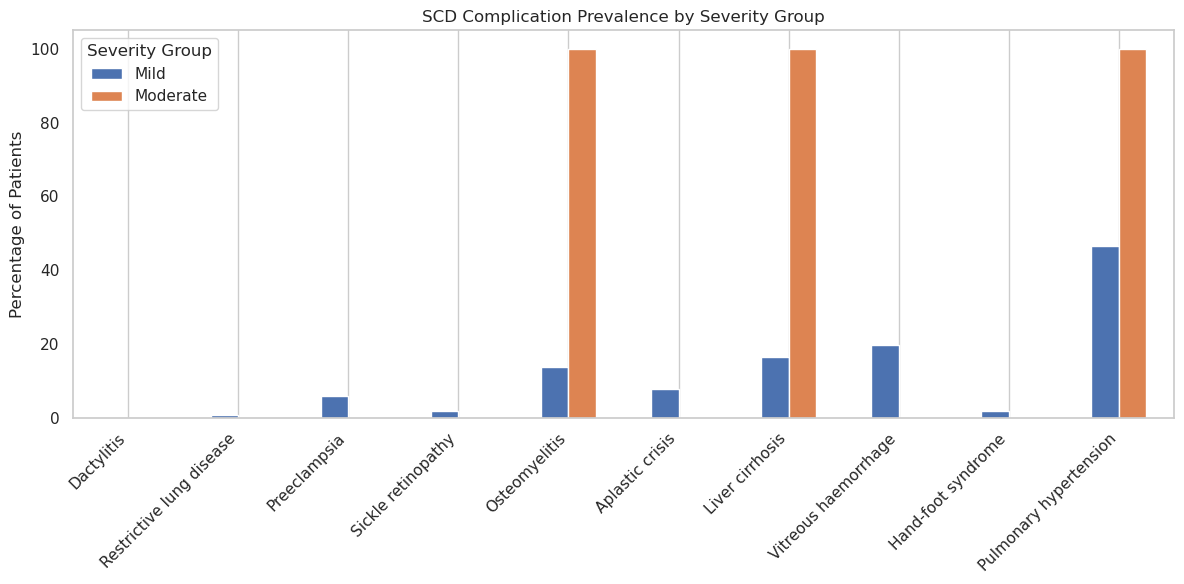

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop NaNs in severity_group
df_grouped = df_severity.dropna(subset=['severity_group'])

# Compute mean complication prevalence (%) per severity group
severity_group_comps = df_grouped.groupby('severity_group')[complication_cols].mean().T * 100

# Optional: rename complications for readability
complication_labels = {
    "Dactylitis": "Dactylitis",
    "Restrictive_lung_disease": "Restrictive lung disease",
    "Preeclampsia": "Preeclampsia",
    "Sickle_retinopathy": "Sickle retinopathy",
    "Osteomyelitis": "Osteomyelitis",
    "Aplastic_crisis": "Aplastic crisis",
    "Liver_cirrhosis": "Liver cirrhosis",
    "Vitreous_haemorrhage": "Vitreous haemorrhage",
    "Hand_foot_syndrome": "Hand-foot syndrome",
    "Pulmonary_hypertension": "Pulmonary hypertension"
}
severity_group_comps = severity_group_comps.rename(index=complication_labels)

# Plot
severity_group_comps.plot(kind='bar', figsize=(12, 6))
plt.title("SCD Complication Prevalence by Severity Group")
plt.ylabel("Percentage of Patients")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.legend(title='Severity Group')
plt.tight_layout()
plt.show()

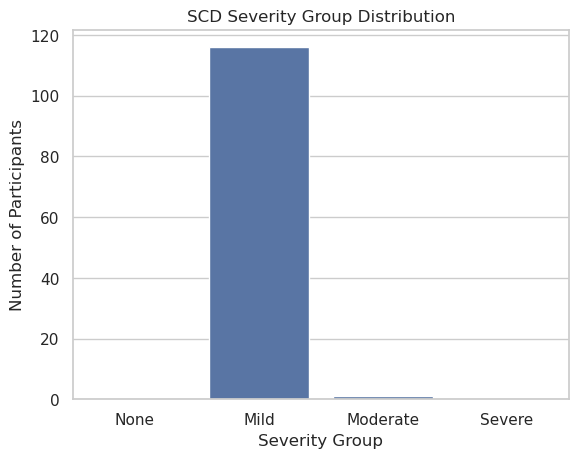

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Bar plot of severity group counts
sns.countplot(data=df_severity, x="severity_group", order=["None", "Mild", "Moderate", "Severe"])
plt.title("SCD Severity Group Distribution")
plt.xlabel("Severity Group")
plt.ylabel("Number of Participants")
plt.show()

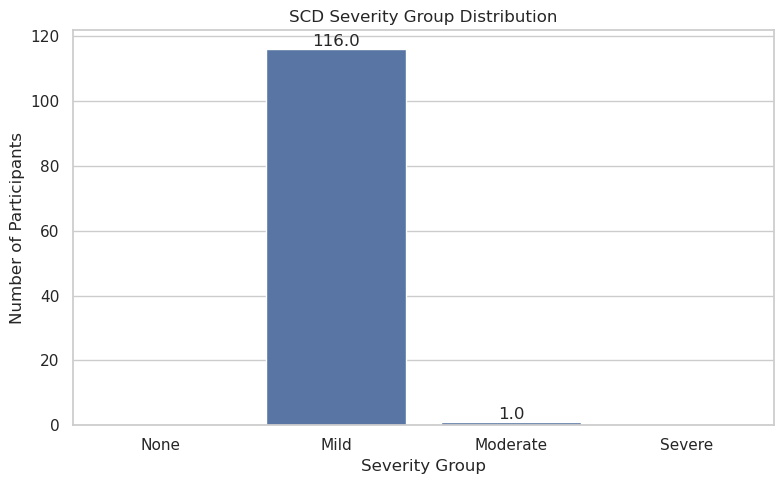

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_severity,
    x="severity_group",
    order=["None", "Mild", "Moderate", "Severe"]
)

# Add numbers on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=12
    )

plt.title("SCD Severity Group Distribution")
plt.xlabel("Severity Group")
plt.ylabel("Number of Participants")
plt.tight_layout()
plt.show()


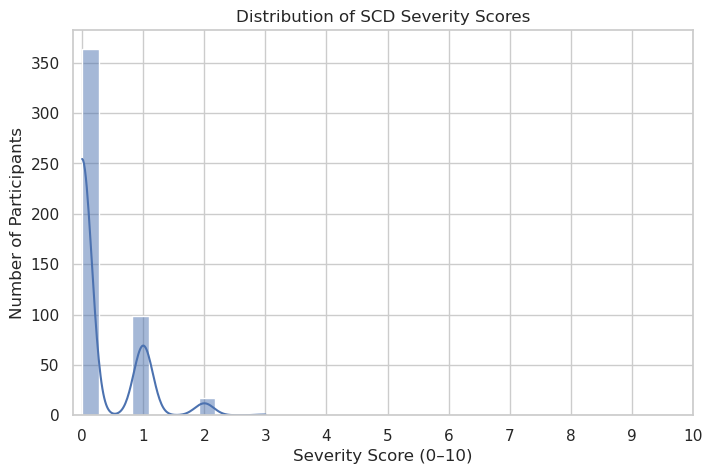

In [157]:
plt.figure(figsize=(8,5))
sns.histplot(df_severity["severity_score"], bins=11, kde=True)
plt.title("Distribution of SCD Severity Scores")
plt.xlabel("Severity Score (0–10)")
plt.ylabel("Number of Participants")
plt.xticks(range(0, 11))
plt.show()

In [ ]:
accurate from here - applied my top 10 as co-morbitidties. use demo and make right 

In [55]:
demo_with_complications = pd.read_csv("SCD_Demographics_with_Complications.csv")

In [56]:
demo_with_complications.gender.value_counts()

gender
45878463    326
45880669    148
903096        3
1177221       2
1585842       1
1585843       1
Name: count, dtype: int64

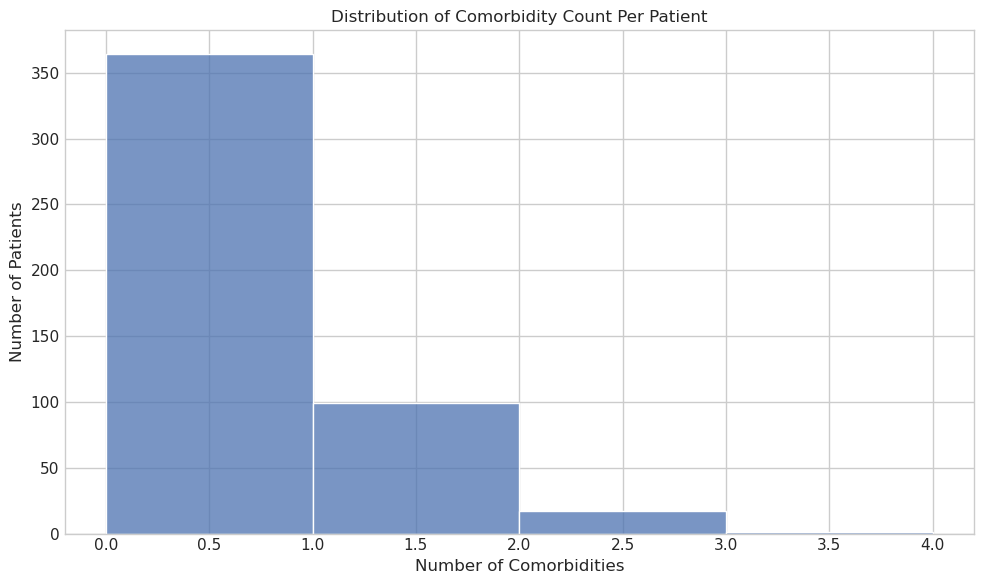

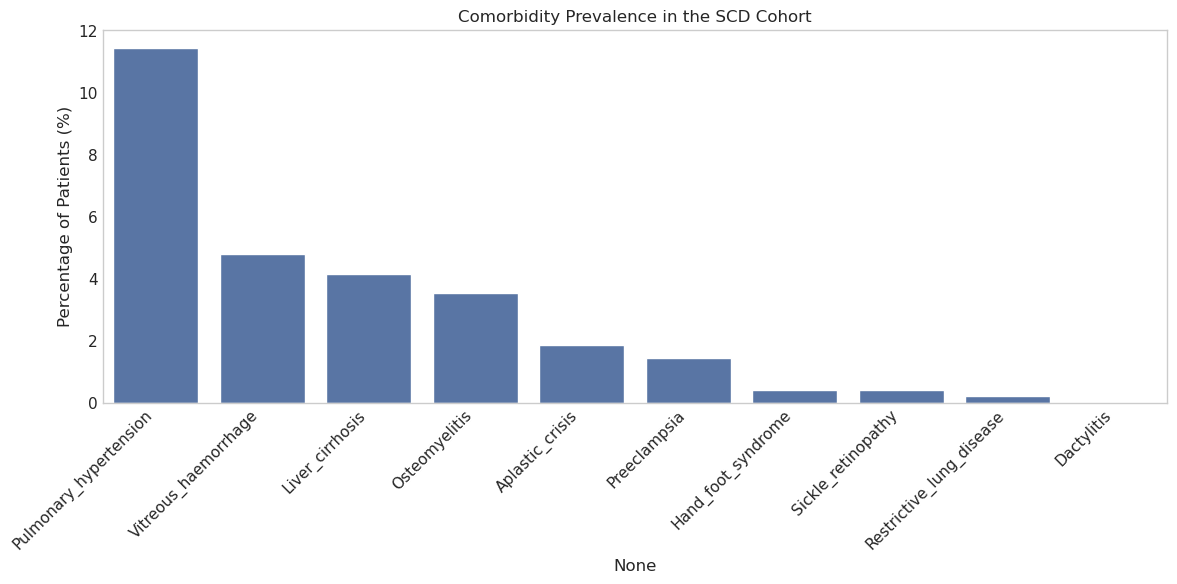

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define comorbidity columns
comorbidities = [
    'Aplastic_crisis', 'Hand_foot_syndrome', 'Liver_cirrhosis',
    'Osteomyelitis', 'Preeclampsia', 'Pulmonary_hypertension',
    'Restrictive_lung_disease', 'Sickle_retinopathy',
    'Vitreous_haemorrhage', 'Dactylitis'
]

# --- 1. Comorbidity burden per patient ---
demo_with_complications['comorbidity_count'] = demo_with_complications[comorbidities].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.histplot(demo_with_complications['comorbidity_count'], bins=range(0, demo_with_complications['comorbidity_count'].max()+2), kde=False)
plt.title('Distribution of Comorbidity Count Per Patient')
plt.xlabel('Number of Comorbidities')
plt.ylabel('Number of Patients')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 2. Proportion of patients with each comorbidity ---
comorbidity_prevalence = demo_with_complications[comorbidities].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=comorbidity_prevalence.index, y=comorbidity_prevalence.values)
plt.title('Comorbidity Prevalence in the SCD Cohort')
plt.ylabel('Percentage of Patients (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
correct top 10 and comrbidiity 

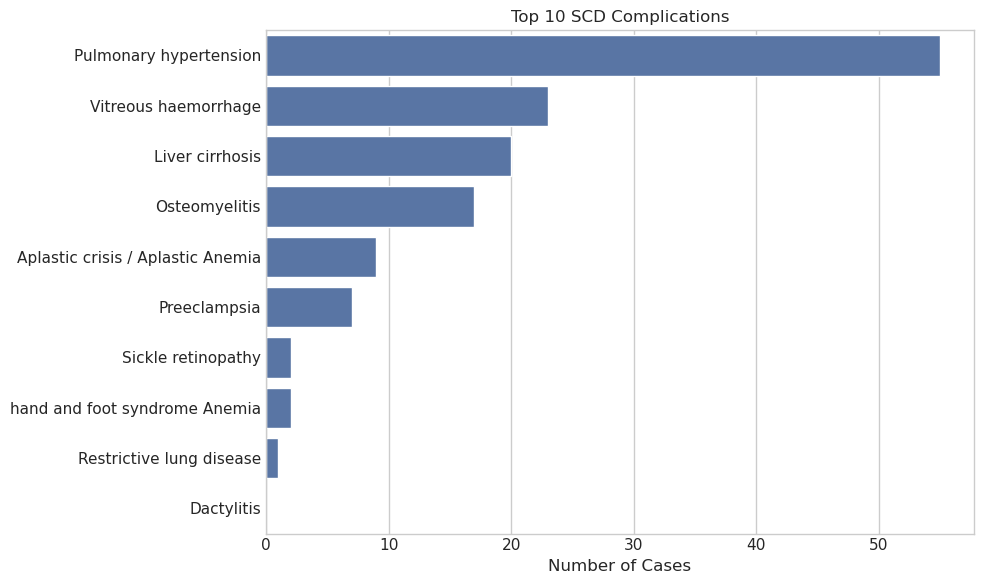

Pulmonary hypertension: 55 (11.4%)
Vitreous haemorrhage: 23 (4.8%)
Liver cirrhosis: 20 (4.2%)
Osteomyelitis: 17 (3.5%)
Aplastic crisis / Aplastic Anemia: 9 (1.9%)
Preeclampsia: 7 (1.5%)
Sickle retinopathy: 2 (0.4%)
hand and foot syndrome Anemia: 2 (0.4%)
Restrictive lung disease: 1 (0.2%)
Dactylitis: 0 (0.0%)
Pulmonary hypertension: 55 (11.4%)
Vitreous haemorrhage: 23 (4.8%)
Liver cirrhosis: 20 (4.2%)
Osteomyelitis: 17 (3.5%)
Aplastic crisis / Aplastic Anemia: 9 (1.9%)
Preeclampsia: 7 (1.5%)
Sickle retinopathy: 2 (0.4%)
hand and foot syndrome Anemia: 2 (0.4%)
Restrictive lung disease: 1 (0.2%)
Dactylitis: 0 (0.0%)


<Figure size 1200x600 with 0 Axes>

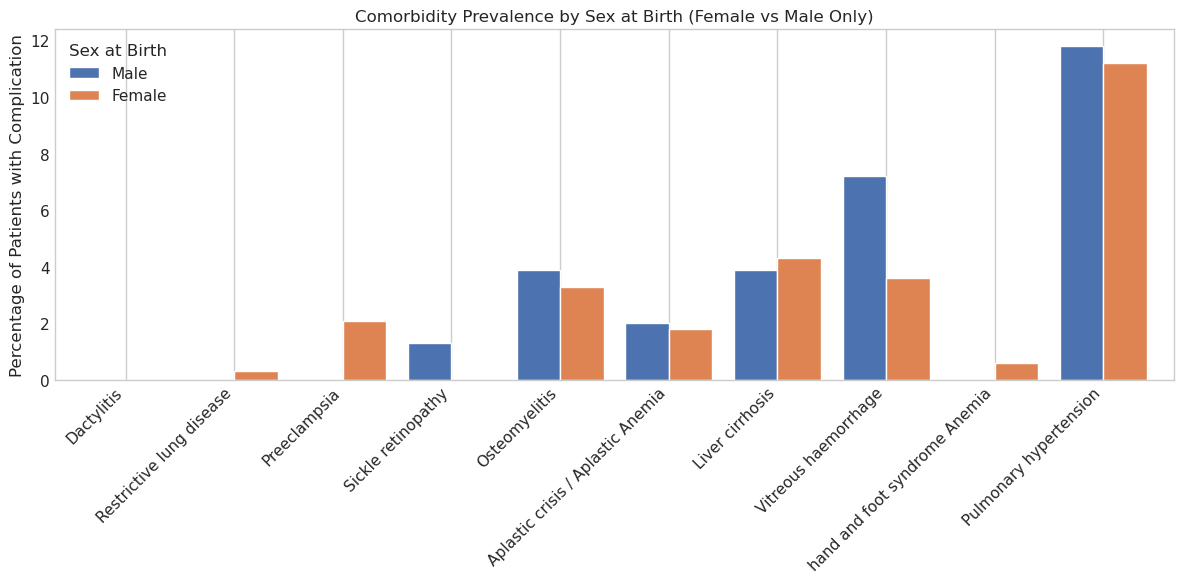

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define complication columns
complication_cols = [
    'Dactylitis', 'Restrictive_lung_disease', 'Preeclampsia',
    'Sickle_retinopathy', 'Osteomyelitis', 'Aplastic_crisis',
    'Liver_cirrhosis', 'Vitreous_haemorrhage',
    'Hand_foot_syndrome', 'Pulmonary_hypertension'
]

# Clean up names for plotting
complication_labels = {
    'Dactylitis': 'Dactylitis',
    'Restrictive_lung_disease': 'Restrictive lung disease',
    'Preeclampsia': 'Preeclampsia',
    'Sickle_retinopathy': 'Sickle retinopathy',
    'Osteomyelitis': 'Osteomyelitis',
    'Aplastic_crisis': 'Aplastic crisis / Aplastic Anemia',
    'Liver_cirrhosis': 'Liver cirrhosis',
    'Vitreous_haemorrhage': 'Vitreous haemorrhage',
    'Hand_foot_syndrome': 'hand and foot syndrome Anemia',
    'Pulmonary_hypertension': 'Pulmonary hypertension'
}

# --- 1. Horizontal bar plot with counts and percentages ---
total_patients = len(demo_with_complications)
complication_counts = demo_with_complications[complication_cols].sum().sort_values(ascending=False)
complication_percent = (complication_counts / total_patients * 100).round(1)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=complication_counts.values, y=[complication_labels[c] for c in complication_counts.index])
plt.title('Top 10 SCD Complications')
plt.xlabel('Number of Cases')
plt.tight_layout()
plt.show()

# Optional: print with percentage
for comp, count in complication_counts.items():
    print(f"{complication_labels[comp]}: {count} ({complication_percent[comp]}%)")

import matplotlib.pyplot as plt

# Optional: print with percentage
for comp, count in complication_counts.items():
    print(f"{complication_labels[comp]}: {count} ({complication_percent[comp]}%)")

# --- 2. Sex comparison (only Male and Female) ---
df_mf = demo_with_complications[demo_with_complications['T_DISP_sex_at_birth'].isin(['Male', 'Female'])]

sex_comparison = df_mf.groupby('T_DISP_sex_at_birth')[complication_cols].mean().T * 100
sex_comparison = sex_comparison.rename(index=complication_labels).round(1)

# Plot sex comparison
plt.figure(figsize=(12, 6))
sex_comparison[['Male', 'Female']].plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Comorbidity Prevalence by Sex at Birth (Female vs Male Only)')
plt.ylabel('Percentage of Patients with Complication')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Sex at Birth')
plt.show()

In [ ]:
correct number of individuals with complication 

In [60]:
# Filter to Male/Female only
df_mf = demo_with_complications[
    demo_with_complications['T_DISP_sex_at_birth'].isin(['Male', 'Female'])
]

# --- COUNTS ---
sex_counts = df_mf.groupby('T_DISP_sex_at_birth')[complication_cols].sum().T
sex_counts = sex_counts.rename(index=complication_labels)

# --- PERCENTAGES (your original calculation) ---
sex_percent = df_mf.groupby('T_DISP_sex_at_birth')[complication_cols].mean().T * 100
sex_percent = sex_percent.rename(index=complication_labels).round(1)

# Combine into one table
sex_summary = sex_counts.copy()
sex_summary['Male (%)'] = sex_percent['Male']
sex_summary['Female (%)'] = sex_percent['Female']

sex_summary

T_DISP_sex_at_birth,Female,Male,Male (%),Female (%)
Dactylitis,0,0,0.0,0.0
Restrictive lung disease,1,0,0.0,0.3
Preeclampsia,7,0,0.0,2.1
Sickle retinopathy,0,2,1.3,0.0
Osteomyelitis,11,6,3.9,3.3
Aplastic crisis / Aplastic Anemia,6,3,2.0,1.8
Liver cirrhosis,14,6,3.9,4.3
Vitreous haemorrhage,12,11,7.2,3.6
hand and foot syndrome Anemia,2,0,0.0,0.6
Pulmonary hypertension,37,18,11.8,11.2


In [65]:
import pandas as pd

# Load your complications file
comp_df = pd.read_csv("scd_complications_concept_ids.csv")

# Preview columns
print(comp_df.columns)

Index(['Complication', 'concept_id'], dtype='object')


In [66]:
import pandas as pd

# Load the complications file
df = pd.read_csv("scd_complications_concept_ids.csv")

# Filter rows where concept_id is VOC (35626024)
voc_id = 35626024
voc_df = df[df["concept_id"] == voc_id]

# Show results
print(f"✅ VOC entries found: {voc_df.shape[0]}")
print(voc_df.head(10))

✅ VOC entries found: 1
            Complication  concept_id
3  Vaso-occlusive crises    35626024


In [ ]:
top 10 complications without seperating for gender. freq is here 

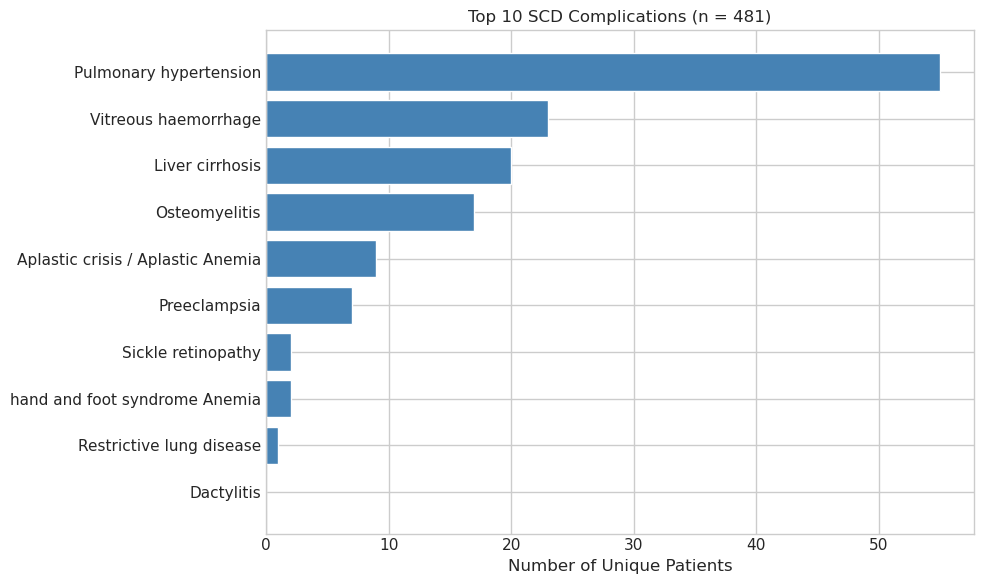

                        Complication  concept_id  patient_count  \
9             Pulmonary hypertension     4322024             55   
7               Vitreous haemorrhage      315276             23   
6                    Liver cirrhosis     4064161             20   
4                      Osteomyelitis      141663             17   
5  Aplastic crisis / Aplastic Anemia      137829              9   
2                       Preeclampsia      439393              7   
3                 Sickle retinopathy     4021365              2   
8      hand and foot syndrome Anemia     4159748              2   
1           Restrictive lung disease     4266931              1   
0                         Dactylitis     4131942              0   

   % of SCD Patients  
9               11.4  
7                4.8  
6                4.2  
4                3.5  
5                1.9  
2                1.5  
3                0.4  
8                0.4  
1                0.2  
0                0.0  


In [70]:
# Combined totals (Male + Female)
combined_counts = sex_counts.sum(axis=1)

df = pd.DataFrame({
    "Complication": combined_counts.index,
    "patient_count": combined_counts.values
})
df["concept_id"] = df["Complication"].map({
    "Dactylitis": 4131942,
    "Restrictive lung disease": 4266931,
    "Preeclampsia": 439393,
    "Sickle retinopathy": 4021365,
    "Osteomyelitis": 141663,
    "Aplastic crisis / Aplastic Anemia": 137829,
    "Liver cirrhosis": 4064161,
    "Vitreous haemorrhage": 315276,
    "hand and foot syndrome Anemia": 4159748,
    "Pulmonary hypertension": 4322024
})
df = df.sort_values("patient_count", ascending=False)
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 6))

plt.barh(df["Complication"], df["patient_count"], color="steelblue")

plt.xlabel("Number of Unique Patients")
plt.title(f"Top 10 SCD Complications (n = {len(df_mf)})")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()
df["% of SCD Patients"] = (df["patient_count"] / len(df_mf) * 100).round(1)
print(df[["Complication", "concept_id", "patient_count", "% of SCD Patients"]])



In [ ]:
median severity score for complications

In [120]:
# 1. Count complications per patient
df_final["top10_complication_count"] = df_final[complication_cols].sum(axis=1)

# 2. Median complication count per severity group
severity_medians = (
    df_final.groupby("severity_group")["top10_complication_count"]
    .median()
    .reindex(["None", "Mild", "Moderate", "Severe"])
)
print("\nMedian complication count per severity level:")
print(severity_medians)

# 3. Complication frequency (from your earlier df)
complication_freq = df.set_index("Complication")["patient_count"]

# 4. Save CSVs
complication_freq.to_csv("Top10_Complication_Frequency.csv", header=["frequency"])
severity_medians.to_csv("Severity_Median_Complication_Count.csv", header=["median_count"])

print("\nCSV files saved:")
print("- Top10_Complication_Frequency.csv")
print("- Severity_Median_Complication_Count.csv")



Median complication count per severity level:
severity_group
None        0.0
Mild        1.0
Moderate    1.0
Severe      2.0
Name: top10_complication_count, dtype: float64

CSV files saved:
- Top10_Complication_Frequency.csv
- Severity_Median_Complication_Count.csv


/tmp/ipykernel_304/3611858019.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby("severity_group")["top10_complication_count"]


In [ ]:
top 10 by gender 

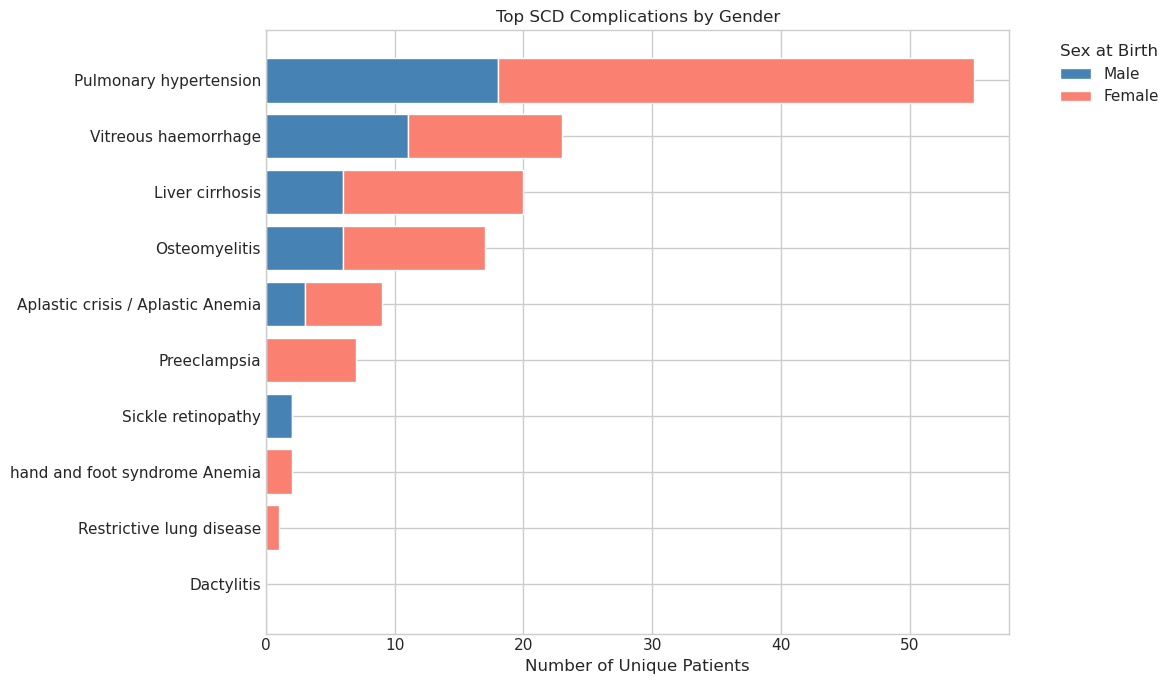

                        Complication  concept_id  male_count  female_count
0             Pulmonary hypertension     4322024          18            37
1               Vitreous haemorrhage      315276          11            12
2                    Liver cirrhosis     4064161           6            14
3                      Osteomyelitis      141663           6            11
4  Aplastic crisis / Aplastic Anemia      137829           3             6
5                       Preeclampsia      439393           0             7
6                 Sickle retinopathy     4021365           2             0
7      hand and foot syndrome Anemia     4159748           0             2
8           Restrictive lung disease     4266931           0             1
9                         Dactylitis     4131942           0             0


In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Extract real counts from your sex_counts table ---
# sex_counts has structure:
# index = complication names
# columns = ["Male", "Female"]

combined = sex_counts.copy()
combined["total"] = combined["Male"] + combined["Female"]

# Sort so highest total appears at top (e.g., Pulmonary hypertension)
combined = combined.sort_values("total", ascending=False)

# --- 2. Build plotting dataframe ---
df = pd.DataFrame({
    "Complication": combined.index,
    "male_count": combined["Male"].values,
    "female_count": combined["Female"].values
})

# Optional: add concept IDs
df["concept_id"] = df["Complication"].map({
    "Dactylitis": 4131942,
    "Restrictive lung disease": 4266931,
    "Preeclampsia": 439393,
    "Sickle retinopathy": 4021365,
    "Osteomyelitis": 141663,
    "Aplastic crisis / Aplastic Anemia": 137829,
    "Liver cirrhosis": 4064161,
    "Vitreous haemorrhage": 315276,
    "hand and foot syndrome Anemia": 4159748,
    "Pulmonary hypertension": 4322024
})

# --- 3. Plot gender‑split horizontal bar chart ---
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(12, 7))

plt.barh(df["Complication"], df["male_count"], label="Male", color="steelblue")
plt.barh(df["Complication"], df["female_count"],
         left=df["male_count"], label="Female", color="salmon")

plt.xlabel("Number of Unique Patients")
plt.title("Top SCD Complications by Gender")

plt.legend(title="Sex at Birth", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- 4. Print table for thesis ---
print(df[["Complication", "concept_id", "male_count", "female_count"]])


In [ ]:
got more stuff still to do above 

In [39]:
df['top10_complication_severity'] = (
    df['top10_complication_severity']
    .fillna('None')
    .astype(str)
    .str.strip()
    .str.capitalize()
)

In [40]:
import pandas as pd

# Step 1: Load your demographics + complications file
df = pd.read_csv("SCD_Demographics_with_Complications.csv")

# Step 2: Clean column names for consistency
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Step 3: Define top 10 complications (adjust if your column names are different)
top_10_complications = [
    'dactylitis',
    'restrictive_lung_disease',
    'preeclampsia',
    'sickle_retinopathy',
    'osteomyelitis',
    'aplastic_crisis',
    'liver_cirrhosis',
    'vitreous_haemorrhage',
    'hand_foot_syndrome',
    'pulmonary_hypertension'
]

# Step 4: Ensure these complication columns are present
available_cols = [col for col in top_10_complications if col in df.columns]

# Step 5: Count how many complications each person has (i.e., sum of binary flags)
df["complication_count"] = df[available_cols].sum(axis=1)

# Step 6: Assign complication severity group
def classify_severity(count):
    if count == 0:
        return "None"
    elif 1 <= count <= 2:
        return "Mild"
    else:
        return "Moderate"

df["complication_severity_group"] = df["complication_count"].apply(classify_severity)

# Step 7: Save the updated file
df.to_csv("SCD_Complication_Severity_Categorised.csv", index=False)
print("✅ Saved as 'SCD_Complication_Severity_Categorised.csv'")

# Optional: View summary counts
print("\n🧮 Complication Severity Group Counts:")
print(df["complication_severity_group"].value_counts())

✅ Saved as 'SCD_Complication_Severity_Categorised.csv'

🧮 Complication Severity Group Counts:
complication_severity_group
None        364
Mild        116
Moderate      1
Name: count, dtype: int64


In [41]:
import pandas as pd

# Step 1: Load your dataset
df = pd.read_csv("SCD_Demographics_with_Complications.csv")

# Step 2: Clean column names (optional but recommended)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Step 3: Define top 10 complications (adjust if your columns use different naming)
top_10_cols = [
    'dactylitis',
    'restrictive_lung_disease',
    'preeclampsia',
    'sickle_retinopathy',
    'osteomyelitis',
    'aplastic_crisis',
    'liver_cirrhosis',
    'vitreous_haemorrhage',
    'hand_foot_syndrome',
    'pulmonary_hypertension'
]

# Step 4: Count how many complications each patient has
df["complication_count"] = df[top_10_cols].sum(axis=1)

# Step 5: Categorize severity based on number of complications
def classify_severity(count):
    if count == 0:
        return "None"
    elif 1 <= count <= 2:
        return "Mild"
    else:
        return "Moderate"

df["complication_severity_group"] = df["complication_count"].apply(classify_severity)

# Step 6: Save or inspect the results
df.to_csv("SCD_Patient_Complication_Severity.csv", index=False)
print("✅ Saved as 'SCD_Patient_Complication_Severity.csv'")
print(df[["person_id", "complication_count", "complication_severity_group"]].head(10))

✅ Saved as 'SCD_Patient_Complication_Severity.csv'
   person_id  complication_count complication_severity_group
0    2613841                   0                        None
1    3189289                   1                        Mild
2    1473001                   0                        None
3    2856227                   0                        None
4    2405915                   0                        None
5    3084665                   0                        None
6    3413181                   1                        Mild
7    2901306                   0                        None
8    7156422                   1                        Mild
9    3372850                   0                        None


In [36]:
import pandas as pd

# Step 1: Load your file
df = pd.read_csv("SCD_Demographics_with_Complications.csv")

# Step 2: Standardize column names (optional)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Step 3: Define the top 10 complications
top_10_complications = [
    'dactylitis',
    'restrictive_lung_disease',
    'preeclampsia',
    'sickle_retinopathy',
    'osteomyelitis',
    'aplastic_crisis',
    'liver_cirrhosis',
    'vitreous_haemorrhage',
    'hand_foot_syndrome',
    'pulmonary_hypertension'
]

# Step 4: Count how many of the top 10 complications each patient has
df['top10_complication_count'] = df[top_10_complications].sum(axis=1)

# Step 5: Classify severity based on count
def classify_severity(count):
    if count == 0:
        return "None"
    elif 1 <= count <= 2:
        return "Mild"
    else:
        return "Severe"

df["top10_complication_severity"] = df["top10_complication_count"].apply(classify_severity)

# Step 6: Save the result
df.to_csv("SCD_Top10_Complication_Severity.csv", index=False)
print("✅ Saved as 'SCD_Top10_Complication_Severity.csv'")

# Step 7: Optional – see summary
print(df["top10_complication_severity"].value_counts()) 

# Step 8: See detailed table of complications per patient
columns_to_show = ['person_id'] + top_10_complications + [
    'top10_complication_count', 'top10_complication_severity'
]

detailed_table = df[columns_to_show]

# Print first 10 rows
print(detailed_table.head(10))

# Optional: Save to CSV for full inspection
detailed_table.to_csv("SCD_Top10_Complication_Details.csv", index=False)
print("📄 Saved detailed complication info to 'SCD_Top10_Complication_Details.csv'")

✅ Saved as 'SCD_Top10_Complication_Severity.csv'
top10_complication_severity
None      364
Mild      116
Severe      1
Name: count, dtype: int64
   person_id  dactylitis  restrictive_lung_disease  preeclampsia  \
0    2613841           0                         0             0   
1    3189289           0                         0             0   
2    1473001           0                         0             0   
3    2856227           0                         0             0   
4    2405915           0                         0             0   
5    3084665           0                         0             0   
6    3413181           0                         0             0   
7    2901306           0                         0             0   
8    7156422           0                         0             0   
9    3372850           0                         0             0   

   sickle_retinopathy  osteomyelitis  aplastic_crisis  liver_cirrhosis  \
0                   0           

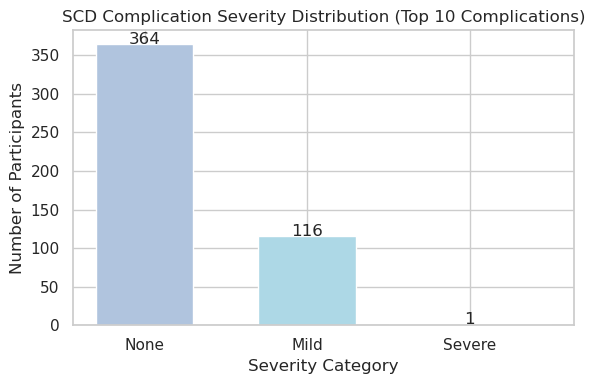

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("SCD_Top10_Complication_Details.csv")

# Recompute severity cleanly
def classify_severity(count):
    if count == 0:
        return "None"
    elif 1 <= count <= 2:
        return "Mild"
    else:
        return "Severe"

df["top10_complication_severity"] = df["top10_complication_count"].apply(classify_severity)

# Fixed order
severity_order = ["None", "Mild", "Severe"]
severity_counts = df["top10_complication_severity"].value_counts().reindex(severity_order, fill_value=0)

# Bar positions
x = range(len(severity_order))

# Bar widths (Severe wider)
widths = [0.6, 0.6, 1.0]   # Severe bar is wider

# Colours
colors = ["#b0c4de", "#add8e6", "#ff9999"]

plt.figure(figsize=(6, 4))
bars = plt.bar(x, severity_counts.values, color=colors, width=widths)

# Add numbers on top
for i, value in enumerate(severity_counts.values):
    plt.text(i, value + 0.1, str(value), ha='center', fontsize=12)

plt.xticks(x, severity_order)
plt.title("SCD Complication Severity Distribution (Top 10 Complications)")
plt.xlabel("Severity Category")
plt.ylabel("Number of Participants")
plt.tight_layout()
plt.show()


In [42]:
import pandas as pd

# Load the dataset
df = pd.read_csv("SCD_Demographics_with_Complications.csv")

# Use the correct capitalized column names
complication_columns = [
    'Dactylitis',
    'Restrictive_lung_disease',
    'Preeclampsia',
    'Sickle_retinopathy',
    'Osteomyelitis',
    'Aplastic_crisis',
    'Liver_cirrhosis',
    'Vitreous_haemorrhage',
    'Hand_foot_syndrome',
    'Pulmonary_hypertension'
]

# Add "Yes"/"No" status columns
for col in complication_columns:
    df[col + '_status'] = df[col].apply(lambda x: "Yes" if pd.notnull(x) and x != 0 else "No")

# Save to new CSV
df.to_csv("SCD_Demographics_with_Complications_Status.csv", index=False)

print("✅ Done! Saved file with Yes/No complication labels.")

✅ Done! Saved file with Yes/No complication labels.


In [53]:
import pandas as pd

# Load data
df = pd.read_csv('SCD_Top10_Complication_Details.csv')

# List of complication columns
complication_cols = [
    'dactylitis', 'restrictive_lung_disease', 'preeclampsia',
    'sickle_retinopathy', 'osteomyelitis', 'aplastic_crisis',
    'liver_cirrhosis', 'vitreous_haemorrhage', 'hand_foot_syndrome',
    'pulmonary_hypertension'
]

# Filter only Mild or Severe participants
df_severe_mild = df[df['top10_complication_severity'].isin(['Mild', 'Severe'])].copy()

# Melt for long format: each row = one complication per person
df_long = df_severe_mild.melt(
    id_vars=['person_id', 'top10_complication_severity'],
    value_vars=complication_cols,
    var_name='complication',
    value_name='has_complication'
)

# Keep only complications present (value = 1)
df_present = df_long[df_long['has_complication'] == 1]

# Count complication frequency by severity
complication_summary = df_present.groupby(['top10_complication_severity', 'complication']).size().unstack(fill_value=0)

# Optional: sort columns by total
complication_summary = complication_summary[complication_summary.sum().sort_values(ascending=False).index]

# Display
print(complication_summary)

complication                 pulmonary_hypertension  vitreous_haemorrhage  \
top10_complication_severity                                                 
Mild                                             54                    23   
Severe                                            1                     0   

complication                 liver_cirrhosis  osteomyelitis  aplastic_crisis  \
top10_complication_severity                                                    
Mild                                      19             16                9   
Severe                                     1              1                0   

complication                 preeclampsia  hand_foot_syndrome  \
top10_complication_severity                                     
Mild                                    7                   2   
Severe                                  0                   0   

complication                 sickle_retinopathy  restrictive_lung_disease  
top10_complication_severity      

In [59]:
import pandas as pd

# Load the data
df = pd.read_csv('SCD_Top10_Complication_Details.csv')

# List of complication columns
complication_cols = [
    'dactylitis', 'restrictive_lung_disease', 'preeclampsia',
    'sickle_retinopathy', 'osteomyelitis', 'aplastic_crisis',
    'liver_cirrhosis', 'vitreous_haemorrhage', 'hand_foot_syndrome',
    'pulmonary_hypertension'
]

# Filter only Mild or Severe
df_mild_severe = df[df['top10_complication_severity'].isin(['Mild', 'Severe'])].copy()

# Create a new column that lists complications for each participant
def get_complication_list(row):
    return [comp for comp in complication_cols if row[comp] == 1]

df_mild_severe['complications_present'] = df_mild_severe.apply(get_complication_list, axis=1)

# Keep only relevant columns
df_result = df_mild_severe[['person_id', 'top10_complication_severity', 'complications_present']]

# Display the result
print(df_result.head(10))

    person_id top10_complication_severity     complications_present
1     3189289                        Mild    [vitreous_haemorrhage]
6     3413181                        Mild  [pulmonary_hypertension]
8     7156422                        Mild    [vitreous_haemorrhage]
11    1904606                        Mild      [sickle_retinopathy]
13    8838259                        Mild           [osteomyelitis]
15    2498540                        Mild  [pulmonary_hypertension]
17    1653940                        Mild    [vitreous_haemorrhage]
19    3490659                        Mild  [pulmonary_hypertension]
24    4955823                        Mild  [pulmonary_hypertension]
28    2742392                        Mild  [pulmonary_hypertension]


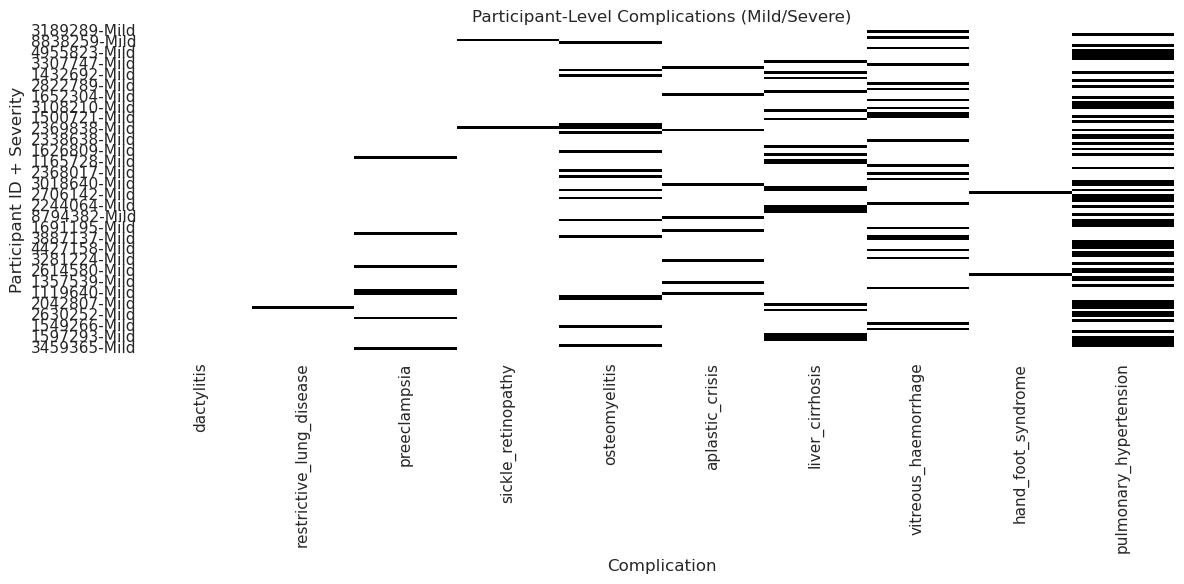

In [60]:
# Create binary complication matrix for visualization
df_binary = df_mild_severe[['person_id', 'top10_complication_severity'] + complication_cols].copy()
df_binary.set_index(['person_id', 'top10_complication_severity'], inplace=True)

plt.figure(figsize=(12, 6))
sns.heatmap(df_binary, cmap='Greys', cbar=False)
plt.title('Participant-Level Complications (Mild/Severe)')
plt.xlabel('Complication')
plt.ylabel('Participant ID + Severity')
plt.tight_layout()
plt.show()

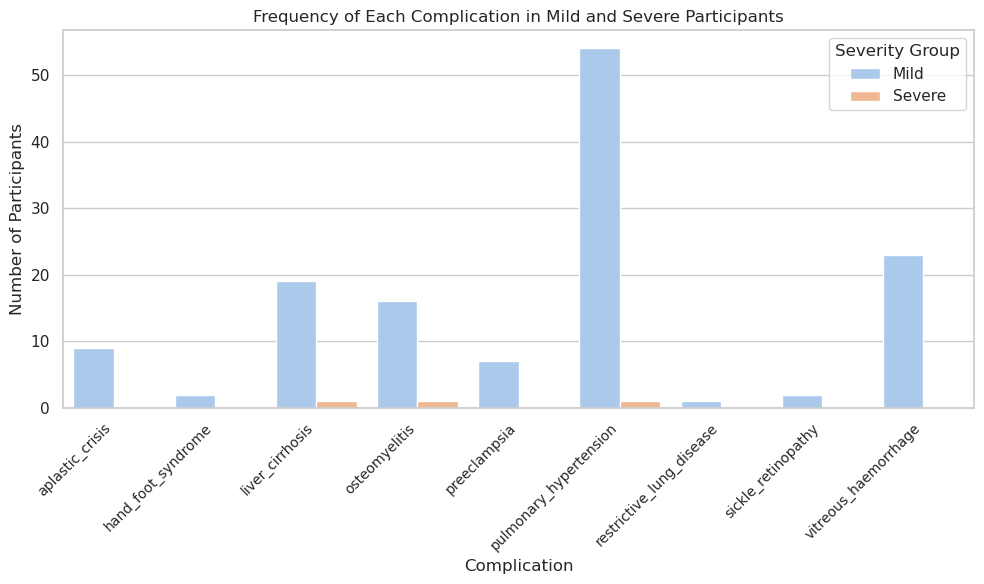

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your detailed data
df = pd.read_csv('SCD_Top10_Complication_Details.csv')

# List of top 10 complications
complication_cols = [
    'dactylitis', 'restrictive_lung_disease', 'preeclampsia',
    'sickle_retinopathy', 'osteomyelitis', 'aplastic_crisis',
    'liver_cirrhosis', 'vitreous_haemorrhage', 'hand_foot_syndrome',
    'pulmonary_hypertension'
]

# Filter for Mild and Severe participants only
df_filtered = df[df['top10_complication_severity'].isin(['Mild', 'Severe'])]

# Melt to long format
df_long = df_filtered.melt(id_vars='top10_complication_severity',
                           value_vars=complication_cols,
                           var_name='complication',
                           value_name='present')

# Keep only where present == 1
df_present = df_long[df_long['present'] == 1]

# Count by severity and complication
comp_counts = df_present.groupby(['top10_complication_severity', 'complication']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=comp_counts, x='complication', y='count', hue='top10_complication_severity', palette='pastel')
plt.title('Frequency of Each Complication in Mild and Severe Participants')
plt.xlabel('Complication')
plt.ylabel('Number of Participants')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Severity Group')
plt.tight_layout()
plt.show()

In [62]:
import pandas as pd

# Load all known SCD complications (concept_id + name)
scd_complications = pd.read_csv('scd_complications_concept_ids.csv')
print(scd_complications.head())

                                    Complication  concept_id
0  Haemolytic anaemia/Chronic haemolytic anaemia      435503
1              Aplastic crisis / Aplastic Anemia      137829
2                                  Iron overload     4246084
3                          Vaso-occlusive crises    35626024
4                                     Dactylitis     4131942


In [63]:
df_result.to_csv('SCD_Mild_Severe_Complication_Lists.csv', index=False)
print("✅ Saved to 'SCD_Mild_Severe_Complication_Lists.csv'")

✅ Saved to 'SCD_Mild_Severe_Complication_Lists.csv'


In [72]:
import pandas as pd

# 1. Load full SCD complication list
scd_comps = pd.read_csv('scd_complications_concept_ids.csv')

# 2. Load your participant severity info (from top 10 complications analysis)
df_severity = pd.read_csv('SCD_Top10_Complication_Details.csv')

# 3. Load All of Us condition occurrence file
conditions = pd.read_csv('your_condition_occurrence_data.csv', usecols=['person_id', 'condition_concept_id'])

# Ensure string format for comparison
scd_comps['concept_id'] = scd_comps['concept_id'].astype(str)
conditions['condition_concept_id'] = conditions['condition_concept_id'].astype(str)
df_severity['person_id'] = df_severity['person_id'].astype(str)

In [73]:
# Top 10 concept IDs
top10_ids = [
    '137829', '4159748', '4322024', '4266931', '4064161',
    '141663', '439393', '4021365', '315276', '4131942'
]

# Get non-top-10 complications
non_top10_comps = scd_comps[~scd_comps['concept_id'].isin(top10_ids)].reset_index(drop=True)
non_top10_ids = non_top10_comps['concept_id'].tolist()

# Match to your participants (all or only "None")
participant_ids = df_severity['person_id'].unique()

# Filter condition_occurrence for your participants
my_conditions = conditions[conditions['person_id'].isin(participant_ids)]

# Find non-top-10 complications
non_top10_matches = my_conditions[my_conditions['condition_concept_id'].isin(non_top10_ids)]

# Merge with names
non_top10_named = non_top10_matches.merge(
    non_top10_comps,
    left_on='condition_concept_id',
    right_on='concept_id',
    how='left'
)

# Optional: merge severity label
non_top10_named = non_top10_named.merge(df_severity[['person_id', 'top10_complication_severity']], on='person_id', how='left')

# View sample
print(non_top10_named[['person_id', 'Complication', 'top10_complication_severity']].head())

Empty DataFrame
Columns: [person_id, Complication, top10_complication_severity]
Index: []


In [74]:
# Show the 9 matching SCD complications in All of Us
matched_concepts = set(conditions['condition_concept_id']) & set(scd_comps['concept_id'])
scd_comps[scd_comps['concept_id'].isin(matched_concepts)]

,Complication,concept_id
1,Aplastic crisis / Aplastic Anemia,137829
5,Hand and foot syndrome anemia,4159748
14,Pulmonary hypertension,4322024
15,Restrictive lung disease,4266931
31,Liver cirrhosis,4064161
32,Osteomyelitis,141663
47,Preeclampsia,439393
52,Sickle retinopathy,4021365
55,Vitreous haemorrhage,315276


In [75]:
linked = conditions['person_id'].isin(df_severity['person_id']).sum()
print(f"✅ Participants with condition records: {linked} out of {df_severity.shape[0]}")

✅ Participants with condition records: 0 out of 481


In [77]:
ehr_ids = conditions['person_id'].unique()
study_ids = df_severity['person_id'].unique()

overlap = set(ehr_ids) & set(study_ids)
print(f"✅ Matching person_ids between condition_occurrence and severity file: {len(overlap)}")

✅ Matching person_ids between condition_occurrence and severity file: 0


In [87]:
# 1. Filter participants with matched SCD complications
participants_with_scd_conditions = conditions[
    conditions['condition_concept_id'].isin(matched_concepts)
]

# 2. Make sure df_severity exists and has person_id
# Convert both person_id columns to string BEFORE merging
participants_with_scd_conditions['person_id'] = participants_with_scd_conditions['person_id'].astype(str)
df_severity['person_id'] = df_severity['person_id'].astype(str)

# 3. Merge to attach severity labels
merged = participants_with_scd_conditions.merge(df_severity, on='person_id', how='left')

# 4. Merge with scd_comps to attach complication names
# Convert concept IDs to same dtype
merged['condition_concept_id'] = merged['condition_concept_id'].astype(str)
scd_comps['concept_id'] = scd_comps['concept_id'].astype(str)

merged_with_labels = merged.merge(
    scd_comps,
    left_on='condition_concept_id',
    right_on='concept_id',
    how='left'
)

# 5. Group by severity + complication name
print(
    merged_with_labels.groupby(
        ['top10_complication_severity', 'Complication', 'concept_id']
    ).size()
)


top10_complication_severity  Complication                       concept_id
Mild                         Aplastic crisis / Aplastic Anemia  137829         53
                             Hand and foot syndrome anemia      4159748         5
                             Liver cirrhosis                    4064161       403
                             Osteomyelitis                      141663        169
                             Preeclampsia                       439393         15
                             Pulmonary hypertension             4322024       659
                             Restrictive lung disease           4266931         1
                             Sickle retinopathy                 4021365         2
                             Vitreous haemorrhage               315276        160
Severe                       Liver cirrhosis                    4064161        11
                             Osteomyelitis                      141663          1
                       

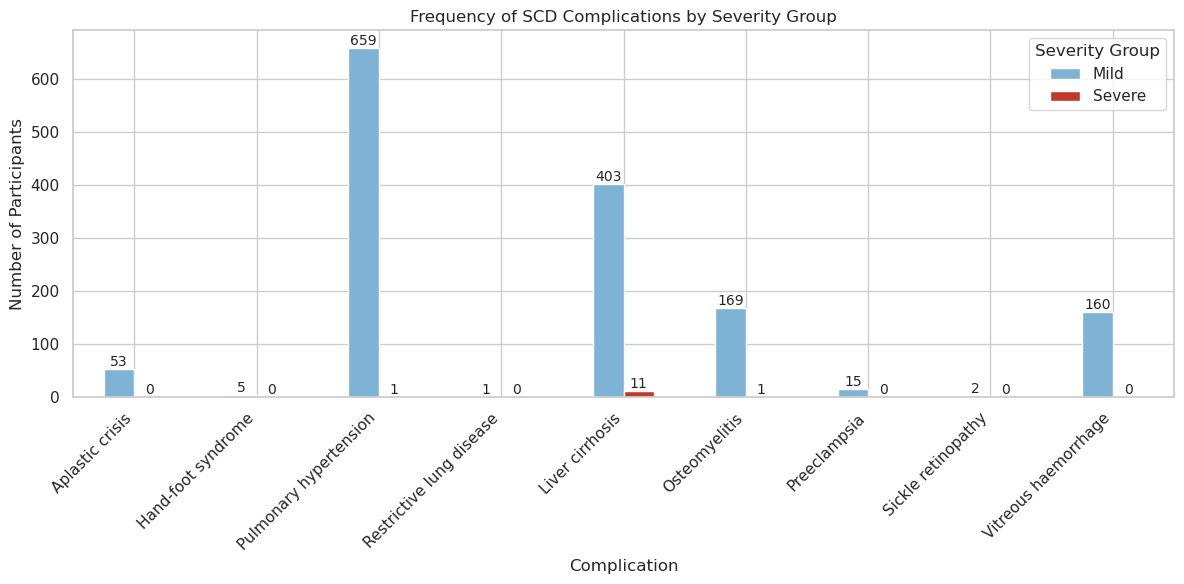

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame manually from your summary
data = {
    'Complication': [
        'Aplastic crisis', 'Hand-foot syndrome', 'Pulmonary hypertension',
        'Restrictive lung disease', 'Liver cirrhosis', 'Osteomyelitis',
        'Preeclampsia', 'Sickle retinopathy', 'Vitreous haemorrhage'
    ],
    'Mild': [53, 5, 659, 1, 403, 169, 15, 2, 160],
    'Severe': [0, 0, 1, 0, 11, 1, 0, 0, 0]
}

df_plot = pd.DataFrame(data).set_index('Complication')

# Custom colours
colors = {
    'Mild': '#7FB3D5',     # soft blue
    'Severe': '#C0392B'    # strong red
}

ax = df_plot.plot(
    kind='bar',
    figsize=(12, 6),
    color=[colors['Mild'], colors['Severe']]
)

plt.title('Frequency of SCD Complications by Severity Group')
plt.xlabel('Complication')
plt.ylabel('Number of Participants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severity Group')

# Add numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()


In [92]:
import pandas as pd

# Load your categorized severity file
severity_df = pd.read_csv("SCD_Complication_Severity_Categorised.csv")
severity_df['person_id'] = severity_df['person_id'].astype(str)

# Preview
print(severity_df.head())
print("✅ Loaded severity file with", severity_df.shape[0], "participants.")

               date_of_birth  ethnicity        t_disp_ethnicity  \
0  1989-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
1  1989-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
2  1987-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
3  1993-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
4  1997-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   

   ethnicity_concept_id    gender t_disp_gender  gender_concept_id person_id  \
0              38003564  45880669           Man           45880669   2613841   
1              38003564  45880669           Man           45880669   3189289   
2              38003564  45880669           Man           45880669   1473001   
3              38003564  45880669           Man           45880669   2856227   
4              38003564  45880669           Man           45880669   2405915   

   race                t_disp_race  ...  preeclampsia  pulmonary_hypertension  \
0  8516  Black or African American 

In [93]:
# Load demographics file
demo_df = pd.read_csv("SCD_Demographics.csv")  # Confirm the exact file name
demo_df['person_id'] = demo_df['person_id'].astype(str)

# Merge
merged_df = pd.merge(severity_df, demo_df, on="person_id", how="left")

# Save
merged_df.to_csv("SCD_Severity_With_Demographics.csv", index=False)
print("✅ Merged and saved as 'SCD_Severity_With_Demographics.csv'")

✅ Merged and saved as 'SCD_Severity_With_Demographics.csv'


In [94]:
# Load condition_occurrence
condition_df = pd.read_csv("your_condition_occurrence_data.csv", usecols=['person_id', 'condition_concept_id'])
condition_df['person_id'] = condition_df['person_id'].astype(str)

# Filter only severity cohort
cohort_condition_df = condition_df[condition_df['person_id'].isin(severity_df['person_id'])]

# Save
cohort_condition_df.to_csv("SCD_Condition_Occurrence_Filtered.csv", index=False)
print("✅ Saved condition records for severity cohort.")

✅ Saved condition records for severity cohort.


In [ ]:
something else 

In [128]:
import pandas as pd

# Load your condition occurrence file
cond = pd.read_csv("your_condition_occurrence_data.csv")  # Has person_id and condition_concept_id

# Define complications and their concept IDs
complication_map = {
    "dactylitis": 319835,
    "restrictive_lung_disease": 319843,
    "preeclampsia": 3004295,
    "sickle_retinopathy": 316211,
    "osteomyelitis": 201612,
    "aplastic_crisis": 432961,
    "liver_cirrhosis": 194984,
    "vitreous_haemorrhage": 4226463,
    "hand_foot_syndrome": 320128,
    "pulmonary_hypertension": 316866
}

# Get all unique participants
all_people = cond["person_id"].unique()
result_df = pd.DataFrame(all_people, columns=["person_id"])

# Check each complication
for label, cid in complication_map.items():
    # Flag those with the complication
    affected = cond[cond["condition_concept_id"] == cid]["person_id"].unique()
    result_df[label] = result_df["person_id"].isin(affected).map({True: "Yes", False: "No"})

# Preview
print(result_df.head())

   person_id dactylitis restrictive_lung_disease preeclampsia  \
0    3887137         No                       No           No   
1    1549266         No                       No           No   
2    8794382         No                       No           No   
3    3295915         No                       No           No   
4    2249934         No                       No           No   

  sickle_retinopathy osteomyelitis aplastic_crisis liver_cirrhosis  \
0                 No            No              No              No   
1                 No            No              No              No   
2                 No            No              No              No   
3                 No            No              No              No   
4                 No            No              No              No   

  vitreous_haemorrhage hand_foot_syndrome pulmonary_hypertension  
0                   No                 No                     No  
1                   No                 No             

In [132]:
import pandas as pd

df = pd.read_csv("SCD_Complication_Severity_Categorised.csv")
print(df.columns.tolist())

['date_of_birth', 'ethnicity', 't_disp_ethnicity', 'ethnicity_concept_id', 'gender', 't_disp_gender', 'gender_concept_id', 'person_id', 'race', 't_disp_race', 'race_concept_id', 'self_reported_category', 't_disp_self_reported_category', 'self_reported_category_concept_id', 'sex_at_birth', 't_disp_sex_at_birth', 'sex_at_birth_concept_id', 'aplastic_crisis', 'hand_foot_syndrome', 'liver_cirrhosis', 'osteomyelitis', 'preeclampsia', 'pulmonary_hypertension', 'restrictive_lung_disease', 'sickle_retinopathy', 'vitreous_haemorrhage', 'dactylitis', 'severity_score', 'severity_group', 'complication_count', 'complication_severity_group']


In [137]:
import pandas as pd

# Load severity group file
df = pd.read_csv("SCD_Complication_Severity_Categorised.csv", dtype={"person_id": str})

# Get 'None' person_ids
none_ids = df[df['severity_group'] == 'None']['person_id'].astype(str)

# Load lab file
lab_df = pd.read_csv("SCD_Lab_Measurements_Long.csv", dtype={"person_id": str})

# Filter to 'None' participants
lab_none = lab_df[lab_df["person_id"].isin(none_ids)]

print(f"✅ Found {lab_none.shape[0]} lab records for {lab_none['person_id'].nunique()} 'None' participants.")

✅ Found 0 lab records for 0 'None' participants.


In [140]:
import pandas as pd

# Load your condition occurrence file
cond = pd.read_csv("your_condition_occurrence_data.csv")  # Has person_id and condition_concept_id

# Define complications and their concept IDs
complication_map = {
    "dactylitis": 319835,
    "restrictive_lung_disease": 319843,
    "preeclampsia": 3004295,
    "sickle_retinopathy": 316211,
    "osteomyelitis": 201612,
    "aplastic_crisis": 432961,
    "liver_cirrhosis": 194984,
    "vitreous_haemorrhage": 4226463,
    "hand_foot_syndrome": 320128,
    "pulmonary_hypertension": 316866
}

# Get all unique participants
all_people = cond["person_id"].unique()
result_df = pd.DataFrame(all_people, columns=["person_id"])

# Check each complication
for label, cid in complication_map.items():
    # Flag those with the complication
    affected = cond[cond["condition_concept_id"] == cid]["person_id"].unique()
    result_df[label] = result_df["person_id"].isin(affected).map({True: "Yes", False: "No"})

# Preview
print(result_df.head())

   person_id dactylitis restrictive_lung_disease preeclampsia  \
0    3887137         No                       No           No   
1    1549266         No                       No           No   
2    8794382         No                       No           No   
3    3295915         No                       No           No   
4    2249934         No                       No           No   

  sickle_retinopathy osteomyelitis aplastic_crisis liver_cirrhosis  \
0                 No            No              No              No   
1                 No            No              No              No   
2                 No            No              No              No   
3                 No            No              No              No   
4                 No            No              No              No   

  vitreous_haemorrhage hand_foot_syndrome pulmonary_hypertension  
0                   No                 No                     No  
1                   No                 No             

In [144]:
import pandas as pd

# Your actual complication columns
complication_columns = [
    'aplastic_crisis',
    'hand_foot_syndrome',
    'liver_cirrhosis',
    'osteomyelitis',
    'preeclampsia',
    'pulmonary_hypertension',
    'restrictive_lung_disease',
    'sickle_retinopathy',
    'vitreous_haemorrhage',
    'dactylitis'
]

# Count number of 'Yes' values per participant
df['complication_count'] = df[complication_columns].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

# Define severity groups
def categorize_severity(count):
    if count == 0:
        return "None"
    elif 1 <= count <= 2:
        return "Mild"
    else:
        return "Severe"

df['complication_severity_group'] = df['complication_count'].apply(categorize_severity)

# Save to CSV
df.to_csv("SCD_Complication_Severity_Assessed.csv", index=False)

print("Saved: SCD_Complication_Severity_Assessed.csv")


Saved: SCD_Complication_Severity_Assessed.csv


In [145]:
import pandas as pd

# Load the CSV with top 10 complications
df = pd.read_csv("SCD_Top10_Complication_Severity.csv")

# List of top 10 complications (ensure consistency)
top_10_complications = [
    'dactylitis',
    'restrictive_lung_disease',
    'preeclampsia',
    'sickle_retinopathy',
    'osteomyelitis',
    'aplastic_crisis',
    'liver_cirrhosis',
    'vitreous_haemorrhage',
    'hand_foot_syndrome',
    'pulmonary_hypertension'
]

# ✅ 1. Frequency of each complication across all participants
complication_freq = df[top_10_complications].sum().sort_values(ascending=False)
print("🔢 Frequency of each complication:")
print(complication_freq)

# ✅ 2. Median number of complications per severity level
severity_medians = df.groupby("top10_complication_severity")["top10_complication_count"].median()
print("\n📊 Median complication count per severity level:")
print(severity_medians)

# ✅ Optional: Save both to CSV
complication_freq.to_csv("Top10_Complication_Frequency.csv", header=["frequency"])
severity_medians.to_csv("Severity_Median_Complication_Count.csv", header=["median_count"])

print("\n✅ CSV files saved:")
print("- Top10_Complication_Frequency.csv")
print("- Severity_Median_Complication_Count.csv")

🔢 Frequency of each complication:
pulmonary_hypertension      55
vitreous_haemorrhage        23
liver_cirrhosis             20
osteomyelitis               17
aplastic_crisis              9
preeclampsia                 7
sickle_retinopathy           2
hand_foot_syndrome           2
restrictive_lung_disease     1
dactylitis                   0
dtype: int64

📊 Median complication count per severity level:
top10_complication_severity
Mild      1.0
Severe    3.0
Name: top10_complication_count, dtype: float64

✅ CSV files saved:
- Top10_Complication_Frequency.csv
- Severity_Median_Complication_Count.csv


In [146]:
import pandas as pd

# Load your data
df = pd.read_csv("SCD_Top10_Complication_Severity.csv")

# Calculate median for each severity group
medians = df.groupby("top10_complication_severity")["top10_complication_count"].median()
print("📊 Median complication count per severity:")
print(medians)

# Create dictionary to store matching person IDs
matching_patients = {}

# Loop through each severity group and find matching patients
for severity, median_val in medians.items():
    matching_ids = df[
        (df["top10_complication_severity"] == severity) &
        (df["top10_complication_count"] == median_val)
    ]["person_id"].tolist()

    matching_patients[severity] = matching_ids
    print(f"\n🧬 {severity} group — Median: {median_val}, Matching Patients (sample):")
    print(matching_ids[:10])  # Print first 10 as sample

# Optional: Save results to CSV
result_df = pd.DataFrame([
    {"person_id": pid, "severity": severity, "complication_count": medians[severity]}
    for severity, ids in matching_patients.items()
    for pid in ids
])
result_df.to_csv("Patients_at_Median_Complication_Count.csv", index=False)
print("\n✅ Saved: Patients_at_Median_Complication_Count.csv")

📊 Median complication count per severity:
top10_complication_severity
Mild      1.0
Severe    3.0
Name: top10_complication_count, dtype: float64

🧬 Mild group — Median: 1.0, Matching Patients (sample):
[3189289, 3413181, 7156422, 1904606, 8838259, 2498540, 1653940, 3490659, 4955823, 2742392]

🧬 Severe group — Median: 3.0, Matching Patients (sample):
[2583647]

✅ Saved: Patients_at_Median_Complication_Count.csv


In [ ]:
labs from here 

In [5]:
import os
import pandas as pd

# Step 1: Load the 476-person demographic file
demographics_df = pd.read_csv("SCD_Demographics.csv")
person_ids = demographics_df['person_id'].astype(str).unique().tolist()

# Step 2: Prepare SQL IN clause (chunk if needed to avoid query size limits)
formatted_ids = ", ".join([f"'{pid}'" for pid in person_ids])  # wrap in quotes if string-type IDs

# Step 3: Lab concept IDs
lab_concept_ids = [
    40795725, 3018738, 37045413, 40789184, 40782735, 40789179,
    3000905, 303751, 3013869, 3010451, 3011948, 3008342,
    37060058, 37073425, 3004249, 3012888, 3027018, 40775801
]
concept_ids_str = ", ".join([str(cid) for cid in lab_concept_ids])

# Step 4: Query measurements for those patients
lab_measurements_df = pd.read_gbq(
    f"""
    SELECT
        m.person_id,
        m.measurement_concept_id,
        m.measurement_date,
        m.value_as_number,
        m.unit_concept_id,
        m.unit_source_value
    FROM
        `{os.environ["WORKSPACE_CDR"]}.measurement` m
    WHERE
        CAST(m.person_id AS STRING) IN ({formatted_ids})
        AND m.measurement_concept_id IN ({concept_ids_str})
    """,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

# Step 5: Add readable test names
lab_map = {
    40795725: "Hemoglobin",
    3018738: "Fetal hemoglobin",
    37045413: "Red blood cell count",
    40789184: "Mean corpuscular volume",
    40782735: "Mean corpuscular hemoglobin",
    40789179: "Hematocrit",
    3000905: "WBC (Leukocytes)",
    303751: "Lymphocytes",
    3013869: "Basophils",
    3010451: "Eosinophils",
    3011948: "Monocytes",
    3008342: "Neutrophils",
    37060058: "Reticulocyte count",
    37073425: "Platelet count",
    3004249: "Systolic blood pressure",
    3012888: "Diastolic blood pressure",
    3027018: "Heart rate",
    40775801: "Creatinine"
}
lab_measurements_df["lab_test"] = lab_measurements_df["measurement_concept_id"].map(lab_map)

# Step 6: Preview results
lab_measurements_df.head(10)

/tmp/ipykernel_293/1976983487.py:20: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  lab_measurements_df = pd.read_gbq(


Downloading:   0%|          |

,person_id,measurement_concept_id,measurement_date,value_as_number,unit_concept_id,unit_source_value,lab_test
0,2684492,3012888,2020-10-06,77.0,<NA>,None,Diastolic blood pressure
1,2684492,3027018,2019-10-02,80.0,<NA>,None,Heart rate
2,2486290,3027018,2011-07-03,87.0,<NA>,None,Heart rate
3,1328934,3013869,2016-06-21,0.2,8554,%,Basophils
4,3180633,3013869,1996-06-06,1.0,8554,%,Basophils
5,3180633,3013869,2018-03-14,0.5,8554,%,Basophils
6,1869971,3008342,2012-12-17,68.9,8554,%,Neutrophils
7,2583647,3008342,2019-05-09,55.0,8554,%,Neutrophils
8,1659568,3008342,2015-11-20,61.0,8554,%,Neutrophils
9,1432692,3008342,2018-06-30,74.0,8554,%,Neutrophils


In [125]:
# Step 7: Save to CSV
lab_measurements_df.to_csv("SCD_Lab_Measurements.csv", index=False)
print("✅ File saved as 'SCD_Lab_Measurements.csv'")

✅ File saved as 'SCD_Lab_Measurements.csv'


In [ ]:
ml_ready.info()

In [126]:
import os
import pandas as pd

# Step 1: Load the list of 476 patients
demographics_df = pd.read_csv("SCD_Demographics.csv")
person_ids = demographics_df['person_id'].astype(str).unique().tolist()

# Step 2: Split into manageable chunks if needed (Google has limits)
# But for 476 patients, one query is fine
formatted_ids = ", ".join([f"'{pid}'" for pid in person_ids])

# Step 3: Lab test concept IDs
lab_map = {
    3000963: "Hemoglobin",
    3018738: "Fetal hemoglobin",
    37045413: "Red blood cell count",
    40789184: "Mean corpuscular volume",
    40782735: "Mean corpuscular hemoglobin",
    40789179: "Hematocrit",
    3000905: "WBC (Leukocytes)",
    303751: "Lymphocytes",
    3013869: "Basophils",
    3010451: "Eosinophils",
    3011948: "Monocytes",
    3008342: "Neutrophils",
    37060058: "Reticulocyte count",
    37073425: "Platelet count",
    3004249: "Systolic blood pressure",
    3012888: "Diastolic blood pressure",
    3027018: "Heart rate",
    3016723: "Creatinine"
}
concept_ids_str = ", ".join([str(cid) for cid in lab_map.keys()])

# Step 4: Query measurement table for your 481 patients and selected lab tests
lab_df = pd.read_gbq(
    f"""
    SELECT
        person_id,
        measurement_concept_id,
        measurement_date,
        value_as_number
    FROM
        `{os.environ["WORKSPACE_CDR"]}.measurement`
    WHERE
        CAST(person_id AS STRING) IN ({formatted_ids})
        AND measurement_concept_id IN ({concept_ids_str})
    """,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

# Step 5: Add readable names
lab_df["lab_test"] = lab_df["measurement_concept_id"].map(lab_map)

# Step 6: Keep only the latest measurement per patient per test
lab_df = lab_df.sort_values(by=["person_id", "lab_test", "measurement_date"])
latest_labs = lab_df.groupby(["person_id", "lab_test"]).tail(1)

# Step 7: Pivot to wide format for ML
ml_ready = latest_labs.pivot(index="person_id", columns="lab_test", values="value_as_number").reset_index()

# Optional: Fill missing values (if a patient is missing a lab)
#ml_ready.fillna(np.nan, inplace=True)  # or use mean/median imputation later

# Step 8: Final preview
print("✅ Final ML-ready lab dataset shape:", ml_ready.shape)
ml_ready.head(10)

/tmp/ipykernel_304/3363152207.py:36: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  lab_df = pd.read_gbq(


Downloading:   0%|          |

✅ Final ML-ready lab dataset shape: (481, 11)


lab_test,person_id,Basophils,Creatinine,Diastolic blood pressure,Fetal hemoglobin,Heart rate,Hemoglobin,Monocytes,Neutrophils,Systolic blood pressure,WBC (Leukocytes)
0,1006406,0.4,1.18,80.0,NaN,56.0,98.0,5.1,45.0,132.0,2.500
1,1010745,1.1,0.70,85.0,NaN,74.0,96.0,11.3,66.0,134.0,11.193
2,1016320,1.7,0.90,86.0,NaN,84.0,146.0,11.7,34.0,124.0,4.663
3,1020248,NaN,0.80,65.0,20.4,108.0,11.8,NaN,NaN,104.0,NaN
4,1031989,NaN,NaN,80.0,NaN,76.0,NaN,NaN,NaN,111.0,NaN
5,1039945,NaN,0.76,83.0,NaN,78.0,90.0,6.0,NaN,132.0,5.000
6,1039976,NaN,NaN,84.0,NaN,89.0,NaN,NaN,NaN,121.0,NaN
7,1044156,0.5,1.07,86.0,NaN,80.0,142.0,5.5,50.2,124.0,8.300
8,1044197,0.0,9.00,85.0,NaN,88.0,120.0,7.0,56.0,125.0,7.000
9,1044476,0.7,0.70,67.0,NaN,66.0,69.0,19.8,45.3,119.0,10.660


In [127]:
# ✅ Save long format: all lab rows per patient (with date + concept_id)
lab_df.to_csv("SCD_Lab_Measurements_Long.csv", index=False)
print("✅ Saved long format to SCD_Lab_Measurements_Long.csv")

# ✅ Save wide format: one row per patient with each lab test as a column
ml_ready.to_csv("SCD_Lab_Measurements_Wide.csv", index=False)
print("✅ Saved wide format to SCD_Lab_Measurements_Wide.csv")

✅ Saved long format to SCD_Lab_Measurements_Long.csv
✅ Saved wide format to SCD_Lab_Measurements_Wide.csv


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your files
long_df = pd.read_csv("SCD_Lab_Measurements_Long.csv")
wide_df = pd.read_csv("SCD_Lab_Measurements_Wide.csv")

# === 1. Count of measurements per lab test (long format) ===
plt.figure(figsize=(10, 6))
sns.countplot(data=long_df, y="lab_test", order=long_df["lab_test"].value_counts().index)
plt.title("🧪 Count of Lab Measurements per Test (Long Format)")
plt.xlabel("Number of Records")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.savefig("Lab_Counts_LongFormat.png", dpi=300)
plt.close()

# === 2. Boxplot of lab values (wide format) ===
# Reshape and clean
melted = wide_df.drop(columns=["person_id"]).replace(-999.0, pd.NA).melt(var_name="lab_test", value_name="value")

# Convert values to numeric (just in case) and drop bad rows
melted["value"] = pd.to_numeric(melted["value"], errors="coerce")
melted = melted.dropna(subset=["value"])

plt.figure(figsize=(14, 6))
sns.boxplot(data=melted, x="lab_test", y="value")
plt.xticks(rotation=45, ha='right')
plt.title("📈 Distribution of Latest Lab Values per Test (Wide Format)")
plt.ylabel("Lab Value")
plt.xlabel("Lab Test")
plt.tight_layout()
plt.savefig("Lab_Distribution_WideFormat.png", dpi=300)
plt.close()

print("✅ Plots saved successfully:")
print("   • Lab_Counts_LongFormat.png")
print("   • Lab_Distribution_WideFormat.png")

/tmp/ipykernel_293/1924962588.py:15: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_293/1924962588.py:16: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.savefig("Lab_Counts_LongFormat.png", dpi=300)
/tmp/ipykernel_293/1924962588.py:33: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_293/1924962588.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("Lab_Distribution_WideFormat.png", dpi=300)


✅ Plots saved successfully:
   • Lab_Counts_LongFormat.png
   • Lab_Distribution_WideFormat.png


In [7]:
print(wide_df.head())
print(wide_df.dtypes)

   person_id  Basophils  Creatinine  Diastolic blood pressure  \
0    1006406        0.4        1.18                      80.0   
1    1010745        1.1        0.70                      85.0   
2    1016320        1.7        0.90                      86.0   
3    1020248        NaN        0.80                      65.0   
4    1031989        NaN         NaN                      80.0   

   Fetal hemoglobin  Heart rate  Hemoglobin  Monocytes  Neutrophils  \
0               NaN        56.0        98.0        5.1         45.0   
1               NaN        74.0        96.0       11.3         66.0   
2               NaN        84.0       146.0       11.7         34.0   
3              20.4       108.0        11.8        NaN          NaN   
4               NaN        76.0         NaN        NaN          NaN   

   Systolic blood pressure  WBC (Leukocytes)  
0                    132.0             2.500  
1                    134.0            11.193  
2                    124.0             4.

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load your wide-format lab data
wide_df = pd.read_csv("SCD_Lab_Measurements_Wide.csv")

# Replace -999 with NaN for proper handling
wide_df = wide_df.replace(-999.0, pd.NA)

# Create output folder for histograms
os.makedirs("lab_histograms", exist_ok=True)

# Loop through lab columns
for lab in wide_df.columns:
    if lab == "person_id":
        continue

    # Convert to numeric and drop missing
    values = pd.to_numeric(wide_df[lab], errors="coerce").dropna()

    if values.empty:
        print(f"⚠️ Skipping {lab} – no valid values")
        continue

    plt.figure(figsize=(6, 5))
    sns.histplot(values, bins=20, kde=True)
    plt.title(f"📊 Histogram of {lab}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.tight_layout()

    filename = f"lab_histograms/{lab.replace(' ', '_')}_Histogram.png"
    plt.savefig(filename, dpi=300)
    plt.close()

print("✅ Histograms saved in folder: 'lab_histograms/'")

/tmp/ipykernel_293/1692200566.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_293/1692200566.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=300)
/tmp/ipykernel_293/1692200566.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_293/1692200566.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=300)
/tmp/ipykernel_293/1692200566.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_293/1692200566.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=300)
/tmp/ipykernel_293/1692200566.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_293/1692200

✅ Histograms saved in folder: 'lab_histograms/'


/tmp/ipykernel_293/747473814.py:22: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/envs/jupyter/lib/python3.10/site-packages/seaborn/axisgrid.py:100: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  self.figure.savefig(*args, **kwargs)


✅ Saved combined histogram chart as 'All_Labs_Histograms_Faceted.png'


/opt/conda/envs/jupyter/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/conda/envs/jupyter/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


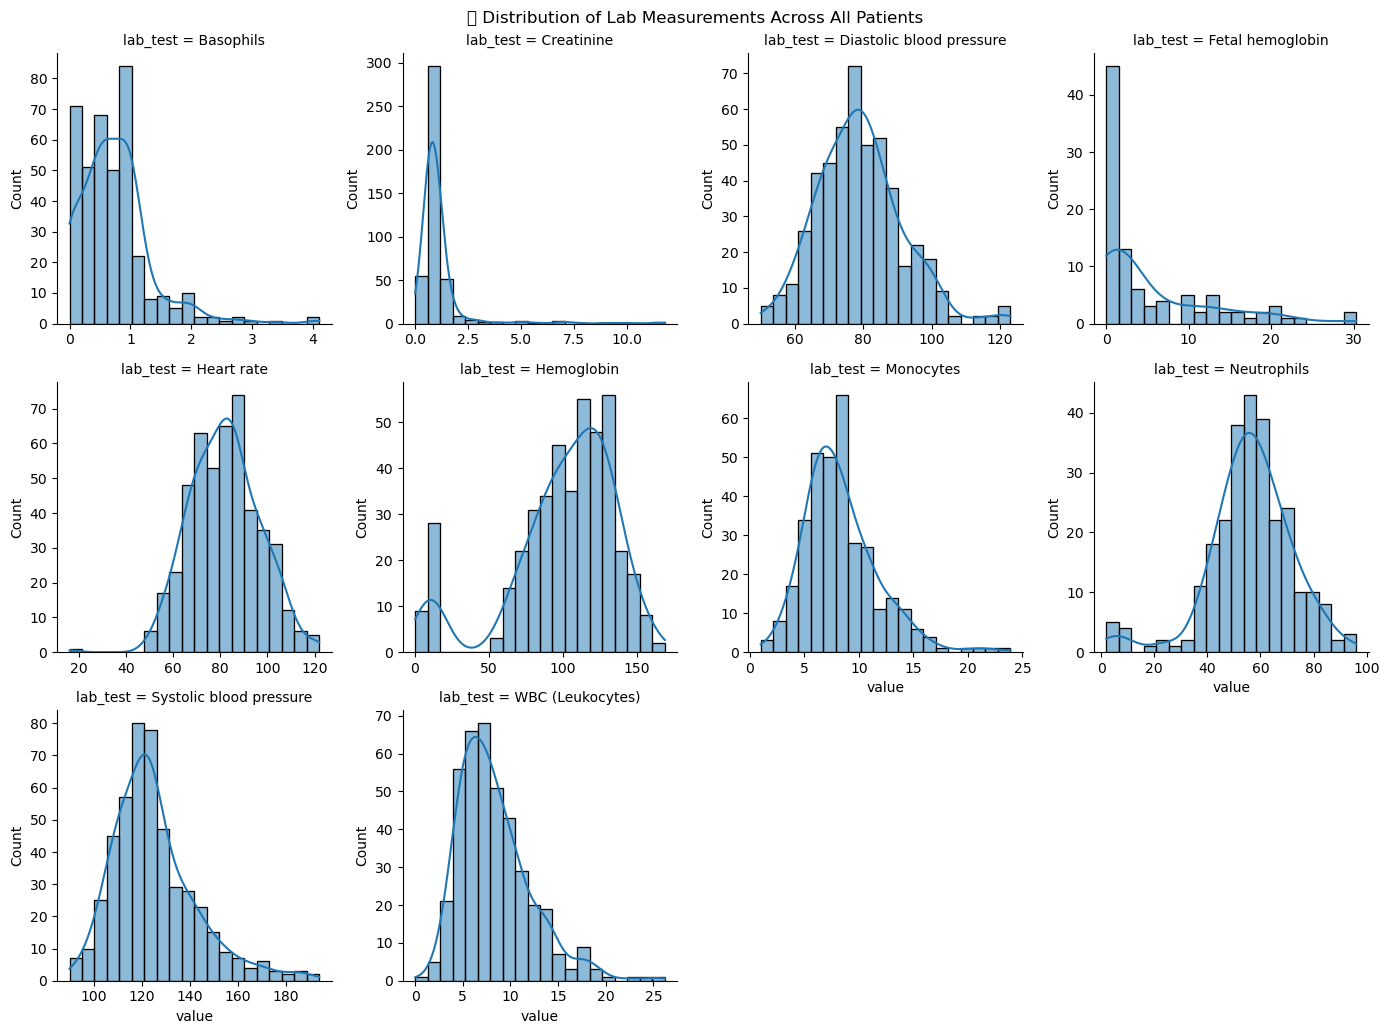

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
wide_df = pd.read_csv("SCD_Lab_Measurements_Wide.csv")

# Replace -999 with NaN
wide_df = wide_df.replace(-999.0, pd.NA)

# Melt to long format
melted_df = wide_df.melt(id_vars="person_id", var_name="lab_test", value_name="value")
melted_df["value"] = pd.to_numeric(melted_df["value"], errors="coerce")
melted_df = melted_df.dropna(subset=["value"])

# Plot faceted histograms
g = sns.FacetGrid(melted_df, col="lab_test", col_wrap=4, sharex=False, sharey=False, height=3.5)
g.map(sns.histplot, "value", bins=20, kde=True)

plt.subplots_adjust(top=0.92)
g.fig.suptitle("📊 Distribution of Lab Measurements Across All Patients")
plt.tight_layout()
g.savefig("All_Labs_Histograms_Faceted.png", dpi=300)

print("✅ Saved combined histogram chart as 'All_Labs_Histograms_Faceted.png'")

/tmp/ipykernel_293/105902378.py:43: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/envs/jupyter/lib/python3.10/site-packages/seaborn/axisgrid.py:100: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  self.figure.savefig(*args, **kwargs)


✅ Saved as 'All_Labs_Histograms_With_Counts.png'


/opt/conda/envs/jupyter/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/conda/envs/jupyter/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


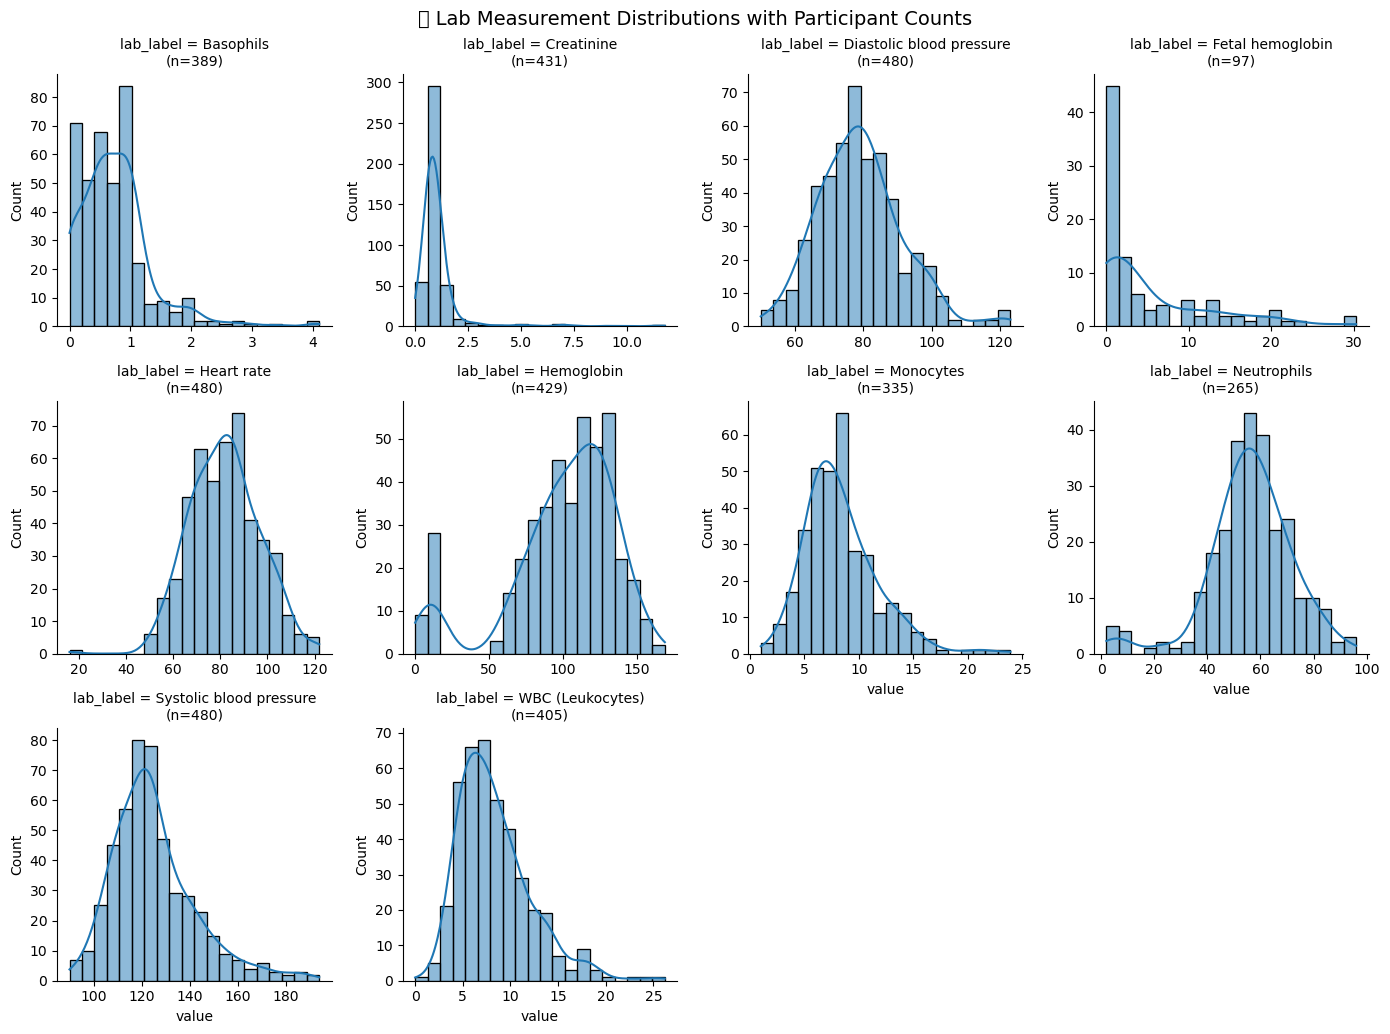

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your wide-format lab data
wide_df = pd.read_csv("SCD_Lab_Measurements_Wide.csv")

# Clean: Replace missing placeholders
wide_df = wide_df.replace(-999.0, pd.NA)

# Melt to long format for seaborn plotting
melted_df = wide_df.melt(id_vars="person_id", var_name="lab_test", value_name="value")
melted_df["value"] = pd.to_numeric(melted_df["value"], errors="coerce")
melted_df = melted_df.dropna(subset=["value"])

# Count participants per lab test
participant_counts = (
    melted_df.groupby("lab_test")["person_id"]
    .nunique()
    .rename("participant_count")
    .reset_index()
)

# Merge into plotting dataframe for titles
melted_df = melted_df.merge(participant_counts, on="lab_test", how="left")

# Create custom lab test label with participant count
melted_df["lab_label"] = melted_df["lab_test"] + "\n(n=" + melted_df["participant_count"].astype(str) + ")"

# Plot faceted histograms
g = sns.FacetGrid(
    melted_df,
    col="lab_label",
    col_wrap=4,
    sharex=False,
    sharey=False,
    height=3.5
)
g.map(sns.histplot, "value", bins=20, kde=True)

plt.subplots_adjust(top=0.90)
g.fig.suptitle("📊 Lab Measurement Distributions with Participant Counts", fontsize=14)
plt.tight_layout()
g.savefig("All_Labs_Histograms_With_Counts.png", dpi=300)

print("✅ Saved as 'All_Labs_Histograms_With_Counts.png'")

In [103]:
import pandas as pd

# Step 1: Load data
comp_df = pd.read_csv("SCD_Top10_Complication_Severity.csv")  # contains person_id, top10_complication_count
lab_df = pd.read_csv("SCD_Lab_Measurements_Wide.csv")  # wide-format lab data per person

# Step 2: Get overall median of complication counts
overall_median = comp_df["top10_complication_count"].median()
print(f"📊 Overall median complication count: {overall_median}")

# Step 3: Get patients with complication count equal to median
median_patients_df = comp_df[comp_df["top10_complication_count"] == overall_median]

# Step 4: Merge with lab measurements
merged_df = pd.merge(median_patients_df, lab_df, on="person_id", how="inner")

# Step 5: Save result
merged_df.to_csv("Median_Complication_Lab_Profiles.csv", index=False)
print("✅ Saved file: Median_Complication_Lab_Profiles.csv")

# Optional: show sample
print(merged_df.head())

📊 Overall median complication count: 0.0
✅ Saved file: Median_Complication_Lab_Profiles.csv
               date_of_birth  ethnicity        t_disp_ethnicity  \
0  1989-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
1  1987-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
2  1993-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
3  1997-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   
4  1993-06-15 00:00:00+00:00   38003564  Not Hispanic or Latino   

   ethnicity_concept_id    gender t_disp_gender  gender_concept_id  person_id  \
0              38003564  45880669           Man           45880669    2613841   
1              38003564  45880669           Man           45880669    1473001   
2              38003564  45880669           Man           45880669    2856227   
3              38003564  45880669           Man           45880669    2405915   
4              38003564  45880669           Man           45880669    3084665   

   race           

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the dataset (make sure this CSV is in the same directory)
df = pd.read_csv("Median_Complication_Lab_Profiles.csv")

# Optional: make sure person_id and top10_complication_count exist
excluded_columns = ['person_id', 'top10_complication_count']
lab_columns = [col for col in df.columns if col not in excluded_columns]

# Create a folder to store the plots
output_dir = "median_lab_histograms"
os.makedirs(output_dir, exist_ok=True)

# Generate one histogram per lab test
for lab in lab_columns:
    plt.figure(figsize=(8, 4))
    df[lab].dropna().hist(bins=20)
    plt.title(f"Distribution of {lab} (Median Complication Group)")
    plt.xlabel(lab)
    plt.ylabel("Number of Participants")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/Histogram_{lab.replace(' ', '_')}.png")
    plt.close()

print(f"✅ Saved {len(lab_columns)} histograms to folder: '{output_dir}'")

✅ Saved 39 histograms to folder: 'median_lab_histograms'


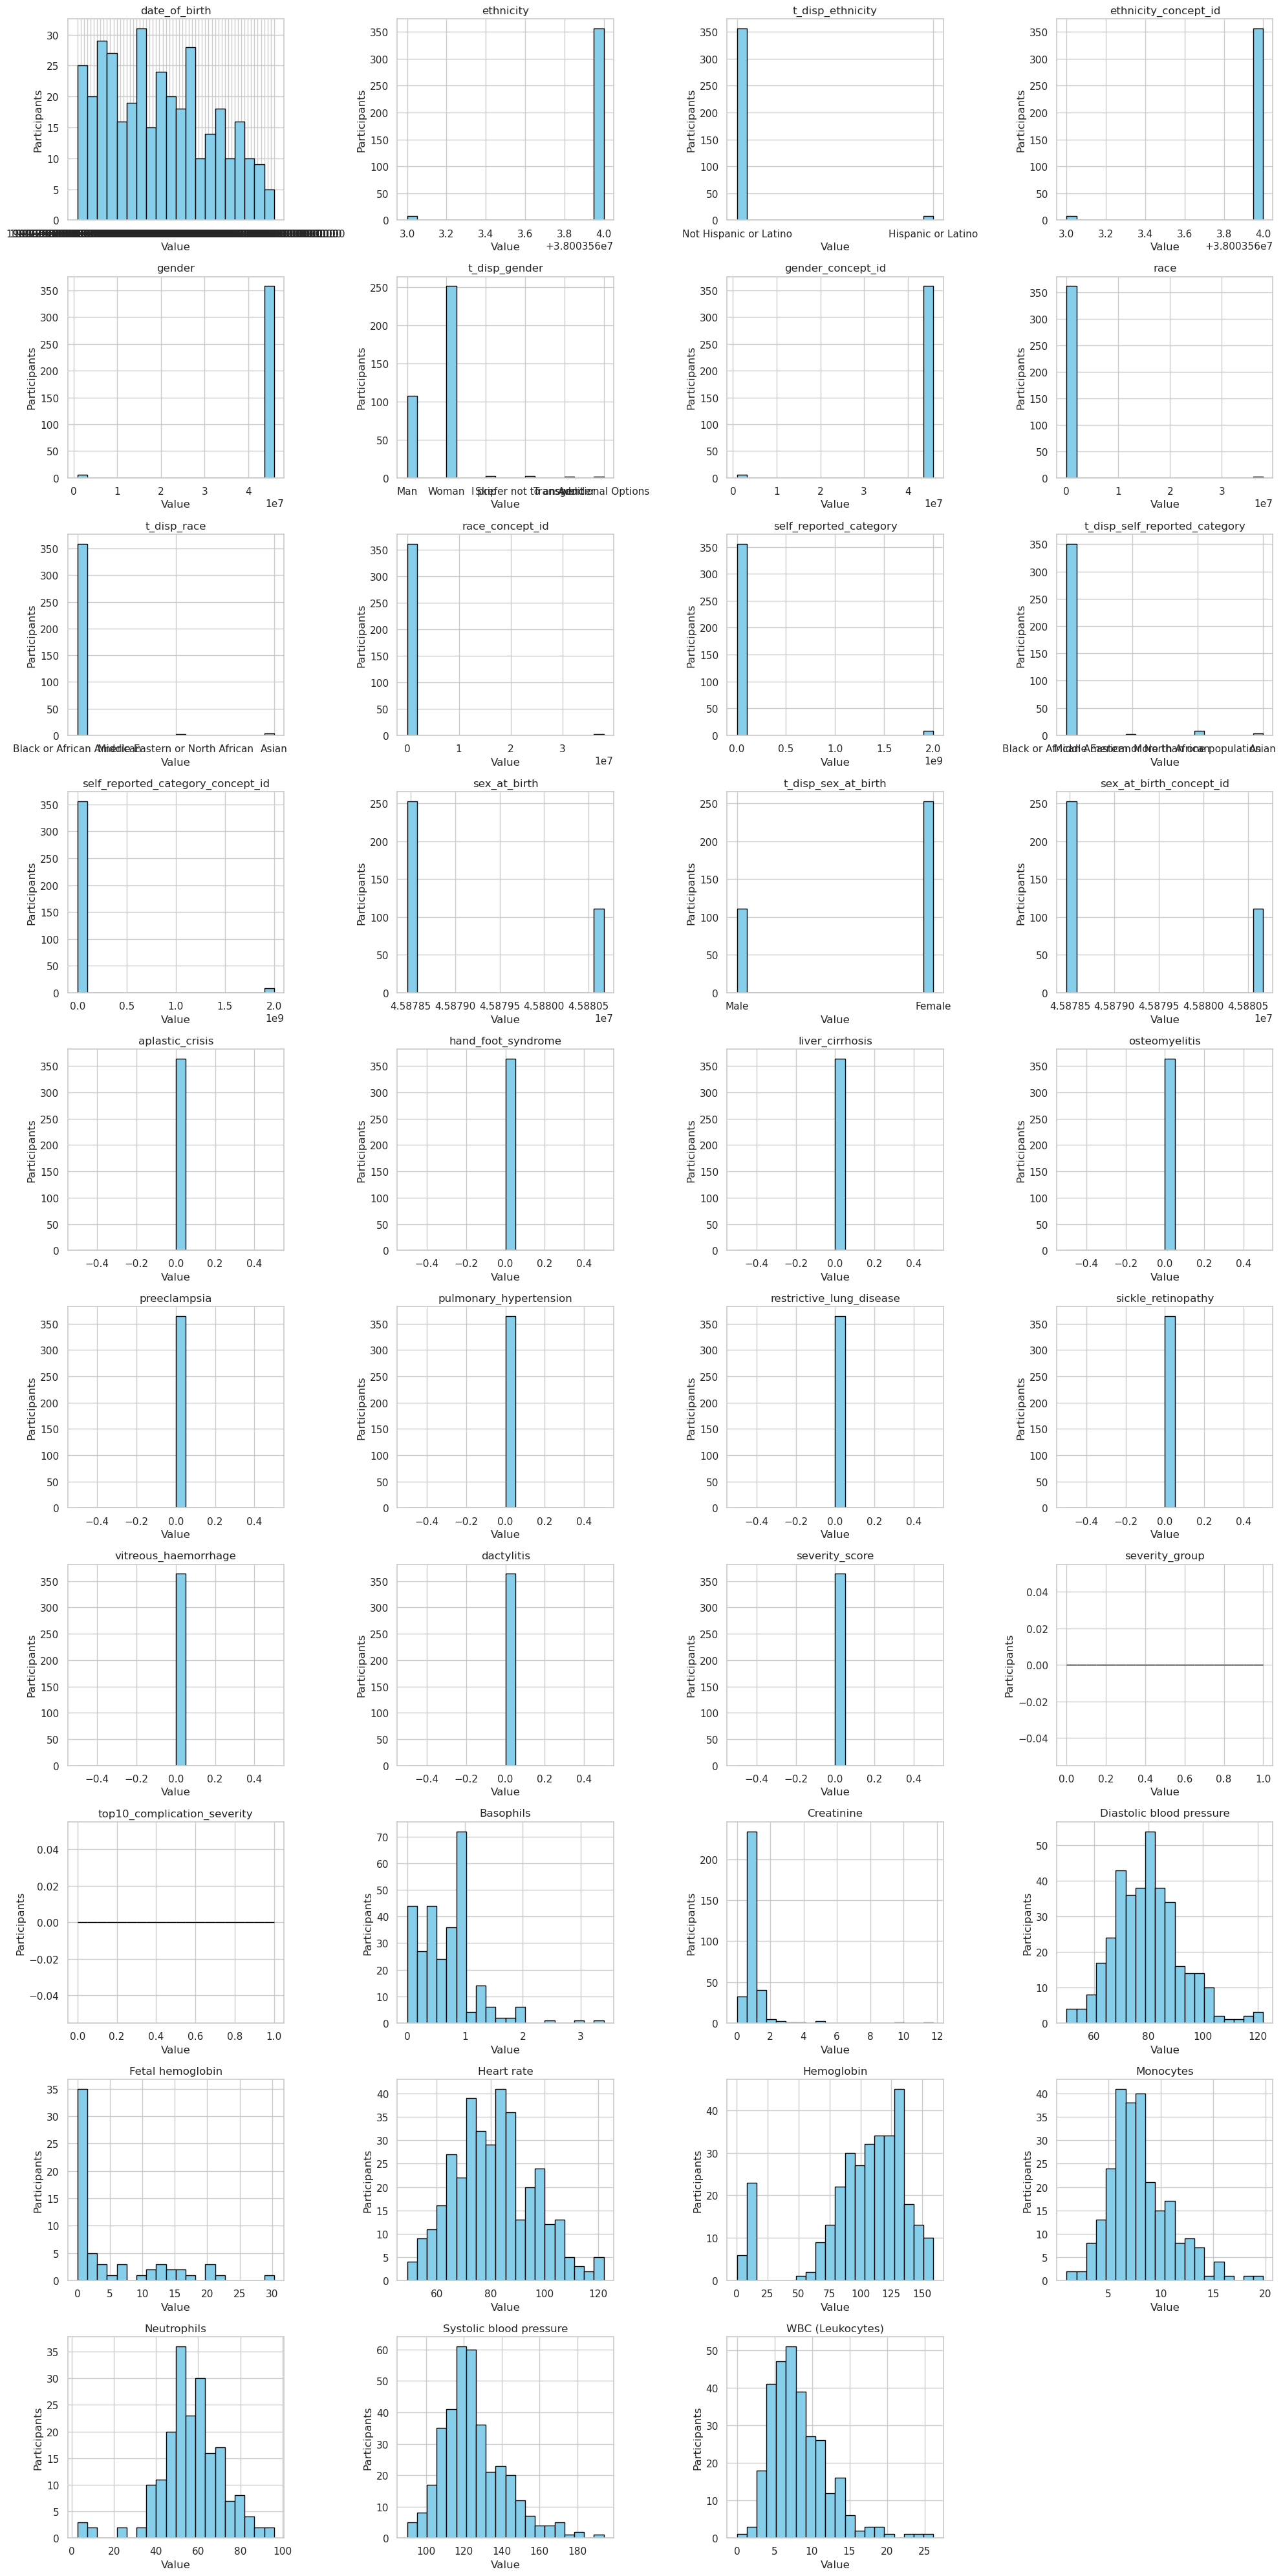

✅ Saved: Combined_Lab_Histograms.png


In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the data
df = pd.read_csv("Median_Complication_Lab_Profiles.csv")

# Step 2: Identify lab columns (exclude IDs or counts)
exclude_cols = ['person_id', 'top10_complication_count']
lab_columns = [col for col in df.columns if col not in exclude_cols]

# Step 3: Clean values (-999 = missing)
df_cleaned = df.replace(-999, pd.NA)

# Step 4: Create combined figure
n_labs = len(lab_columns)
n_cols = 4
n_rows = (n_labs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, lab in enumerate(lab_columns):
    axes[i].hist(df_cleaned[lab].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(lab)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Participants")

# Hide empty plots if any
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("Combined_Lab_Histograms.png")
plt.show()

print("✅ Saved: Combined_Lab_Histograms.png")

In [ ]:
define lab severity 

/tmp/ipykernel_326/1317385297.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, order=df[column].value_counts().index, palette='Set2')


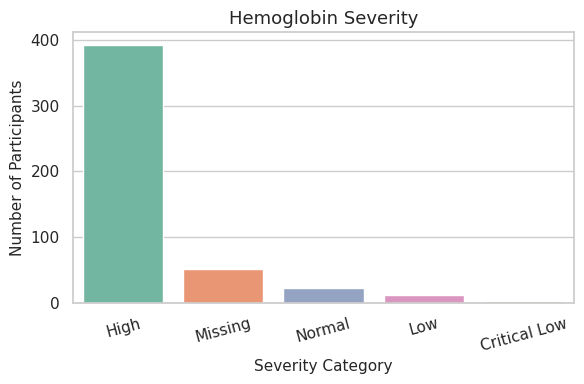

/tmp/ipykernel_326/1317385297.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, order=df[column].value_counts().index, palette='Set2')


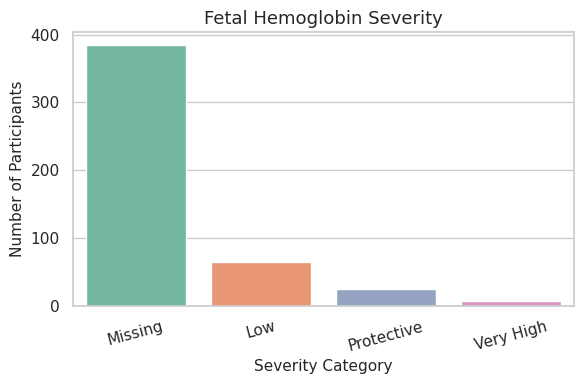

/tmp/ipykernel_326/1317385297.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, order=df[column].value_counts().index, palette='Set2')


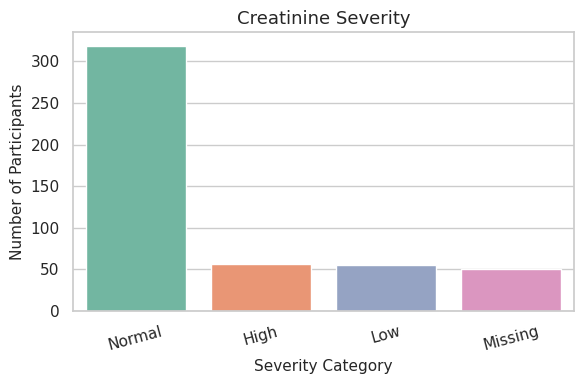

/tmp/ipykernel_326/1317385297.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, order=df[column].value_counts().index, palette='Set2')


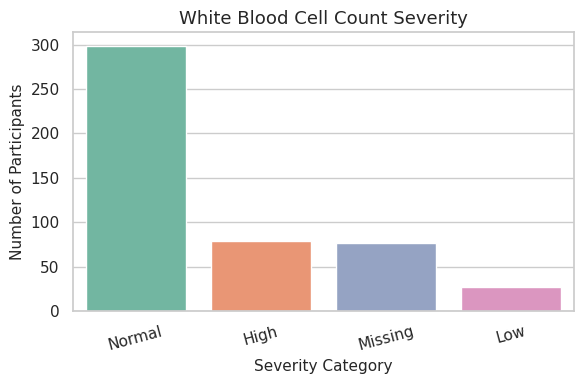

/tmp/ipykernel_326/1317385297.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, order=df[column].value_counts().index, palette='Set2')


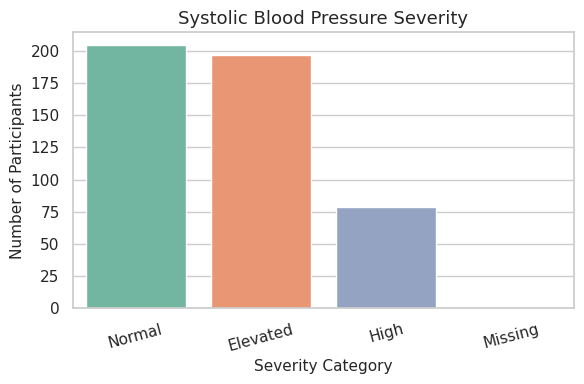

/tmp/ipykernel_326/1317385297.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, order=df[column].value_counts().index, palette='Set2')


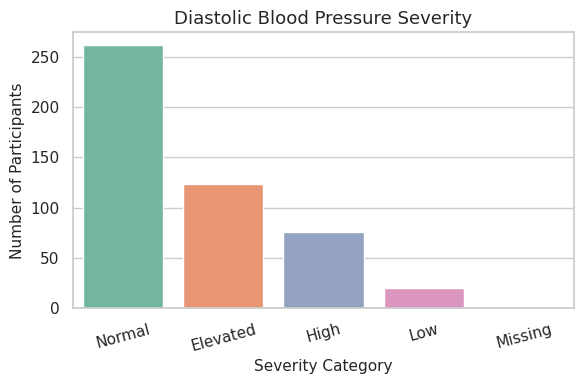

/tmp/ipykernel_326/1317385297.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, order=df[column].value_counts().index, palette='Set2')


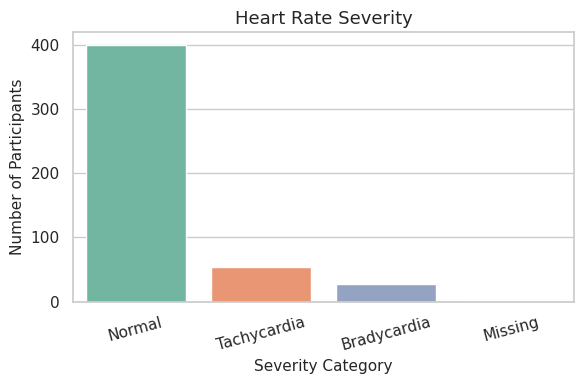

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("SCD_Lab_Measurements_Wide.csv")

# --- Define severity classification functions ---

def classify_hemoglobin(v):
    if pd.isna(v): return 'Missing'
    elif v < 7: return 'Critical Low'
    elif v < 11: return 'Low'
    elif v <= 15.5: return 'Normal'
    else: return 'High'

def classify_fetal_hb(v):
    if pd.isna(v): return 'Missing'
    elif v < 5: return 'Low'
    elif v <= 20: return 'Protective'
    else: return 'Very High'

def classify_creatinine(v):
    if pd.isna(v): return 'Missing'
    elif v < 0.6: return 'Low'
    elif v <= 1.3: return 'Normal'
    else: return 'High'

def classify_wbc(v):
    if pd.isna(v): return 'Missing'
    elif v < 4: return 'Low'
    elif v <= 11: return 'Normal'
    else: return 'High'

def classify_bp_sys(v):
    if pd.isna(v): return 'Missing'
    elif v < 90: return 'Low'
    elif v <= 120: return 'Normal'
    elif v <= 140: return 'Elevated'
    else: return 'High'

def classify_bp_dia(v):
    if pd.isna(v): return 'Missing'
    elif v < 60: return 'Low'
    elif v <= 80: return 'Normal'
    elif v <= 90: return 'Elevated'
    else: return 'High'

def classify_hr(v):
    if pd.isna(v): return 'Missing'
    elif v < 60: return 'Bradycardia'
    elif v <= 100: return 'Normal'
    else: return 'Tachycardia'

# --- Apply classification to available columns ---

df['Hemoglobin_Severity'] = df['Hemoglobin'].apply(classify_hemoglobin)
df['FetalHb_Severity'] = df['Fetal hemoglobin'].apply(classify_fetal_hb)
df['Creatinine_Severity'] = df['Creatinine'].apply(classify_creatinine)
df['WBC_Severity'] = df['WBC (Leukocytes)'].apply(classify_wbc)
df['SBP_Severity'] = df['Systolic blood pressure'].apply(classify_bp_sys)
df['DBP_Severity'] = df['Diastolic blood pressure'].apply(classify_bp_dia)
df['HR_Severity'] = df['Heart rate'].apply(classify_hr)

# --- Plotting function ---

def plot_severity_distribution(column, title):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=column, order=df[column].value_counts().index, palette='Set2')
    plt.title(title, fontsize=13)
    plt.xlabel('Severity Category', fontsize=11)
    plt.ylabel('Number of Participants', fontsize=11)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# --- Plot only available severity columns ---

plot_severity_distribution('Hemoglobin_Severity', 'Hemoglobin Severity')
plot_severity_distribution('FetalHb_Severity', 'Fetal Hemoglobin Severity')
plot_severity_distribution('Creatinine_Severity', 'Creatinine Severity')
plot_severity_distribution('WBC_Severity', 'White Blood Cell Count Severity')
plot_severity_distribution('SBP_Severity', 'Systolic Blood Pressure Severity')
plot_severity_distribution('DBP_Severity', 'Diastolic Blood Pressure Severity')
plot_severity_distribution('HR_Severity', 'Heart Rate Severity')

/tmp/ipykernel_326/1608209365.py:98: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_numeric = df[severity_cols].applymap(lambda x: severity_score_map.get(x, 0))
/tmp/ipykernel_326/1608209365.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Lab_Composite_Severity_Score', palette='magma')


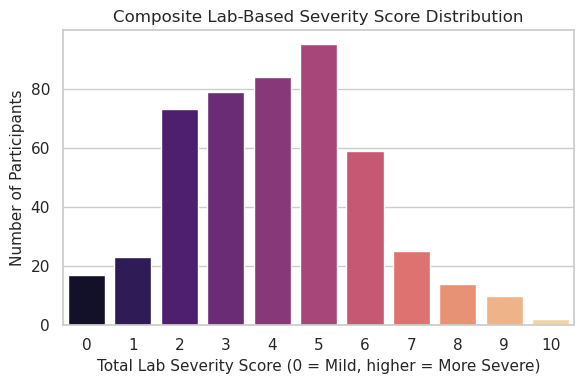

/tmp/ipykernel_326/1608209365.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Lab_Severity_Category', palette='coolwarm', order=['Mild', 'Moderate', 'Severe'])


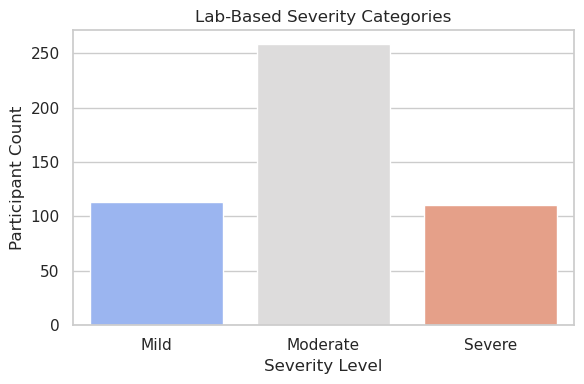

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------
# STEP 1: Load the dataset
# -----------------------------------------------
df = pd.read_csv("SCD_Lab_Measurements_Wide.csv")

# -----------------------------------------------
# STEP 2: Define severity classification functions
# -----------------------------------------------
def classify_hemoglobin(v):
    if pd.isna(v): return 'Missing'
    elif v < 7: return 'Critical Low'
    elif v < 11: return 'Low'
    elif v <= 15.5: return 'Normal'
    else: return 'High'

def classify_fetal_hb(v):
    if pd.isna(v): return 'Missing'
    elif v < 5: return 'Low'
    elif v <= 20: return 'Protective'
    else: return 'Very High'

def classify_creatinine(v):
    if pd.isna(v): return 'Missing'
    elif v < 0.6: return 'Low'
    elif v <= 1.3: return 'Normal'
    else: return 'High'

def classify_wbc(v):
    if pd.isna(v): return 'Missing'
    elif v < 4: return 'Low'
    elif v <= 11: return 'Normal'
    else: return 'High'

def classify_bp_sys(v):
    if pd.isna(v): return 'Missing'
    elif v < 90: return 'Low'
    elif v <= 120: return 'Normal'
    elif v <= 140: return 'Elevated'
    else: return 'High'

def classify_bp_dia(v):
    if pd.isna(v): return 'Missing'
    elif v < 60: return 'Low'
    elif v <= 80: return 'Normal'
    elif v <= 90: return 'Elevated'
    else: return 'High'

def classify_hr(v):
    if pd.isna(v): return 'Missing'
    elif v < 60: return 'Bradycardia'
    elif v <= 100: return 'Normal'
    else: return 'Tachycardia'

# -----------------------------------------------
# STEP 3: Create new _Severity columns
# -----------------------------------------------
df['Hemoglobin_Severity'] = df['Hemoglobin'].apply(classify_hemoglobin)
df['FetalHb_Severity'] = df['Fetal hemoglobin'].apply(classify_fetal_hb)
df['Creatinine_Severity'] = df['Creatinine'].apply(classify_creatinine)
df['WBC_Severity'] = df['WBC (Leukocytes)'].apply(classify_wbc)
df['SBP_Severity'] = df['Systolic blood pressure'].apply(classify_bp_sys)
df['DBP_Severity'] = df['Diastolic blood pressure'].apply(classify_bp_dia)
df['HR_Severity'] = df['Heart rate'].apply(classify_hr)

# -----------------------------------------------
# STEP 4: Severity-to-score mapping
# -----------------------------------------------
severity_score_map = {
    'Critical Low': 3,
    'Very High': 2,
    'High': 2,
    'Elevated': 1,
    'Low': 1,
    'Bradycardia': 1,
    'Tachycardia': 1,
    'Protective': 0,
    'Normal': 0,
    'Missing': 0
}

severity_cols = [
    'Hemoglobin_Severity',
    'FetalHb_Severity',
    'Creatinine_Severity',
    'WBC_Severity',
    'SBP_Severity',
    'DBP_Severity',
    'HR_Severity'
]

# -----------------------------------------------
# STEP 5: Convert severity labels to numeric scores
# -----------------------------------------------
df_numeric = df[severity_cols].applymap(lambda x: severity_score_map.get(x, 0))

# -----------------------------------------------
# STEP 6: Calculate total composite severity score
# -----------------------------------------------
df['Lab_Composite_Severity_Score'] = df_numeric.sum(axis=1)

# -----------------------------------------------
# STEP 7: Plot the score distribution
# -----------------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Lab_Composite_Severity_Score', palette='magma')
plt.title('Composite Lab-Based Severity Score Distribution')
plt.xlabel('Total Lab Severity Score (0 = Mild, higher = More Severe)', fontsize=11)
plt.ylabel('Number of Participants', fontsize=11)
plt.tight_layout()
plt.show()

# -----------------------------------------------
# OPTIONAL: Categorize into Mild / Moderate / Severe
# -----------------------------------------------
def categorize_total_score(score):
    if score <= 2:
        return 'Mild'
    elif score <= 5:
        return 'Moderate'
    else:
        return 'Severe'

df['Lab_Severity_Category'] = df['Lab_Composite_Severity_Score'].apply(categorize_total_score)

# Plot severity category
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Lab_Severity_Category', palette='coolwarm', order=['Mild', 'Moderate', 'Severe'])
plt.title('Lab-Based Severity Categories')
plt.xlabel('Severity Level')
plt.ylabel('Participant Count')
plt.tight_layout()
plt.show()

In [114]:
from google.cloud import bigquery

client = bigquery.Client()

query = f"""
SELECT COUNT(*) AS n
FROM `{os.environ['WORKSPACE_CDR']}.person`
"""

client.query(query).to_dataframe()

,n
0,633547


In [118]:
import os
workspace_cdr = os.environ["WORKSPACE_CDR"]

In [120]:
import pandas as pd
from google.cloud import bigquery
import os

client = bigquery.Client()

# Use the REAL CDR for your workspace
workspace_cdr = os.environ["WORKSPACE_CDR"]

lab_concepts = [
    40795725, 3018738, 37045413, 40789184, 40782735,
    40789179, 3000905, 303751, 3013869, 3010451,
    3011948, 3008342, 37060058, 37073425, 3004249,
    3012888, 3027018, 40775801
]

# Load SCD cohort demographics to get person_ids
scd_demo = pd.read_csv("SCD_Demographics.csv")
scd_ids = scd_demo["person_id"].astype(int).tolist()

query = f"""
SELECT
  person_id,
  measurement_concept_id,
  MAX(measurement_date) AS most_recent_date,
  ANY_VALUE(value_as_number) AS value_at_most_recent_date,
  AVG(value_as_number) AS average_value
FROM `{workspace_cdr}.measurement`
WHERE
  person_id IN UNNEST(@person_ids)
  AND measurement_concept_id IN UNNEST(@lab_concepts)
  AND value_as_number IS NOT NULL
GROUP BY person_id, measurement_concept_id
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("person_ids", "INT64", scd_ids),
        bigquery.ArrayQueryParameter("lab_concepts", "INT64", lab_concepts)
    ]
)

measurement_summary = client.query(query, job_config=job_config).to_dataframe()

measurement_summary.head()


,person_id,measurement_concept_id,most_recent_date,value_at_most_recent_date,average_value
0,1721180,3013869,2023-05-11,0.6,0.509091
1,4274822,3013869,2023-03-18,1.0,0.391304
2,3134032,3027018,2022-05-20,70.0,78.025510
3,3887137,3027018,2023-05-15,90.0,91.904072
4,1659413,3004249,2023-08-22,122.0,122.884735


In [122]:
import pandas as pd
from google.cloud import bigquery
import os

# Initialize BigQuery client
client = bigquery.Client()

# Use the correct CDR for your workspace
workspace_cdr = os.environ["WORKSPACE_CDR"]

# Load your 476 SCD participant IDs
scd_demo = pd.read_csv("SCD_Demographics.csv")
scd_ids = scd_demo["person_id"].astype(int).tolist()

# List of lab measurement concept IDs
lab_concepts = [
    40795725, 3018738, 37045413, 40789184, 40782735,
    40789179, 3000905, 303751, 3013869, 3010451,
    3011948, 3008342, 37060058, 37073425, 3004249,
    3012888, 3027018, 40775801
]

# SQL query
query = f"""
WITH filtered AS (
  SELECT person_id, measurement_concept_id, measurement_date, value_as_number, unit_concept_id
  FROM `{workspace_cdr}.measurement`
  WHERE value_as_number IS NOT NULL
    AND person_id IN UNNEST(@person_ids)
    AND measurement_concept_id IN UNNEST(@lab_concepts)
),

ranked AS (
  SELECT *,
         RANK() OVER (PARTITION BY person_id, measurement_concept_id ORDER BY measurement_date DESC) AS rnk
  FROM filtered
),

most_recent AS (
  SELECT person_id, measurement_concept_id, measurement_date AS most_recent_date,
         value_as_number AS value_at_most_recent_date, unit_concept_id
  FROM ranked
  WHERE rnk = 1
),

average AS (
  SELECT person_id, measurement_concept_id, AVG(value_as_number) AS average_value
  FROM filtered
  GROUP BY person_id, measurement_concept_id
)

SELECT m.person_id, m.measurement_concept_id, m.most_recent_date,
       m.value_at_most_recent_date, a.average_value,
       c.concept_name AS lab_name, u.concept_name AS unit
FROM most_recent m
JOIN average a
  ON m.person_id = a.person_id AND m.measurement_concept_id = a.measurement_concept_id
LEFT JOIN `{workspace_cdr}.concept` c
  ON m.measurement_concept_id = c.concept_id
LEFT JOIN `{workspace_cdr}.concept` u
  ON m.unit_concept_id = u.concept_id
"""

# Set query parameters
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("person_ids", "INT64", scd_ids),
        bigquery.ArrayQueryParameter("lab_concepts", "INT64", lab_concepts)
    ]
)

# Run query
measurement_df = client.query(query, job_config=job_config).to_dataframe()

# Save long format CSV
measurement_df.to_csv("lab_measurements_long_with_units.csv", index=False)

# Save wide format CSV
wide_df = measurement_df.pivot_table(
    index="person_id",
    columns="lab_name",
    values="value_at_most_recent_date"
).reset_index()
wide_df.to_csv("lab_measurements_wide_with_units.csv", index=False)

print("Saved:")
print("- lab_measurements_long_with_units.csv")
print("- lab_measurements_wide_with_units.csv")

measurement_df.head(10)


Saved:
- lab_measurements_long_with_units.csv
- lab_measurements_wide_with_units.csv


,person_id,measurement_concept_id,most_recent_date,value_at_most_recent_date,average_value,lab_name,unit
0,1086068,3027018,2023-09-28,79.0,75.904762,Heart rate,per minute
1,1086068,3027018,2023-09-28,79.0,75.904762,Heart rate,per minute
2,1371988,3004249,2020-02-19,116.0,114.333333,Systolic blood pressure,millimeter mercury column
3,1371988,3004249,2020-02-19,114.0,114.333333,Systolic blood pressure,millimeter mercury column
4,1371988,3004249,2020-02-19,113.0,114.333333,Systolic blood pressure,millimeter mercury column
5,1395057,3004249,2021-05-20,102.0,100.666667,Systolic blood pressure,millimeter mercury column
6,1395057,3004249,2021-05-20,100.0,100.666667,Systolic blood pressure,millimeter mercury column
7,1395057,3004249,2021-05-20,100.0,100.666667,Systolic blood pressure,millimeter mercury column
8,1397576,3012888,2020-07-30,61.0,63.543419,Diastolic blood pressure,millimeter mercury column
9,1589343,3027018,2023-08-22,92.0,88.178082,Heart rate,per minute


In [124]:
import pandas as pd

# Load wide-format lab data
df = pd.read_csv("lab_measurements_wide_with_units.csv")

# Drop person_id (it's not a lab test)
lab_only = df.drop(columns=["person_id"], errors='ignore')

# Calculate median for each lab column
lab_medians = lab_only.median(numeric_only=True).sort_values(ascending=False).reset_index()
lab_medians.columns = ["Lab Test", "Median Value"]

# Show top rows
print("✅ Median lab values across 476 SCD participants:")
print(lab_medians)

# Optionally save to CSV
lab_medians.to_csv("lab_measurement_medians.csv", index=False)

✅ Median lab values across 476 SCD participants:
                                            Lab Test  Median Value
0                            Systolic blood pressure        123.00
1                                         Heart rate         79.00
2                           Diastolic blood pressure         76.00
3  Neutrophils/100 leukocytes in Blood by Automat...         56.55
4  Monocytes/100 leukocytes in Blood by Automated...          7.90
5  Leukocytes [#/volume] in Blood by Automated count          7.60
6             Hemoglobin F/Hemoglobin.total in Blood          1.75
7  Basophils/100 leukocytes in Blood by Automated...          0.70


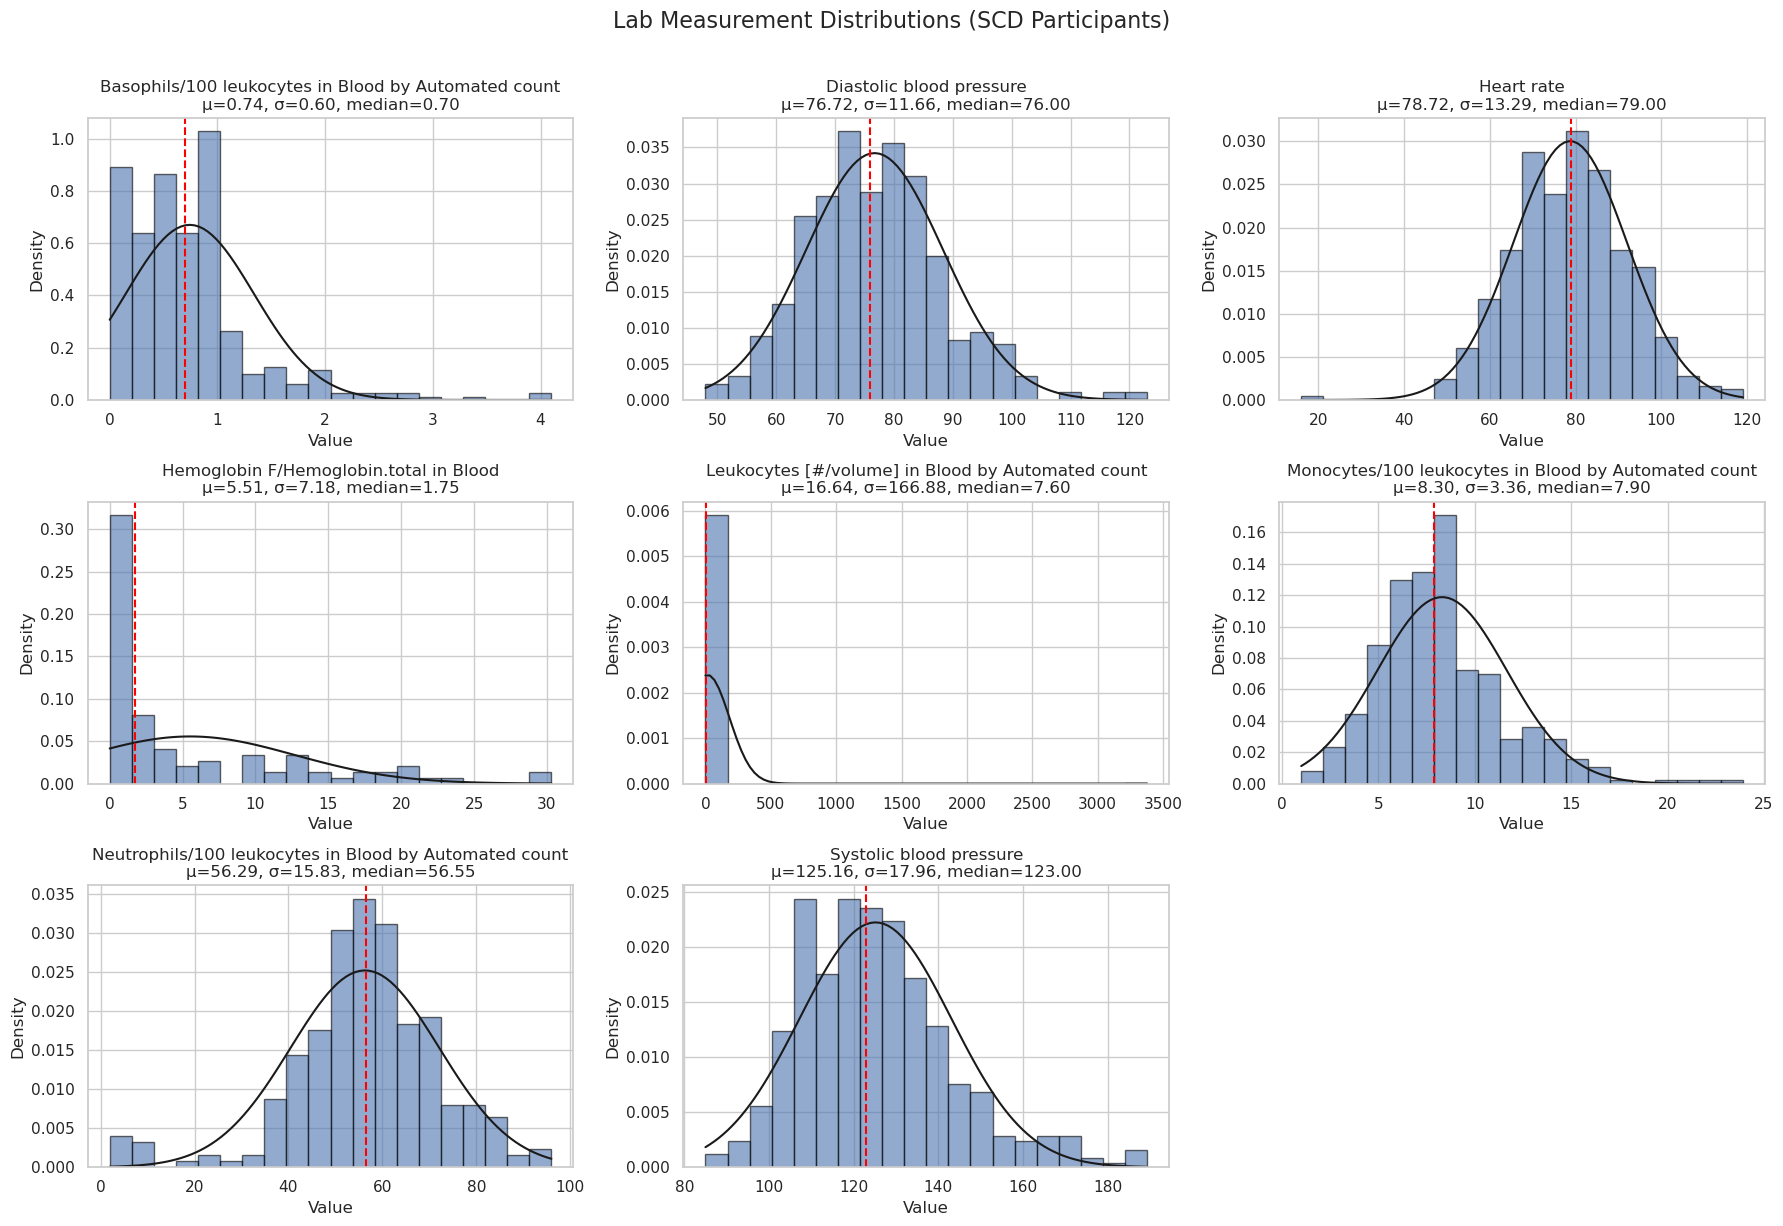

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load lab data
df = pd.read_csv("lab_measurements_wide_with_units.csv")

# Define lab tests to include (or use all columns except person_id)
lab_tests = [col for col in df.columns if col != "person_id"]

# Set up the grid size for subplots
n = len(lab_tests)
cols = 3
rows = (n + cols - 1) // cols

# Create figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

# Loop through each lab test
for i, lab in enumerate(lab_tests):
    ax = axes[i]
    values = df[lab].dropna()

    if len(values) < 10:
        ax.set_title(f"{lab} (Insufficient data)")
        ax.axis('off')
        continue

    median_val = np.median(values)
    mu, std = norm.fit(values)

    # Histogram
    ax.hist(values, bins=20, density=True, alpha=0.6, edgecolor='black')
    x = np.linspace(values.min(), values.max(), 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'k', linewidth=1.5)

    ax.axvline(median_val, color='red', linestyle='--')
    ax.set_title(f"{lab}\nμ={mu:.2f}, σ={std:.2f}, median={median_val:.2f}")
    ax.set_ylabel("Density")
    ax.set_xlabel("Value")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle("Lab Measurement Distributions (SCD Participants)", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.93)
plt.savefig("combined_lab_distributions.png", dpi=300)
plt.show()

In [ ]:
p value and labs for each 

In [ ]:
something else 

In [95]:
import pandas as pd

# Load severity group file
df = pd.read_csv("SCD_Complication_Severity_Categorised.csv", dtype={"person_id": str})

# Get 'None' person_ids
none_ids = df[df['severity_group'] == 'None']['person_id'].astype(str)

# Load lab file
lab_df = pd.read_csv("SCD_Lab_Measurements_Long.csv", dtype={"person_id": str})

# Filter to 'None' participants
lab_none = lab_df[lab_df['person_id'].isin(none_ids)]

print(f"✅ Found {lab_none.shape[0]} lab records for {lab_none['person_id'].nunique()} 'None' participants.")

✅ Found 0 lab records for 0 'None' participants.


In [99]:
import pandas as pd

# Load your condition occurrence file
cond = pd.read_csv("your_condition_occurrence_data.csv")  # Has person_id and condition_concept_id

# Define complications and their concept IDs
complication_map = {
    "dactylitis": 319835,
    "restrictive_lung_disease": 319843,
    "preeclampsia": 3004295,
    "sickle_retinopathy": 316211,
    "osteomyelitis": 201612,
    "aplastic_crisis": 432961,
    "liver_cirrhosis": 194984,
    "vitreous_haemorrhage": 4226463,
    "hand_foot_syndrome": 320128,
    "pulmonary_hypertension": 316866
}

# Get all unique participants
all_people = cond["person_id"].unique()
result_df = pd.DataFrame(all_people, columns=["person_id"])

# Check each complication
for label, cid in complication_map.items():
    # Flag those with the complication
    affected = cond[cond["condition_concept_id"] == cid]["person_id"].unique()
    result_df[label] = result_df["person_id"].isin(affected).map({True: "Yes", False: "No"})

# Preview
print(result_df.head())

   person_id dactylitis restrictive_lung_disease preeclampsia  \
0    3887137         No                       No           No   
1    1549266         No                       No           No   
2    8794382         No                       No           No   
3    3295915         No                       No           No   
4    2249934         No                       No           No   

  sickle_retinopathy osteomyelitis aplastic_crisis liver_cirrhosis  \
0                 No            No              No              No   
1                 No            No              No              No   
2                 No            No              No              No   
3                 No            No              No              No   
4                 No            No              No              No   

  vitreous_haemorrhage hand_foot_syndrome pulmonary_hypertension  
0                   No                 No                     No  
1                   No                 No             

In [147]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Load datasets
comp_df = pd.read_csv("SCD_Complication_Severity_Assessed.csv")
lab_df = pd.read_csv("lab_measurements_wide_with_units.csv")

# Convert binary complications to 'Yes'/'No'
comp_columns = [col for col in comp_df.columns if col not in ['person_id', 'severity_score', 'severity_group']]
comp_df[comp_columns] = comp_df[comp_columns].replace({1: 'Yes', 0: 'No'})

# Merge complication and lab data
merged_df = pd.merge(comp_df, lab_df, on="person_id", how="inner")

# Prepare results list
results = []

# Loop over each complication and each lab
lab_columns = [col for col in lab_df.columns if col != "person_id"]

for complication in comp_columns:
    for lab in lab_columns:
        temp = merged_df[[complication, lab, "severity_score"]].dropna()
        if temp[complication].nunique() != 2:
            continue

        group_yes = temp[temp[complication] == "Yes"][lab]
        group_no = temp[temp[complication] == "No"][lab]

        if len(group_yes) < 5 or len(group_no) < 5:
            continue

        # Mann-Whitney U test (non-parametric)
        stat, p = mannwhitneyu(group_yes, group_no, alternative='two-sided')

        # Severity comparison
        sev_yes = temp[temp[complication] == "Yes"]["severity_score"].median()
        sev_no = temp[temp[complication] == "No"]["severity_score"].median()

        results.append({
            "Complication": complication,
            "Lab Test": lab,
            "Median (Yes)": np.median(group_yes),
            "Median (No)": np.median(group_no),
            "Severity (Yes)": sev_yes,
            "Severity (No)": sev_no,
            "p-value": p
        })

# Create and sort results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="p-value")

# Save to CSV
results_df.to_csv("complication_lab_severity_stats.csv", index=False)

# Show top results
print("✅ Top complication-lab associations with severity and p-values:")
print(results_df.head(10))

✅ Top complication-lab associations with severity and p-values:
              Complication                                           Lab Test  \
34  pulmonary_hypertension  Monocytes/100 leukocytes in Blood by Automated...   
16           osteomyelitis                                         Heart rate   
29  pulmonary_hypertension  Basophils/100 leukocytes in Blood by Automated...   
30  pulmonary_hypertension                           Diastolic blood pressure   
4          aplastic_crisis  Monocytes/100 leukocytes in Blood by Automated...   
32  pulmonary_hypertension             Hemoglobin F/Hemoglobin.total in Blood   
14           osteomyelitis  Basophils/100 leukocytes in Blood by Automated...   
39    vitreous_haemorrhage                                         Heart rate   
21           osteomyelitis                            Systolic blood pressure   
1          aplastic_crisis                           Diastolic blood pressure   

    Median (Yes)  Median (No)  Severity (Yes

In [148]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# === Load your files ===
comp_df = pd.read_csv("SCD_Complication_Severity_Assessed.csv")   # Must contain person_id, binary complications, severity_score
lab_df = pd.read_csv("lab_measurements_wide_with_units.csv")      # Must contain person_id and recent lab parameters

# === Keep only your 476 participants ===
scd_demo = pd.read_csv("SCD_Demographics.csv")
scd_ids = scd_demo["person_id"].unique()

comp_df = comp_df[comp_df["person_id"].isin(scd_ids)]
lab_df = lab_df[lab_df["person_id"].isin(scd_ids)]

# === Convert 0/1 to Yes/No for all complications ===
comp_columns = [col for col in comp_df.columns if col not in ["person_id", "severity_score", "severity_group"]]
comp_df[comp_columns] = comp_df[comp_columns].replace({1: "Yes", 0: "No"})

# === Merge lab and complication data ===
merged_df = pd.merge(comp_df, lab_df, on="person_id", how="inner")

# === Prepare output ===
results = []
lab_columns = [col for col in lab_df.columns if col != "person_id"]

# === Loop through each complication and lab test ===
for complication in comp_columns:
    for lab in lab_columns:
        temp = merged_df[[complication, lab, "severity_score"]].dropna()

        if temp[complication].nunique() != 2:
            continue  # must have both Yes and No

        group_yes = temp[temp[complication] == "Yes"][lab]
        group_no = temp[temp[complication] == "No"][lab]

        if len(group_yes) < 5 or len(group_no) < 5:
            continue  # too few values

        # Mann-Whitney U Test
        stat, p = mannwhitneyu(group_yes, group_no, alternative='two-sided')

        # Severity score medians
        sev_yes = temp[temp[complication] == "Yes"]["severity_score"].median()
        sev_no = temp[temp[complication] == "No"]["severity_score"].median()

        results.append({
            "Complication": complication,
            "Lab Test": lab,
            "Median (Yes)": np.median(group_yes),
            "Median (No)": np.median(group_no),
            "Severity (Yes)": sev_yes,
            "Severity (No)": sev_no,
            "p-value": p
        })

# === Format output ===
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("p-value")
results_df.to_csv("SCD_Complication_Lab_Severity_Stats.csv", index=False)

# === Show summary ===
print("✅ Analysis complete for 481 participants.")
print(results_df.head(10))

✅ Analysis complete for 481 participants.
              Complication                                           Lab Test  \
34  pulmonary_hypertension  Monocytes/100 leukocytes in Blood by Automated...   
16           osteomyelitis                                         Heart rate   
29  pulmonary_hypertension  Basophils/100 leukocytes in Blood by Automated...   
30  pulmonary_hypertension                           Diastolic blood pressure   
4          aplastic_crisis  Monocytes/100 leukocytes in Blood by Automated...   
32  pulmonary_hypertension             Hemoglobin F/Hemoglobin.total in Blood   
14           osteomyelitis  Basophils/100 leukocytes in Blood by Automated...   
39    vitreous_haemorrhage                                         Heart rate   
21           osteomyelitis                            Systolic blood pressure   
1          aplastic_crisis                           Diastolic blood pressure   

    Median (Yes)  Median (No)  Severity (Yes)  Severity (No)   p-v

In [149]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Step 1: Load data
labs = pd.read_csv("lab_measurements_wide_with_units.csv")
complications = pd.read_csv("SCD_Complication_Severity_Assessed.csv")

# Step 2: Merge both datasets on person_id
merged = pd.merge(complications, labs, on="person_id", how="inner")

# Step 3: Extract lab measurement column names
lab_columns = labs.columns.drop("person_id")

# Step 4: Extract complication flags (excluding person_id and severity_score)
complication_columns = [col for col in complications.columns if col not in ["person_id", "severity_score"]]

# Step 5: Prepare result storage
results = []

for comp in complication_columns:
    # Check unique values
    unique_vals = merged[comp].dropna().unique()
    if set(unique_vals) != {0, 1}:
        continue  # skip non-binary complication columns

    for lab in lab_columns:
        group_yes = merged[merged[comp] == 1][lab].dropna()
        group_no = merged[merged[comp] == 0][lab].dropna()

        if len(group_yes) < 5 or len(group_no) < 5:
            continue  # skip if not enough data

        # Mann-Whitney U Test
        try:
            stat, pval = mannwhitneyu(group_yes, group_no, alternative='two-sided')
        except Exception as e:
            pval = np.nan

        # Severity comparison
        severity_yes = merged.loc[merged[comp] == 1, "severity_score"].median()
        severity_no = merged.loc[merged[comp] == 0, "severity_score"].median()

        results.append({
            "Complication": comp,
            "Lab Test": lab,
            "Median (Yes)": group_yes.median(),
            "Median (No)": group_no.median(),
            "Severity (Yes)": severity_yes,
            "Severity (No)": severity_no,
            "p-value": pval
        })

# Step 6: Create final DataFrame
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by="p-value")

# Step 7: Save
result_df.to_csv("complication_lab_analysis.csv", index=False)

# Optional preview
print("✅ Analysis complete.")
print(result_df.head(10))

✅ Analysis complete.
              Complication                                           Lab Test  \
34  pulmonary_hypertension  Monocytes/100 leukocytes in Blood by Automated...   
16           osteomyelitis                                         Heart rate   
29  pulmonary_hypertension  Basophils/100 leukocytes in Blood by Automated...   
30  pulmonary_hypertension                           Diastolic blood pressure   
4          aplastic_crisis  Monocytes/100 leukocytes in Blood by Automated...   
32  pulmonary_hypertension             Hemoglobin F/Hemoglobin.total in Blood   
14           osteomyelitis  Basophils/100 leukocytes in Blood by Automated...   
39    vitreous_haemorrhage                                         Heart rate   
21           osteomyelitis                            Systolic blood pressure   
1          aplastic_crisis                           Diastolic blood pressure   

    Median (Yes)  Median (No)  Severity (Yes)  Severity (No)   p-value  
34      9.2500

In [150]:
import os
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Step 1: Load data
labs = pd.read_csv("lab_measurements_wide_with_units.csv")  # wide lab data for 476 participants
complications = pd.read_csv("SCD_Complication_Severity_Assessed.csv")  # includes 0/1 columns for each complication

# Step 2: Merge datasets
merged = pd.merge(complications, labs, on="person_id", how="inner")

# Step 3: Define complications and lab columns
complication_cols = [col for col in complications.columns if col != "person_id" and complications[col].isin([0, 1]).any()]
lab_columns = [col for col in labs.columns if col != "person_id"]

# Step 4: Output folder
output_dir = "complication_lab_stats"
os.makedirs(output_dir, exist_ok=True)

# Step 5: Run analysis for each complication
summary_all = []

for comp in complication_cols:
    group_yes = merged[merged[comp] == 1]
    group_no = merged[merged[comp] == 0]

    results = []

    for lab in lab_columns:
        values_yes = group_yes[lab].dropna()
        values_no = group_no[lab].dropna()

        if len(values_yes) < 5 or len(values_no) < 5:
            continue

        try:
            stat, pval = mannwhitneyu(values_yes, values_no, alternative='two-sided')
        except Exception:
            pval = np.nan

        results.append({
            "Complication": comp,
            "Lab Test": lab,
            "Median (Yes)": np.median(values_yes),
            "Median (No)": np.median(values_no),
            "p-value": pval,
            "N (Yes)": len(values_yes),
            "N (No)": len(values_no)
        })

    if results:
        df = pd.DataFrame(results).sort_values("p-value")
        df.to_csv(f"{output_dir}/{comp}_lab_comparison.csv", index=False)
        summary_all.extend(df.to_dict(orient="records"))

# Step 6: Combine all results
final_summary = pd.DataFrame(summary_all)

# Step 7: Format for display
final_summary['p-value'] = final_summary['p-value'].apply(lambda p: f"{p:.4f}" if pd.notnull(p) else "NA")

# Step 8: Save and show
final_summary.to_csv("combined_lab_complication_summary.csv", index=False)

# Optional: Show top results in table
print("✅ Summary of all complications and lab comparisons:")
display(final_summary.head(20))  # You can change to .head(50) or remove for full table

✅ Summary of all complications and lab comparisons:


,Complication,Lab Test,Median (Yes),Median (No),p-value,N (Yes),N (No)
0,aplastic_crisis,Monocytes/100 leukocytes in Blood by Automated...,10.700000,7.900000,0.0258,8,329
1,aplastic_crisis,Diastolic blood pressure,71.000000,76.000000,0.1576,9,471
2,aplastic_crisis,Systolic blood pressure,114.333333,123.000000,0.1678,9,471
3,aplastic_crisis,Basophils/100 leukocytes in Blood by Automated...,0.550000,0.700000,0.3312,8,381
4,aplastic_crisis,Neutrophils/100 leukocytes in Blood by Automat...,56.350000,56.550000,0.6968,8,258
5,aplastic_crisis,Heart rate,78.250000,79.000000,0.8281,9,471
6,aplastic_crisis,Leukocytes [#/volume] in Blood by Automated count,7.730000,7.600000,0.8543,8,399
7,liver_cirrhosis,Basophils/100 leukocytes in Blood by Automated...,0.800000,0.700000,0.1817,19,370
8,liver_cirrhosis,Heart rate,82.916667,78.666667,0.3072,20,460
9,liver_cirrhosis,Systolic blood pressure,124.690476,122.666667,0.4312,20,460


In [ ]:
something else 

In [100]:
import pandas as pd

# Load the CSV with top 10 complications
df = pd.read_csv("SCD_Top10_Complication_Severity.csv")

# List of top 10 complications (ensure consistency)
top_10_complications = [
    'dactylitis',
    'restrictive_lung_disease',
    'preeclampsia',
    'sickle_retinopathy',
    'osteomyelitis',
    'aplastic_crisis',
    'liver_cirrhosis',
    'vitreous_haemorrhage',
    'hand_foot_syndrome',
    'pulmonary_hypertension'
]

# ✅ 1. Frequency of each complication across all participants
complication_freq = df[top_10_complications].sum().sort_values(ascending=False)
print("🔢 Frequency of each complication:")
print(complication_freq)

# ✅ 2. Median number of complications per severity level
severity_medians = df.groupby("top10_complication_severity")["top10_complication_count"].median()
print("\n📊 Median complication count per severity level:")
print(severity_medians)

# ✅ Optional: Save both to CSV
complication_freq.to_csv("Top10_Complication_Frequency.csv", header=["frequency"])
severity_medians.to_csv("Severity_Median_Complication_Count.csv", header=["median_count"])

print("\n✅ CSV files saved:")
print("- Top10_Complication_Frequency.csv")
print("- Severity_Median_Complication_Count.csv")

🔢 Frequency of each complication:
pulmonary_hypertension      55
vitreous_haemorrhage        23
liver_cirrhosis             20
osteomyelitis               17
aplastic_crisis              9
preeclampsia                 7
sickle_retinopathy           2
hand_foot_syndrome           2
restrictive_lung_disease     1
dactylitis                   0
dtype: int64

📊 Median complication count per severity level:
top10_complication_severity
Mild      1.0
Severe    3.0
Name: top10_complication_count, dtype: float64

✅ CSV files saved:
- Top10_Complication_Frequency.csv
- Severity_Median_Complication_Count.csv


In [101]:
import pandas as pd

# Load your data
df = pd.read_csv("SCD_Top10_Complication_Severity.csv")

# Calculate median for each severity group
medians = df.groupby("top10_complication_severity")["top10_complication_count"].median()
print("📊 Median complication count per severity:")
print(medians)

# Create dictionary to store matching person IDs
matching_patients = {}

# Loop through each severity group and find matching patients
for severity, median_val in medians.items():
    matching_ids = df[
        (df["top10_complication_severity"] == severity) &
        (df["top10_complication_count"] == median_val)
    ]["person_id"].tolist()

    matching_patients[severity] = matching_ids
    print(f"\n🧬 {severity} group — Median: {median_val}, Matching Patients (sample):")
    print(matching_ids[:10])  # Print first 10 as sample

# Optional: Save results to CSV
result_df = pd.DataFrame([
    {"person_id": pid, "severity": severity, "complication_count": medians[severity]}
    for severity, ids in matching_patients.items()
    for pid in ids
])
result_df.to_csv("Patients_at_Median_Complication_Count.csv", index=False)
print("\n✅ Saved: Patients_at_Median_Complication_Count.csv")

📊 Median complication count per severity:
top10_complication_severity
Mild      1.0
Severe    3.0
Name: top10_complication_count, dtype: float64

🧬 Mild group — Median: 1.0, Matching Patients (sample):
[3189289, 3413181, 7156422, 1904606, 8838259, 2498540, 1653940, 3490659, 4955823, 2742392]

🧬 Severe group — Median: 3.0, Matching Patients (sample):
[2583647]

✅ Saved: Patients_at_Median_Complication_Count.csv


In [102]:
import pandas as pd

# Step 1: Load the files
condition_df = pd.read_csv("your_condition_occurrence_data.csv")
scd_concepts_df = pd.read_csv("scd_complications_concept_ids.csv")

# Step 2: Ensure consistent datatypes for merging
condition_df["condition_concept_id"] = condition_df["condition_concept_id"].astype(int)
scd_concepts_df["concept_id"] = scd_concepts_df["concept_id"].astype(int)

# Step 3: Filter condition_occurrence for only SCD complications
scd_conditions = condition_df[condition_df["condition_concept_id"].isin(scd_concepts_df["concept_id"])]

# Step 4: Merge to get complication names
merged_df = scd_conditions.merge(
    scd_concepts_df,
    left_on="condition_concept_id",
    right_on="concept_id",
    how="left"
)

# Step 5: Group by patient and complication, and pivot
pivot_df = (
    merged_df.groupby(["person_id", "Complication"])
    .size()
    .unstack(fill_value=0)
    .applymap(lambda x: 1 if x > 0 else 0)
    .reset_index()
)

# Step 6: Save the output
pivot_df.to_csv("all_scd_complications_with_counts.csv", index=False)
print("✅ Saved: all_scd_complications_with_counts.csv")

✅ Saved: all_scd_complications_with_counts.csv


/tmp/ipykernel_326/2135070316.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: 1 if x > 0 else 0)


In [ ]:
extra - other complications 

In [153]:
import pandas as pd
from google.cloud import bigquery
import os

client = bigquery.Client()

# --- Step 1: Load severity data and get 'None' group ---

severity_df = pd.read_csv(
    "SCD_Complication_Severity_Categorised.csv",
    dtype={"person_id": str}
)

# If your column is actually 'complication_severity_group', fix here:
if "severity_group" not in severity_df.columns and "complication_severity_group" in severity_df.columns:
    severity_df = severity_df.rename(columns={"complication_severity_group": "severity_group"})

severity_df["severity_group"] = severity_df["severity_group"].fillna("None")

none_ids = severity_df[severity_df["severity_group"] == "None"]["person_id"].astype(int).tolist()

# --- Step 2: Load all complication concepts and exclude top 10 ---

comp_df = pd.read_csv("scd_complications_concept_ids.csv")

# Standard AoU/OMOP usually uses 'concept_id' and 'concept_name'
# You already renamed concept_id → condition_concept_id
comp_df = comp_df.rename(columns={"concept_id": "condition_concept_id"})

top10_concept_ids = [
    137829, 4159748, 4322024, 4266931, 4064161,
    141663, 439393, 4021365, 315276, 4131942
]

other_comps = comp_df[~comp_df["condition_concept_id"].isin(top10_concept_ids)]
other_comp_ids = other_comps["condition_concept_id"].astype(int).tolist()

# --- Step 3: Query BigQuery for other complications among 'None' participants ---

workspace_cdr = os.environ["WORKSPACE_CDR"]  # e.g. wb-silky-artichoke-2408.C2024Q3R8

query = f"""
SELECT person_id, condition_concept_id
FROM `{workspace_cdr}.condition_occurrence`
WHERE person_id IN UNNEST(@person_ids)
  AND condition_concept_id IN UNNEST(@concept_ids)
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("person_ids", "INT64", none_ids),
        bigquery.ArrayQueryParameter("concept_ids", "INT64", other_comp_ids),
    ]
)

condition_df = client.query(query, job_config=job_config).to_dataframe()

# --- Step 4: Merge with complication names ---

merged_df = condition_df.merge(other_comps, on="condition_concept_id", how="left")

# Save to CSV
merged_df.to_csv("None_Group_Other_Complications.csv", index=False)

# --- Step 5: Summary table ---

# If your name column is 'concept_name' (AoU default), use that:
name_col = "Complication" if "Complication" in merged_df.columns else "concept_name"

comp_summary = merged_df[name_col].value_counts()

print("Other complications among 'None' participants:")
print(comp_summary.head(15))


Other complications among 'None' participants:
Complication
Chronic pain                             3936
Depression                               1320
Obstructive lung disease                 1088
End-stage kidney disease (ESKD)           979
Leg ulcers / ULCER OF LOWER EXTREMITY     832
Proteinuria                               556
Chronic kidney disease (CKD)              478
Sepsis                                    277
Cardiomyopathy                            245
Acute chest syndrome                      243
Haematuria                                183
Infertility (Female / Male)               140
Cholelithiasis                            109
Gallstones                                104
Nocturia                                   87
Name: count, dtype: int64


In [12]:
import pandas as pd

# Load your demographics file
scd_demo = pd.read_csv("SCD_Demographics.csv")

# Extract unique participant IDs
scd_ids = scd_demo["person_id"].unique()

# Save as plain text, one ID per line
pd.Series(scd_ids).to_csv("scd_participants_iid.txt", index=False, header=False)

In [2]:
import os
print("GOOGLE_PROJECT:", os.environ.get("GOOGLE_PROJECT"))
print("WORKSPACE_BUCKET:", os.environ.get("WORKSPACE_BUCKET"))

GOOGLE_PROJECT: wb-happy-haricot-6587
WORKSPACE_BUCKET: gs://cloned-mybucket-wb-happy-haricot-6587
